# 중량과 품질 등급으로 다이아몬드 가격을 설명할 수 있는가

**작성자:** bolly0809-coder &nbsp;&nbsp;|&nbsp;&nbsp; **작성일:** 2026-09-02

[프로젝트 요약 · 핵심 결과 · 참고자료 · 회고](README.md)

## 분석 개요

다이아몬드의 중량과 컷·색상·투명도 등급이 가격과 어떤 관계가 있는지 살펴보고, 전처리별 선형회귀 모형과 도메인 지식을 반영한 모형을 비교했다.

| 구분 | 내용 |
|---|---|
| 데이터 | [Diamonds — Kaggle](https://www.kaggle.com/datasets/shivam2503/diamonds) |
| 분석 단위 | 다이아몬드 1개 |
| 규모 | 원본 53,940행 × 10개 변수 → 중복 146행 제거 후 53,794행 |
| 주요 변수 | price, carat, cut, color, clarity, x, y, z, depth, table |
| 분석 순서 | 품질 점검 → EDA → 전처리 체크포인트 5개 → 도메인 체크포인트 4개 → 최종 보고 |
| 최종 모델 | 7_도메인_이상치대체 — log(price), 독립변수 18개 |
| 표본 내 성능 | RMSE 796.879달러 / MAE 402.916달러 / 원본 척도 R² 약 0.960 |

### 실행 및 해석 범위

- 40개 코드 셀을 실행한 표·그래프·보고 출력을 포함한다. 모델링 코드와 실행 결과는 변경하지 않았다.
- **모델 비교는 적합에 사용한 표본 내 성능**이다. 학습/평가 분할이나 교차검증을 실시한 결과가 아니며, 미관측 데이터 예측 성능으로 보고하지 않는다.
- 품질 점검 후 단계에서는 로더의 `diamonds_qtcheck`·요약표를 다시 읽는다. 직전에 저장한 엑셀을 자동으로 이어 읽는 구조는 아니다.
- 재실행에는 Python 3.13, 별도로 보유한 `helpers`, `jussam`·`hossam` 및 분석 패키지가 필요하다. 첫 경로 설정 셀을 본인 환경에 맞춰야 한다.
- 공개 파일은 README와 이 노트북뿐이다. `helpers`·엑셀·별도 이미지 파일은 포함하지 않으며 저장된 결과는 노트북 안에서 확인할 수 있다.
- pandas의 `observed` 기본값 변경 관련 FutureWarning은 남아 있지만, 실행 중단 오류는 없다.

### 목차

1. [데이터 품질 점검과 기술통계](#quality)
2. [탐색적 데이터 분석](#eda)
3. [선형회귀 비교와 최종 해석](#regression)

### 로컬 실행 경로


In [1]:
from pathlib import Path
import os
import sys

# 다른 폴더에서 커널을 시작해도 helpers와 엑셀 저장 위치를 이 프로젝트로 맞춘다.
project_dir = Path(r"C:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Diamonds 가격 예측 및 결정요인 분석")
os.chdir(project_dir)
sys.path.insert(0, str(project_dir))
print("작업 폴더:", project_dir)


작업 폴더: C:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Diamonds 가격 예측 및 결정요인 분석


<a id="quality"></a>

## 1. 데이터 품질 점검과 기술통계


### #01. 준비작업

#### 1. 라이브러리 참조

In [2]:
from jussam import load_data
from helpers import my_qtcheck

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


#### 2. 데이터 불러오기

In [3]:
origin = load_data("diamonds")
origin.head()

📚 다이아몬드를 커팅, 색상, 투명도, 가격 및 기타 속성 조사한 데이터 셋 (출처: https://www.kaggle.com/datasets/shivam2503/diamonds)

    field    description
--  -------  -------------------------------------------------------------------
 0  price    다이아몬드 가격 (USD, $326 ~ $18,823)
 1  carat    중량 (0.2~5.01)
 2  cut      컷 품질 (Fair, Good, Very Good, Premium, Ideal)
 3  color    색상 등급 - J (worst) to D (best)
 4  clarity  투명도 등급 (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))
 5  x        길이 mm (0~10.74)
 6  y        너비 mm (0--58.9)
 7  z        두께 mm (0--31.8)
 8  depth    비율 정보 = z / mean(x, y) = 2 * z / (x + y) (43--79)
 9  table    다이아몬드의 가장 넓은 지점에 비해 상단(테이블)의 너비 (43--95)



,price,carat,cut,color,clarity,x,y,z,depth,table
0,326,0.230,Ideal,E,SI2,3.950,3.980,2.430,61.500,55.000
1,326,0.210,Premium,E,SI1,3.890,3.840,2.310,59.800,61.000
2,327,0.230,Good,E,VS1,4.050,4.070,2.310,56.900,65.000
3,334,0.290,Premium,I,VS2,4.200,4.230,2.630,62.400,58.000
4,335,0.310,Good,J,SI2,4.340,4.350,2.750,63.300,58.000


### #02. 자료형 점검

#### 1. 자료형 확인

In [4]:
origin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   price    53940 non-null  int64  
 1   carat    53940 non-null  float64
 2   cut      53940 non-null  object 
 3   color    53940 non-null  object 
 4   clarity  53940 non-null  object 
 5   x        53940 non-null  float64
 6   y        53940 non-null  float64
 7   z        53940 non-null  float64
 8   depth    53940 non-null  float64
 9   table    53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


#### 2. 자료형 변환

In [5]:
df1 = my_qtcheck.set_type(origin, as_category=['cut', 'color', 'clarity'])
df1.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   price    53940 non-null  int64   
 1   carat    53940 non-null  float64 
 2   cut      53940 non-null  category
 3   color    53940 non-null  category
 4   clarity  53940 non-null  category
 5   x        53940 non-null  float64 
 6   y        53940 non-null  float64 
 7   z        53940 non-null  float64 
 8   depth    53940 non-null  float64 
 9   table    53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


,price,carat,cut,color,clarity,x,y,z,depth,table
0,326,0.230,Ideal,E,SI2,3.950,3.980,2.430,61.500,55.000
1,326,0.210,Premium,E,SI1,3.890,3.840,2.310,59.800,61.000
2,327,0.230,Good,E,VS1,4.050,4.070,2.310,56.900,65.000
3,334,0.290,Premium,I,VS2,4.200,4.230,2.630,62.400,58.000
4,335,0.310,Good,J,SI2,4.340,4.350,2.750,63.300,58.000


### #03. 데이터 중복 점검

#### 1. 중복 검사 및 중복 데이터 삭제

In [6]:
df2 = my_qtcheck.check_duplicates(df1)
df2.head()

중복된 행의 수: 146
중복된 행이 제거되었습니다.


,price,carat,cut,color,clarity,x,y,z,depth,table
0,326,0.230,Ideal,E,SI2,3.950,3.980,2.430,61.500,55.000
1,326,0.210,Premium,E,SI1,3.890,3.840,2.310,59.800,61.000
2,327,0.230,Good,E,VS1,4.050,4.070,2.310,56.900,65.000
3,334,0.290,Premium,I,VS2,4.200,4.230,2.630,62.400,58.000
4,335,0.310,Good,J,SI2,4.340,4.350,2.750,63.300,58.000


### #04. 결측치 점검

#### 1. 결측치 확인

In [7]:
my_qtcheck.check_missing_values(df2)

,Missing Count,Missing Ratio (%)
price,0,0.000
carat,0,0.000
cut,0,0.000
color,0,0.000
clarity,0,0.000
x,0,0.000
y,0,0.000
z,0,0.000
depth,0,0.000
table,0,0.000


> 결측치 점검 결과, 모든 변수에서 결측치가 0건이었다. 치수의 0값과 극단값은 결측치와 별개의 품질 문제로 구분한다.


### #05. 품질 검사 결과 저장

#### 1. 품질 검사 데이터셋 저장

In [8]:
df2.to_excel("diamonds_qtcheck.xlsx", index=False)

### #06. 기술 통계량 확인

#### 1. 명목형 변수의 기술 통계량 확인

In [9]:
category_desc = my_qtcheck.categorical_summary(df2, save_path="diamonds_category_summary.xlsx")
category_desc

📊 컬럼 'cut'의 value_counts():


,count
cut,
Fair,1598
Good,4891
Ideal,21488
Premium,13748
Very Good,12069


📊 컬럼 'color'의 value_counts():


,count
color,
D,6755
E,9776
F,9520
G,11262
H,8272
I,5407
J,2802


📊 컬럼 'clarity'의 value_counts():


,count
clarity,
I1,740
IF,1784
SI1,13032
SI2,9150
VS1,8156
VS2,12229
VVS1,3647
VVS2,5056


,cut,color,clarity
count,53794,53794,53794
unique,5,7,8
top,Ideal,G,SI1
freq,21488,11262,13032


#### 2. 연속형 변수의 기술 통계량 확인

In [10]:
desc_df = my_qtcheck.numerical_summary(df2, 
               save_path="diamonds_numerical_summary.xlsx")
desc_df

,count,mean,std,min,25%,50%,75%,max,rel_diff,rdiff_flag,iqr,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,outliers,outliers_ratio,skew,skew_interpret,kurt,kurt_interpret,log_need
price,53794.000,3933.065,3988.114,326.000,951.000,2401.000,5326.750,18823.000,0.638,large_diff,4375.750,11890.375,-5612.625,3523,0.065,0,0.000,3523,0.065,1.618,right tail,2.178,leptokurtic,log
carat,53794.000,0.798,0.473,0.200,0.400,0.700,1.040,5.010,0.140,diff,0.640,2.000,-0.560,1873,0.035,0,0.000,1873,0.035,1.114,right tail,1.247,leptokurtic,log
x,53794.000,5.731,1.121,0.000,4.710,5.700,6.540,10.740,0.005,similar,1.830,9.285,1.965,24,0.000,7,0.000,31,0.001,0.380,symmetric,-0.629,platykurtic,none
y,53794.000,5.735,1.141,0.000,4.720,5.710,6.540,58.900,0.004,similar,1.820,9.270,1.990,22,0.000,6,0.000,28,0.001,2.446,right tail,91.752,leptokurtic,log1p
z,53794.000,3.539,0.705,0.000,2.910,3.530,4.030,31.800,0.002,similar,1.120,5.710,1.230,28,0.001,20,0.000,48,0.001,1.529,right tail,47.384,leptokurtic,log1p
depth,53794.000,61.748,1.430,43.000,61.000,61.800,62.500,79.000,0.001,similar,1.500,64.750,58.750,1027,0.019,1498,0.028,2525,0.047,-0.114,symmetric,5.413,leptokurtic,none
table,53794.000,57.458,2.234,43.000,56.000,57.000,59.000,95.000,0.008,similar,3.000,63.500,51.500,588,0.011,16,0.000,604,0.011,0.792,right tail,2.775,leptokurtic,log


#### 3. 연속형 변수의 기술 통계량을 전치 형태로 출력

In [11]:
desc_df.T

,price,carat,x,y,z,depth,table
count,53794.000,53794.000,53794.000,53794.000,53794.000,53794.000,53794.000
mean,3933.065,0.798,5.731,5.735,3.539,61.748,57.458
std,3988.114,0.473,1.121,1.141,0.705,1.430,2.234
min,326.000,0.200,0.000,0.000,0.000,43.000,43.000
25%,951.000,0.400,4.710,4.720,2.910,61.000,56.000
50%,2401.000,0.700,5.700,5.710,3.530,61.800,57.000
75%,5326.750,1.040,6.540,6.540,4.030,62.500,59.000
max,18823.000,5.010,10.740,58.900,31.800,79.000,95.000
rel_diff,0.638,0.140,0.005,0.004,0.002,0.001,0.008
rdiff_flag,large_diff,diff,similar,similar,similar,similar,similar


<a id="eda"></a>

## 2. 탐색적 데이터 분석


### #01. 준비작업

#### 1. 라이브러리 참조

In [12]:
from hossam import load_data
from helpers import *
from IPython.display import display, Markdown

#### 2. 품질 점검 완료 데이터 셋 가져오기

- **LAB-05**에서 저장해 둔 데이터 셋과 기술통계량을 한번에 로드한다.

In [13]:
origin = load_data("diamonds_qtcheck")
num_desc = load_data("diamonds_numerical_summary")
cat_desc = load_data("diamonds_categorical_summary")

📚 다이아몬드 데이터셋의 품질 검사 완료 버전 (출처: 자체 정제)

    field    description
--  -------  -------------------------------------------------------------------
 0  price    다이아몬드 가격 (USD, $326 ~ $18,823)
 1  carat    중량 (0.2~5.01)
 2  cut      컷 품질 (Fair, Good, Very Good, Premium, Ideal)
 3  color    색상 등급 - J (worst) to D (best)
 4  clarity  투명도 등급 (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))
 5  x        길이 mm (0~10.74)
 6  y        너비 mm (0--58.9)
 7  z        두께 mm (0--31.8)
 8  depth    비율 정보 = z / mean(x, y) = 2 * z / (x + y) (43--79)
 9  table    다이아몬드의 가장 넓은 지점에 비해 상단(테이블)의 너비 (43--95)

📚 다이아몬드 데이터셋의 연속형 변수에 대한 기술 통계량 (출처: 자체 작업)
📚 다이아몬드 데이터셋의 범주형 변수에 대한 기술 통계량 (출처: 자체 작업)


#### 3. 타입 변환 (명목형 확정)

- 명목형 기술통계량 표의 컬럼명이 명목형 변수 목록이다.

In [14]:
df = my_qtcheck.set_type(origin, as_category=cat_desc.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53794 entries, 0 to 53793
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   price    53794 non-null  int64   
 1   carat    53794 non-null  float64 
 2   cut      53794 non-null  category
 3   color    53794 non-null  category
 4   clarity  53794 non-null  category
 5   x        53794 non-null  float64 
 6   y        53794 non-null  float64 
 7   z        53794 non-null  float64 
 8   depth    53794 non-null  float64 
 9   table    53794 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


#### 4. 변수 유형 분류

In [15]:
# 종속변수
target = "price"
# 종속변수 연속형 여부
target_is_continuous = True

# 명목형 변수
nominal_cols = my_qtcheck.get_categorical_column_names(df)
# 연속형 변수
continuous_cols = my_qtcheck.get_number_column_names(df)

if target_is_continuous:
    # 연속형 변수 이름에서 종속변수 항목 제거
    continuous_cols.remove(target)
else:
    # 명목형 변수 이름에서 종속변수 항목 제거
    nominal_cols.remove(target)

print("종속변수 :", target)
print("종속변수 유형: " + ("연속형" if target_is_continuous else "명목형"))
print("명목형   :", nominal_cols)
print("연속형   :", continuous_cols)

종속변수 : price
종속변수 유형: 연속형
명목형   : ['cut', 'color', 'clarity']
연속형   : ['carat', 'x', 'y', 'z', 'depth', 'table']


#### 5. 컬럼 의미를 정리한 딕셔너리

In [16]:
column_means = {
    "price":    "다이아몬드 가격 (USD)", 
    "carat":    "중량",
    "cut":      "컷팅 등급",    # Fair, Good, Very Good, Premium, Ideal
    "color":    "색상 등급",    # J (worst) to D (best)
    "clarity":  "투명도 등급",  # (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))
    "x":        "길이(mm)",
    "y":        "너비(mm)",
    "z":        "두께(mm)",
    "depth":    "비율 정보",
    "table":    "테이블 너비 비율(%)"
}

#### 6. 서열척도 적용 (필요에 따라 수행)

- 명목형 범주에 대해서 서열척도를 적용할 변수에 대한 타입변환
  - 도메인지식이 필요하다
- 서열척도를 적용하지 않더라도 모델링에 영향을 주지는 않는다.
  - 시각화 출력 순서 유지 등을 위해서 처리

In [17]:
# 서열척도를 적용할 변수와 순서를 정의한다. (낮은 등급 → 높은 등급)
# -> 도메인 지식이 필요한 부분이므로 #01(준비작업)에서만 수정한다.
# -> 서열척도 대상이 없는 데이터셋이라면 제외하면 된다
ordinal_map = {
    "cut":     ["Fair", "Good", "Very Good", "Premium", "Ideal"],
    "color":   ["J", "I", "H", "G", "F", "E", "D"],
    "clarity": ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"],
}

# 정의된 내용에 따라 순서를 재지정한다.
# -> 데이터셋에 없는 컬럼은 건너뛰므로 다른 데이터셋에서도 오류가 나지 않는다.
for col, order in ordinal_map.items():
    if col in df.columns:
        df[col] = df[col].cat.reorder_categories(order, ordered=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53794 entries, 0 to 53793
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   price    53794 non-null  int64   
 1   carat    53794 non-null  float64 
 2   cut      53794 non-null  category
 3   color    53794 non-null  category
 4   clarity  53794 non-null  category
 5   x        53794 non-null  float64 
 6   y        53794 non-null  float64 
 7   z        53794 non-null  float64 
 8   depth    53794 non-null  float64 
 9   table    53794 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


#### 7. EDA 범위 정리

| 종속유형      | 독립유형      | 분석 유형 | 대상 변수                     | 적용 여부 | 비고               |
|-----------|-----------|-------|---------------------------|-------|------------------|
| 연속형       | 연속형       | 상관분석  | 연속형 독립변수 6종 → price       | ✅ 적용  | 종속·설명 모두 연속형     |
| 연속형       | 명목형(2집단)  | T검정   | —                         | ❌ 미적용 | 2집단 명목형 없음       |
| 연속형       | 명목형(3집단+) | ANOVA | cut, color, clarity → price | ✅ 적용  | 3집단 이상 명목형 3종    |
| 명목형(2집단)  | 연속형       | T검정   | —                         | ❌ 미적용 | 종속변수 타입이 연속형     |
| 명목형(2집단)  | 명목형(2집단)  | 교차분석  | —                         | ❌ 미적용 | 종속변수 타입이 연속형     |
| 명목형(2집단)  | 명목형(3집단+) | 교차분석  | —                         | ❌ 미적용 | 종속변수 타입이 연속형     |
| 명목형(3집단+) | 연속형       | ANOVA | —                         | ❌ 미적용 | 종속변수 타입이 연속형     |
| 명목형(3집단+) | 명목형(2집단)  | 교차분석  | —                         | ❌ 미적용 | 종속변수 타입이 연속형     |
| 명목형(3집단+) | 명목형(3집단+) | 교차분석  | —                         | ❌ 미적용 | 종속변수 타입이 연속형     |

- 종속변수 `price`가 **연속형**이므로 상위 3개 행만 후보가 되고, 그 중 해당 독립유형 변수가 실제로 존재하는 행만 적용된다.
- 연속형 독립변수 6종: `carat`, `x`, `y`, `z`, `depth`, `table`


### #02. 단변량 분석

#### 1. 연속형 종속변수에 대한 단변량 분석

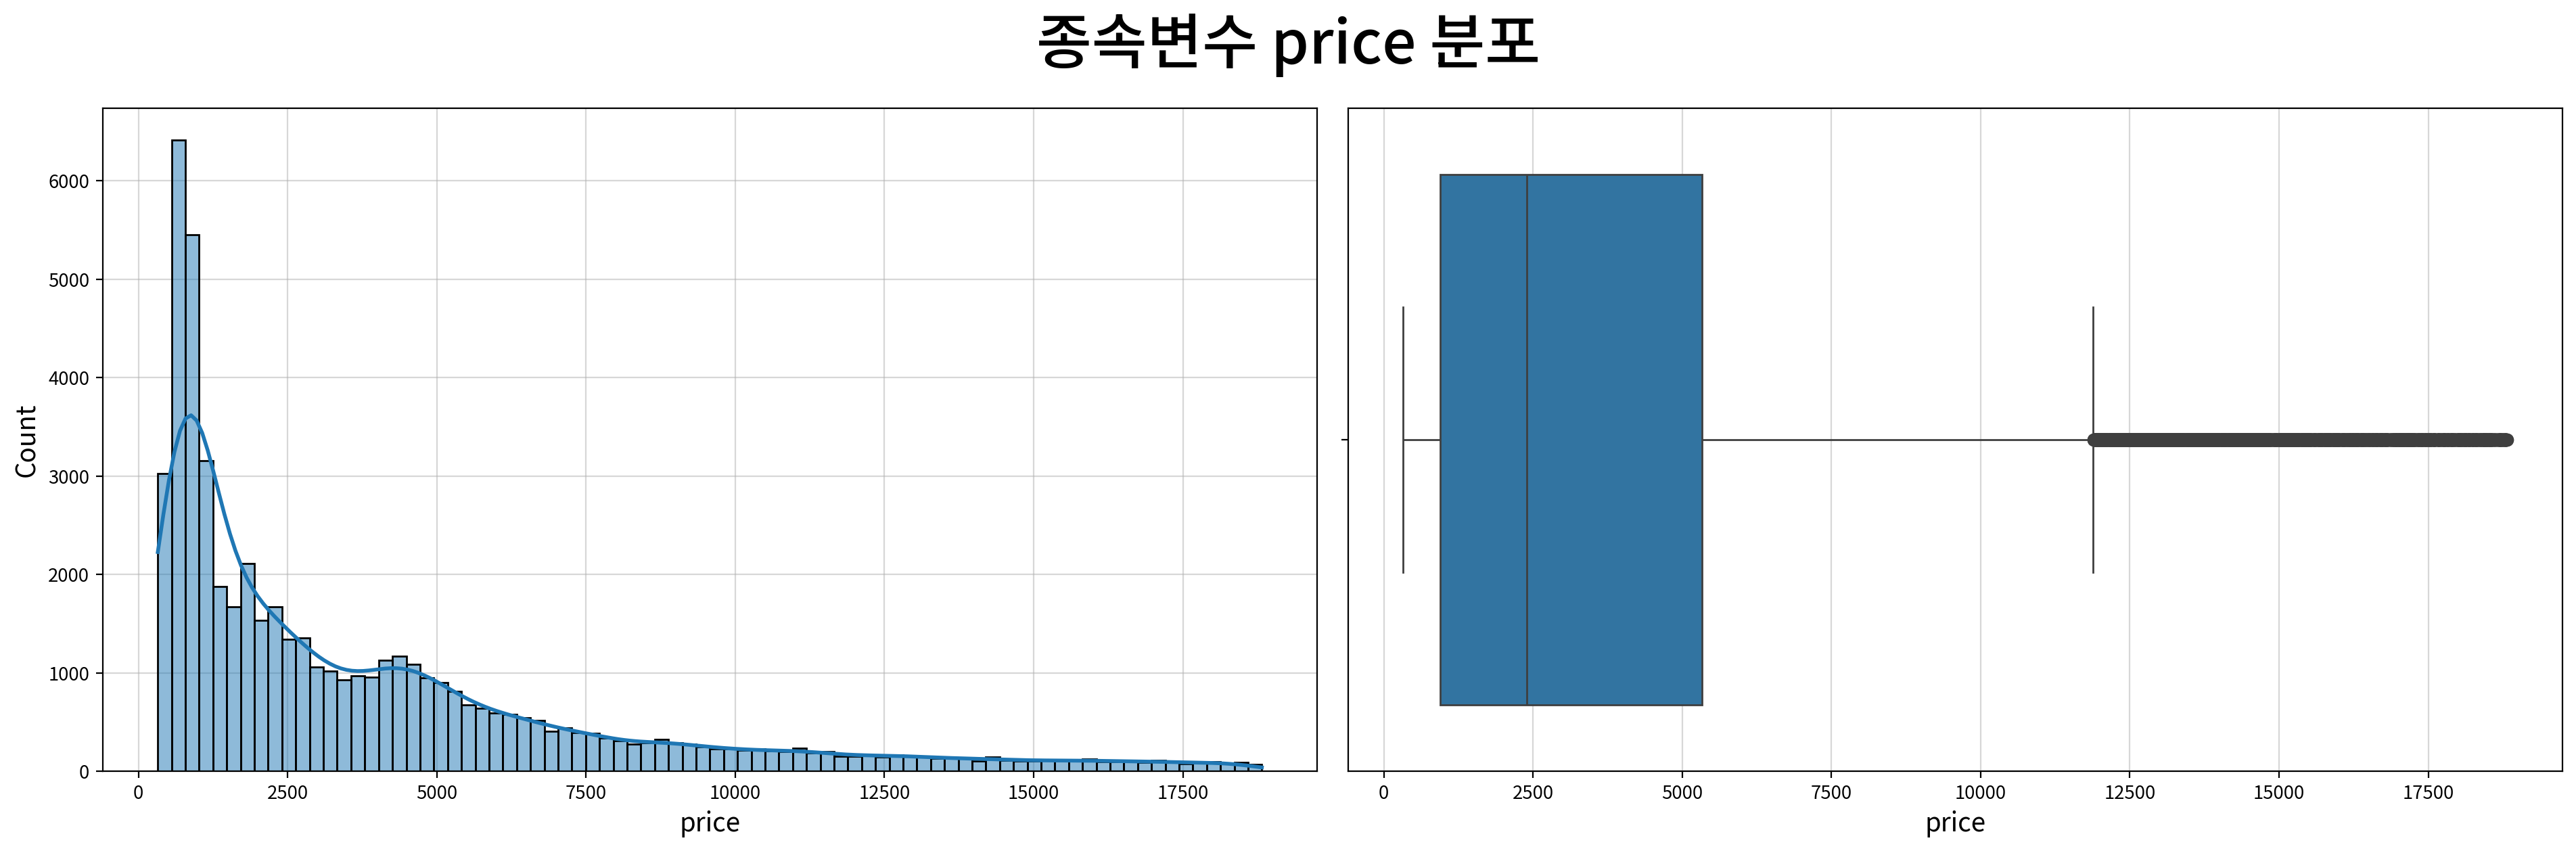

,price
count,53794.000
mean,3933.065
std,3988.114
min,326.000
25%,951.000
50%,2401.000
75%,5326.750
max,18823.000
rel_diff,0.638
rdiff_flag,large_diff


In [18]:
# 1행 2열 서브플롯 구성
# -> 그래프 크기는 서브플롯 중 하나의 크기(전체 크기는 가로 960 x 2가 됨)
fig, ax = my_plot.init(rows=1, cols=2, 
            title=f"종속변수 {target} 분포", width=960, height=640)
my_plot.histplot(data=df, x=target, kde=True, ax=ax[0])
my_plot.boxplot(data=df, x=target, ax=ax[1])
my_plot.show()

# 연속형 변수 기술통계량에서 종속변수에 대한 부분만 추출
num_desc[num_desc.index == target].T

##### 💡 결과 해석


| 점검 항목 | `price` 관찰값 |
|---|---|
| 분포 모양 | 왜도: **+1.618 (우편향)**, 첨도: 2.178 (뾰족함) |
| 봉우리 수 | 단봉 |
| 이상치 | 상단 3,523건(**6.5%**) / 하단 0건 |
| 이산점(군집) | 낮은 가격대 분포가 높음 (일부 고가 다이아몬드 관찰됨, 상단 절단 없음) |

- **로그 변환 후 모델 투입**

#### 2. 연속형 독립변수에 대한 단변량 분석

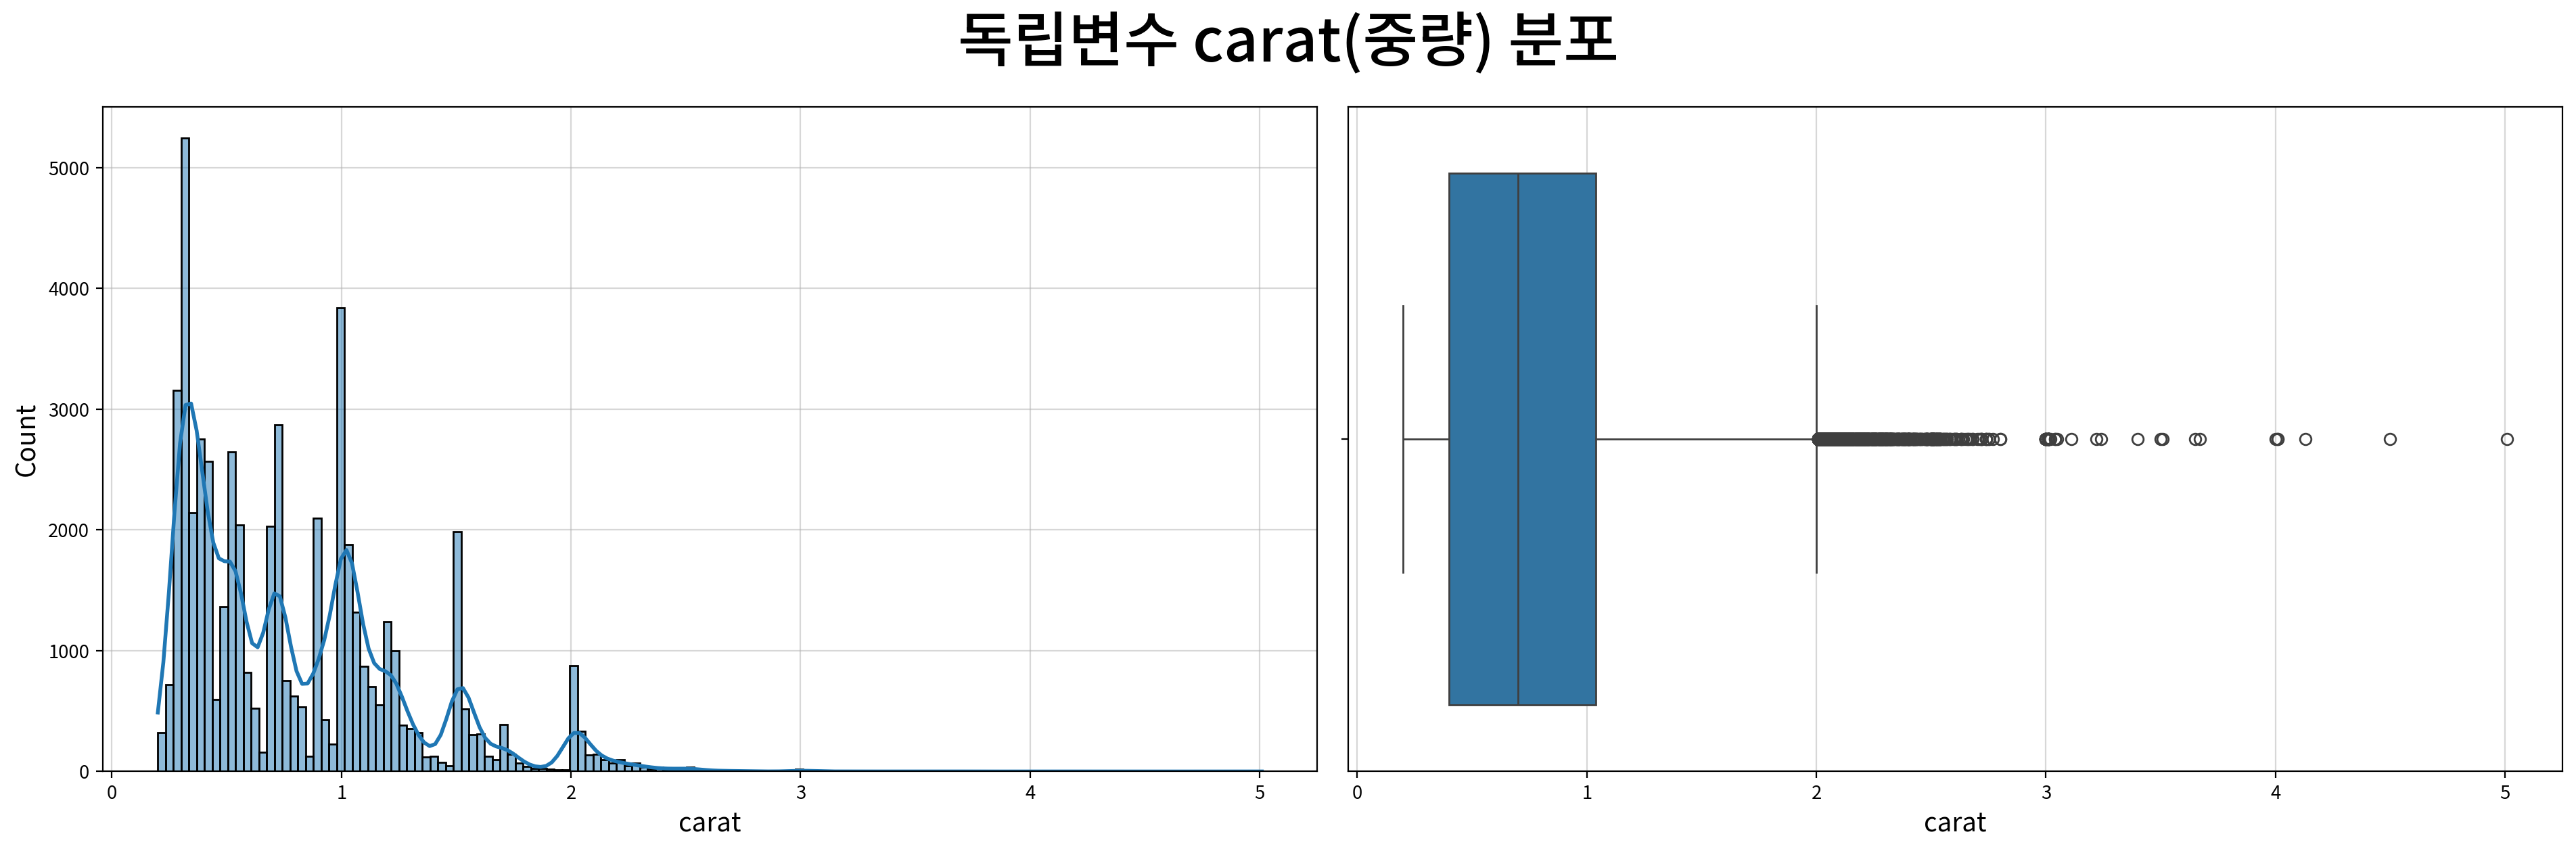

,carat
count,53794.000
mean,0.798
std,0.473
min,0.200
25%,0.400
50%,0.700
75%,1.040
max,5.010
rel_diff,0.140
rdiff_flag,diff


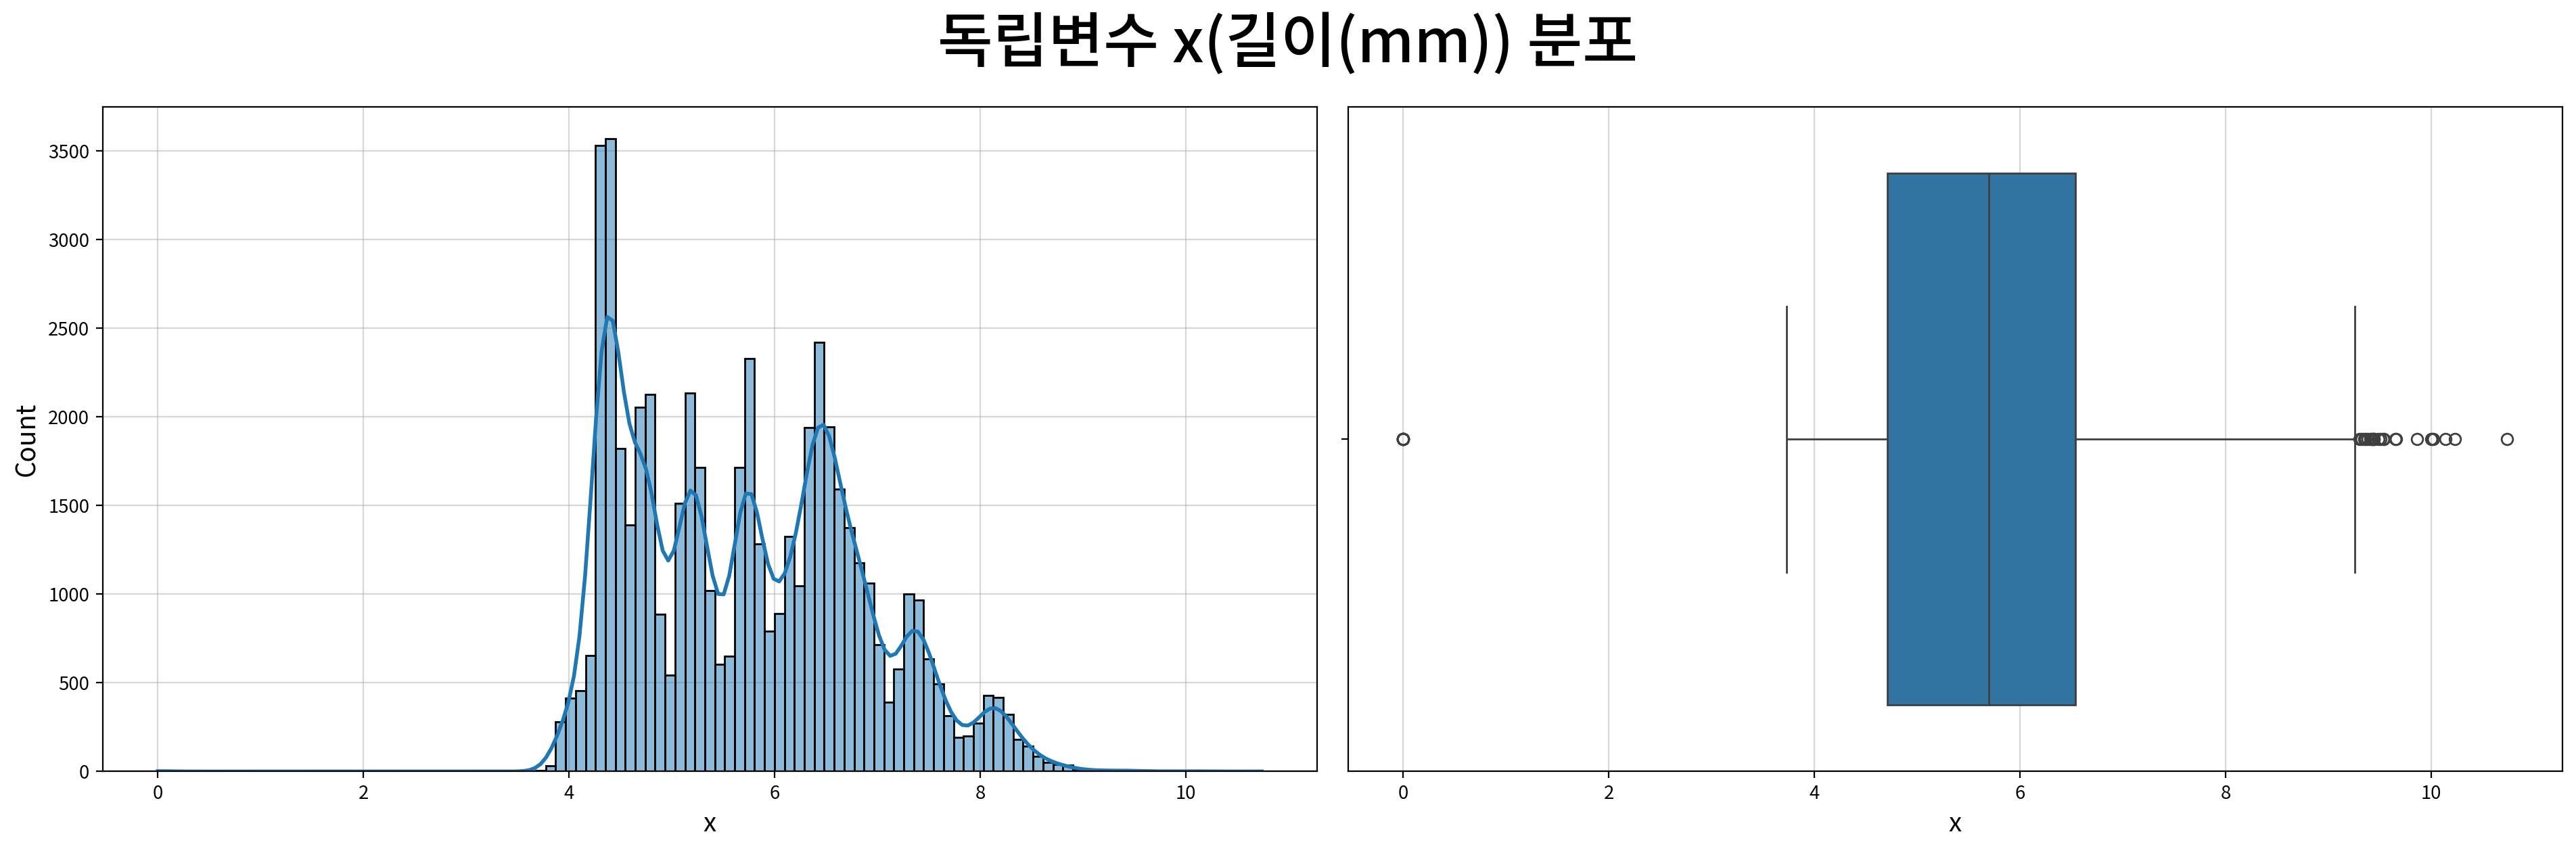

,x
count,53794.000
mean,5.731
std,1.121
min,0.000
25%,4.710
50%,5.700
75%,6.540
max,10.740
rel_diff,0.005
rdiff_flag,similar


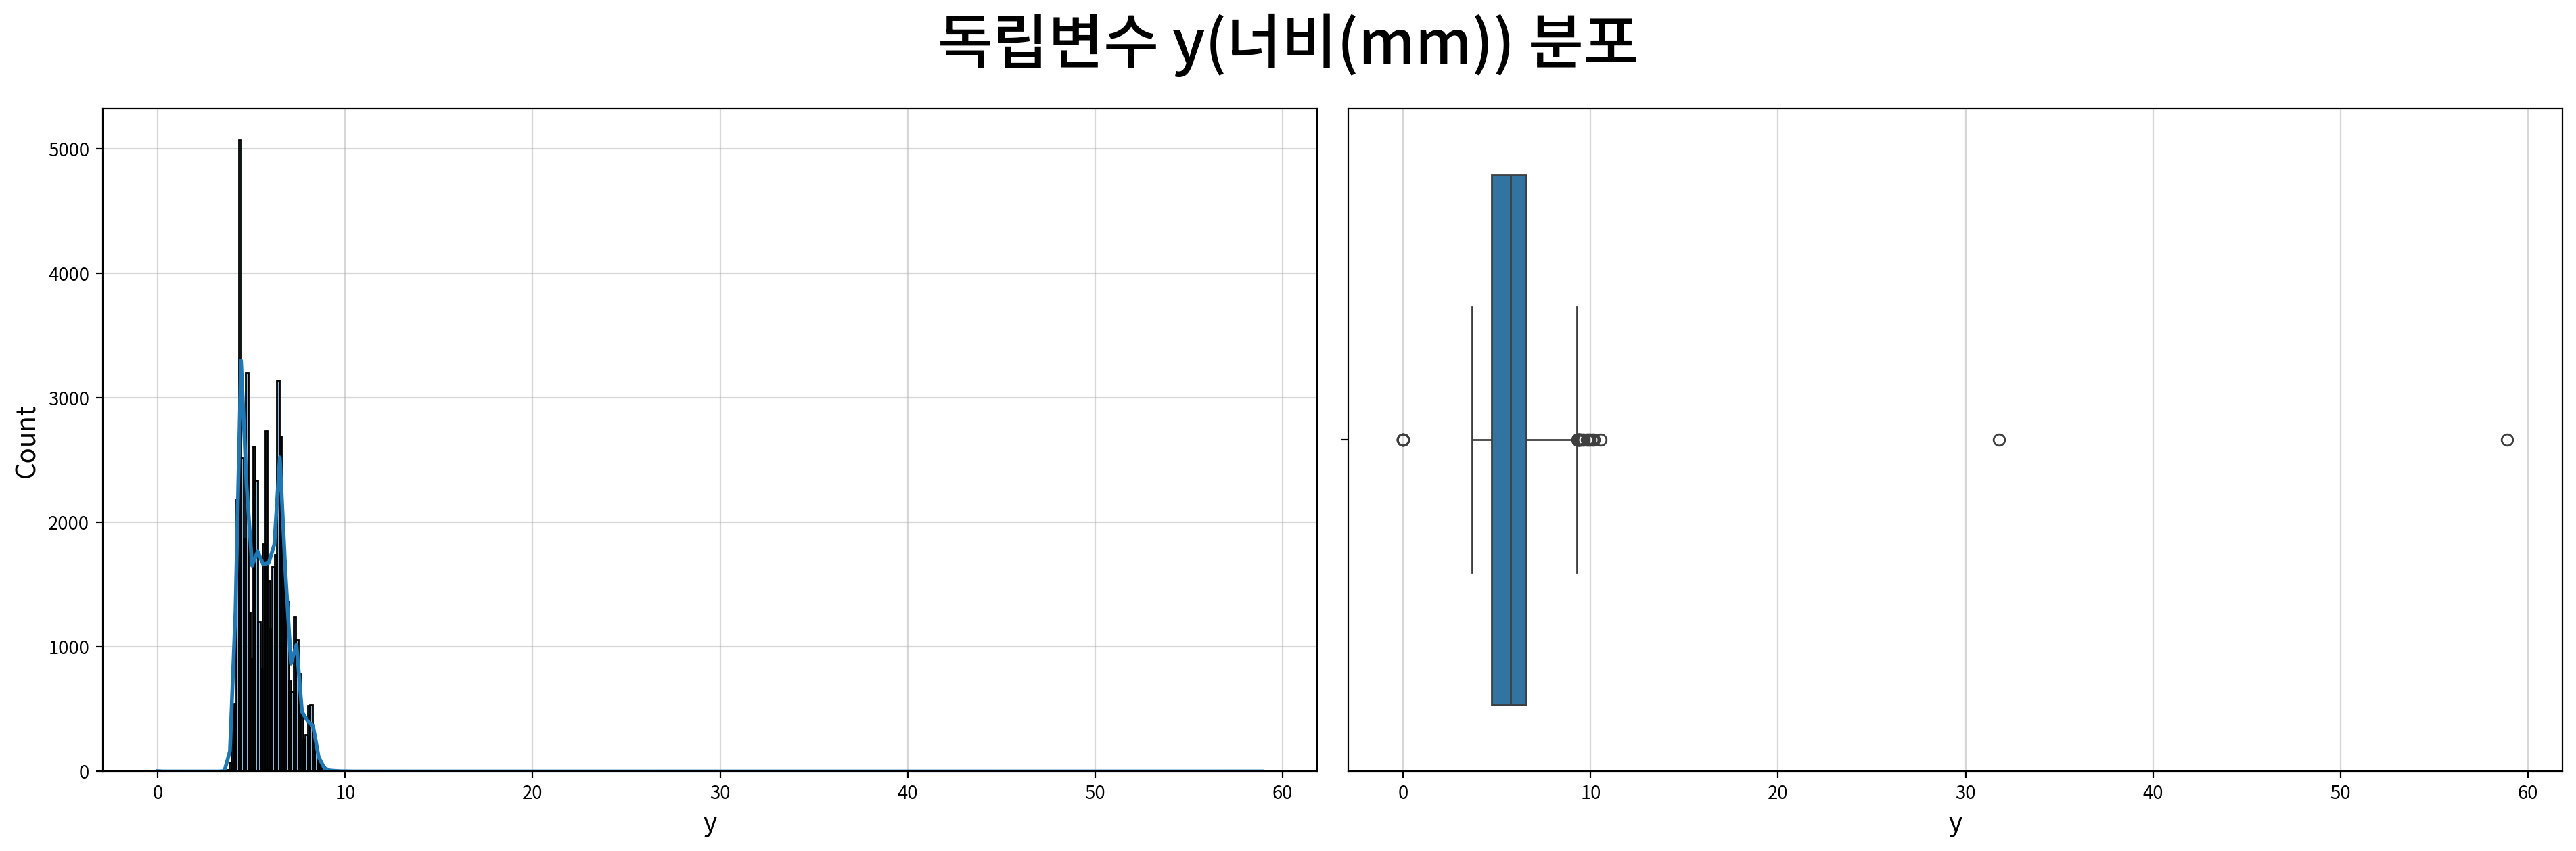

,y
count,53794.000
mean,5.735
std,1.141
min,0.000
25%,4.720
50%,5.710
75%,6.540
max,58.900
rel_diff,0.004
rdiff_flag,similar


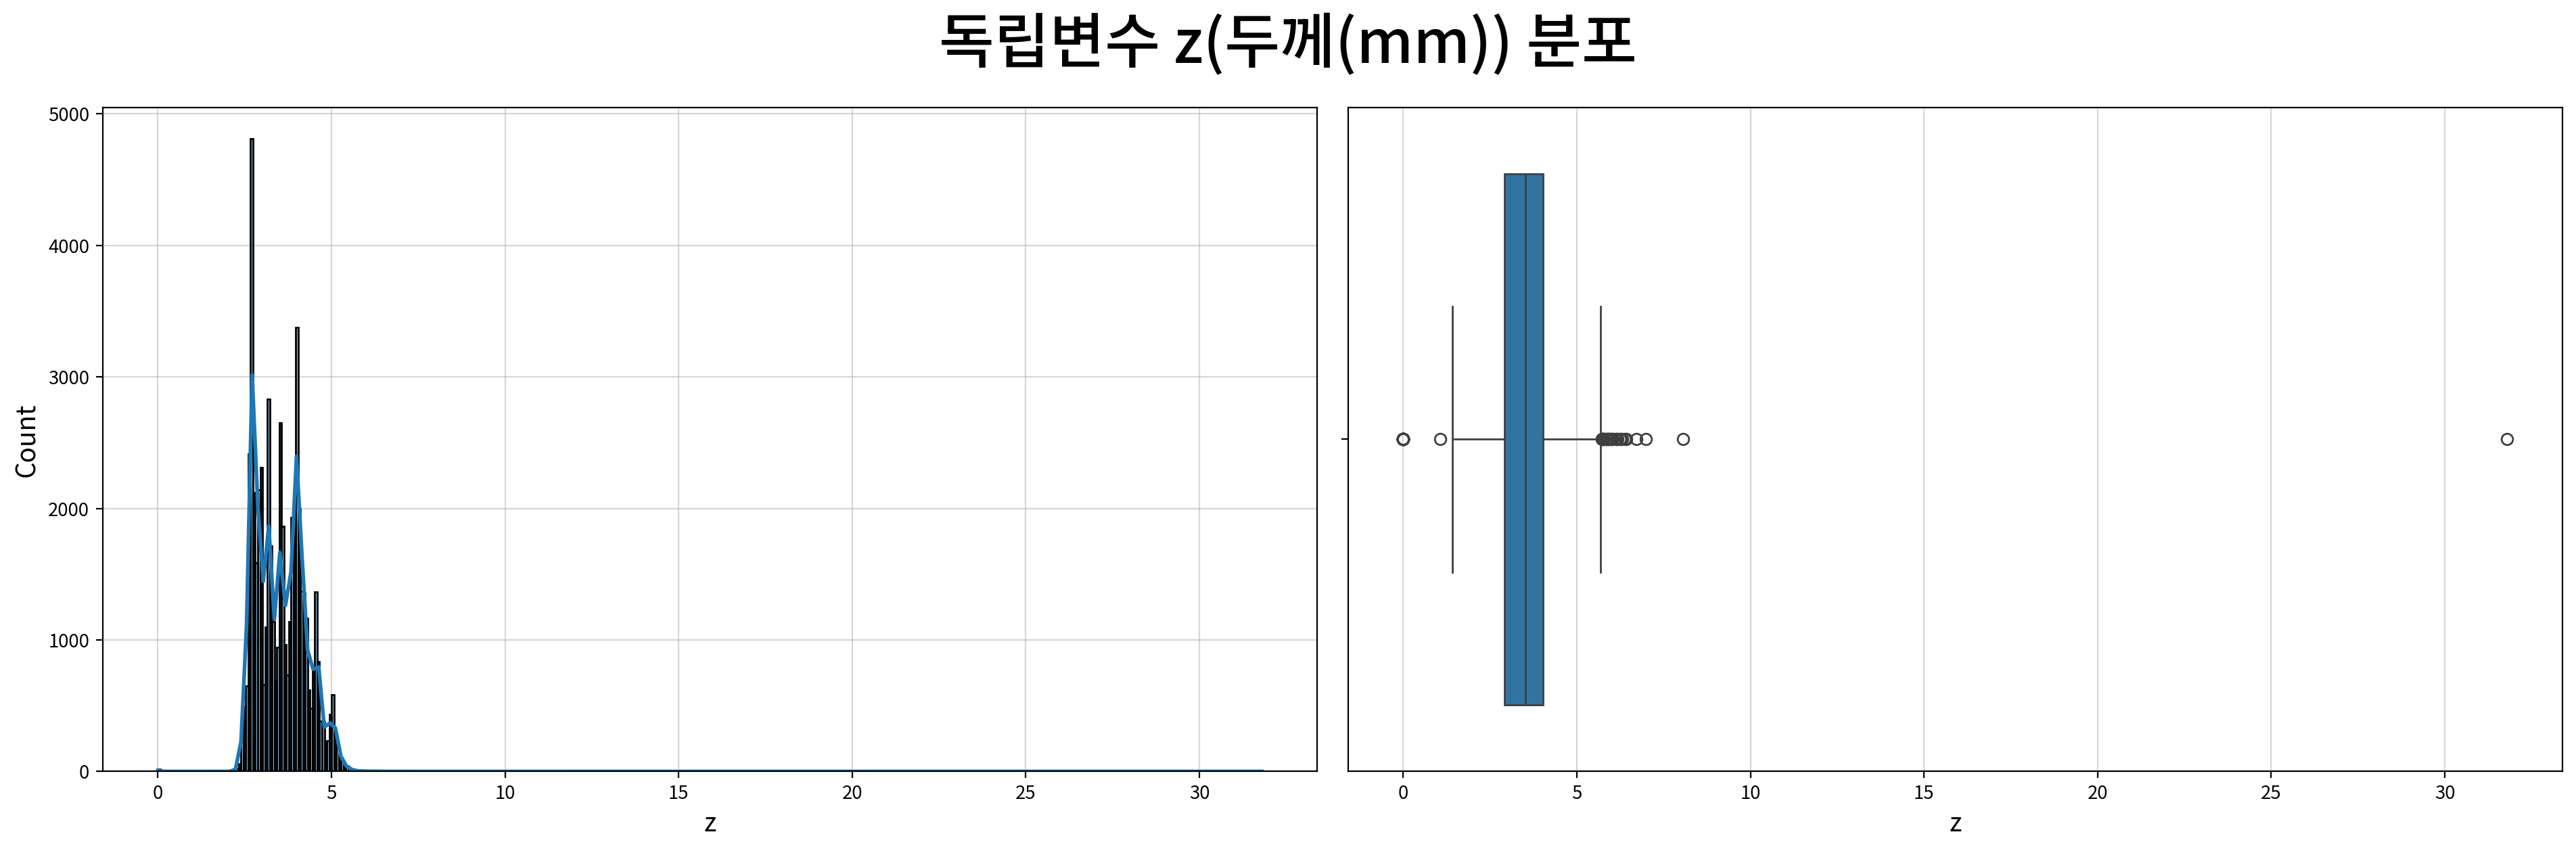

,z
count,53794.000
mean,3.539
std,0.705
min,0.000
25%,2.910
50%,3.530
75%,4.030
max,31.800
rel_diff,0.002
rdiff_flag,similar


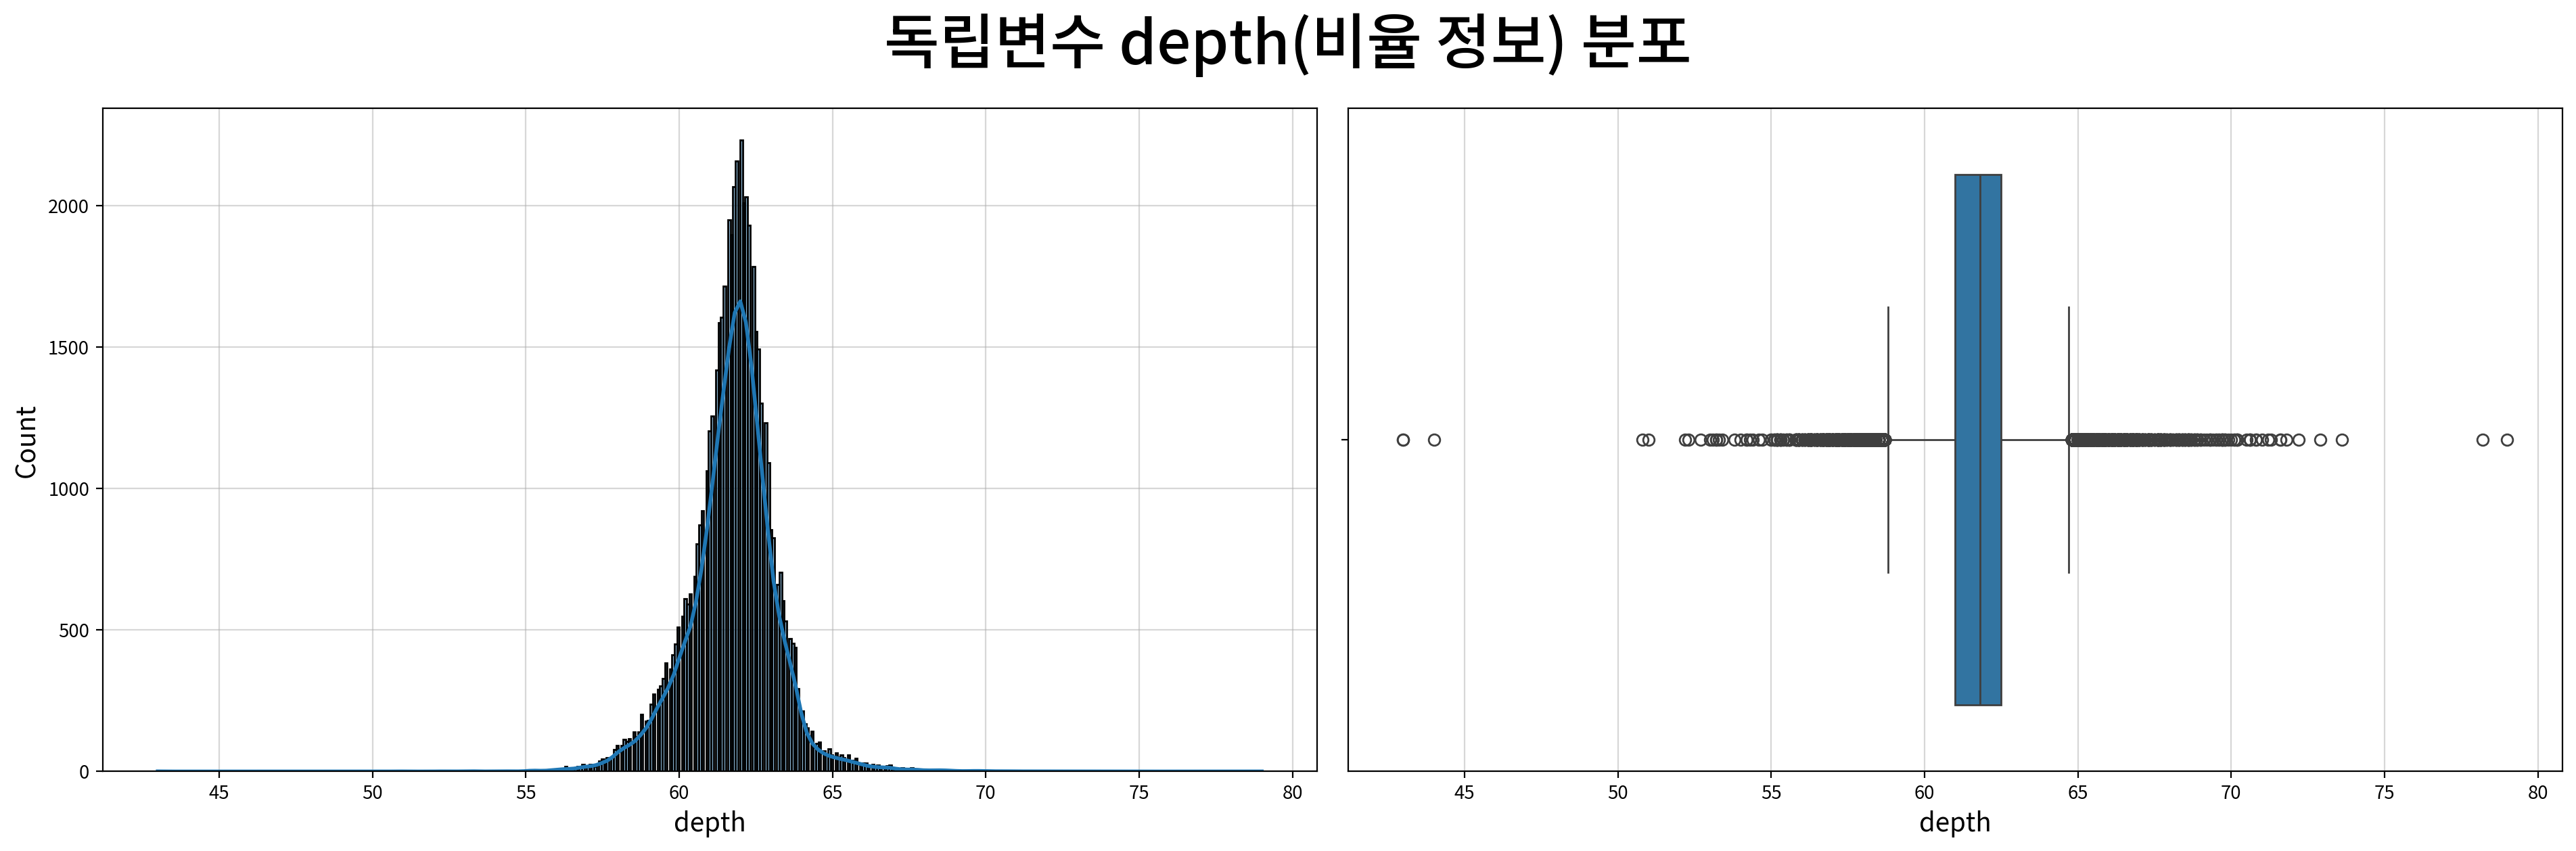

,depth
count,53794.000
mean,61.748
std,1.430
min,43.000
25%,61.000
50%,61.800
75%,62.500
max,79.000
rel_diff,0.001
rdiff_flag,similar


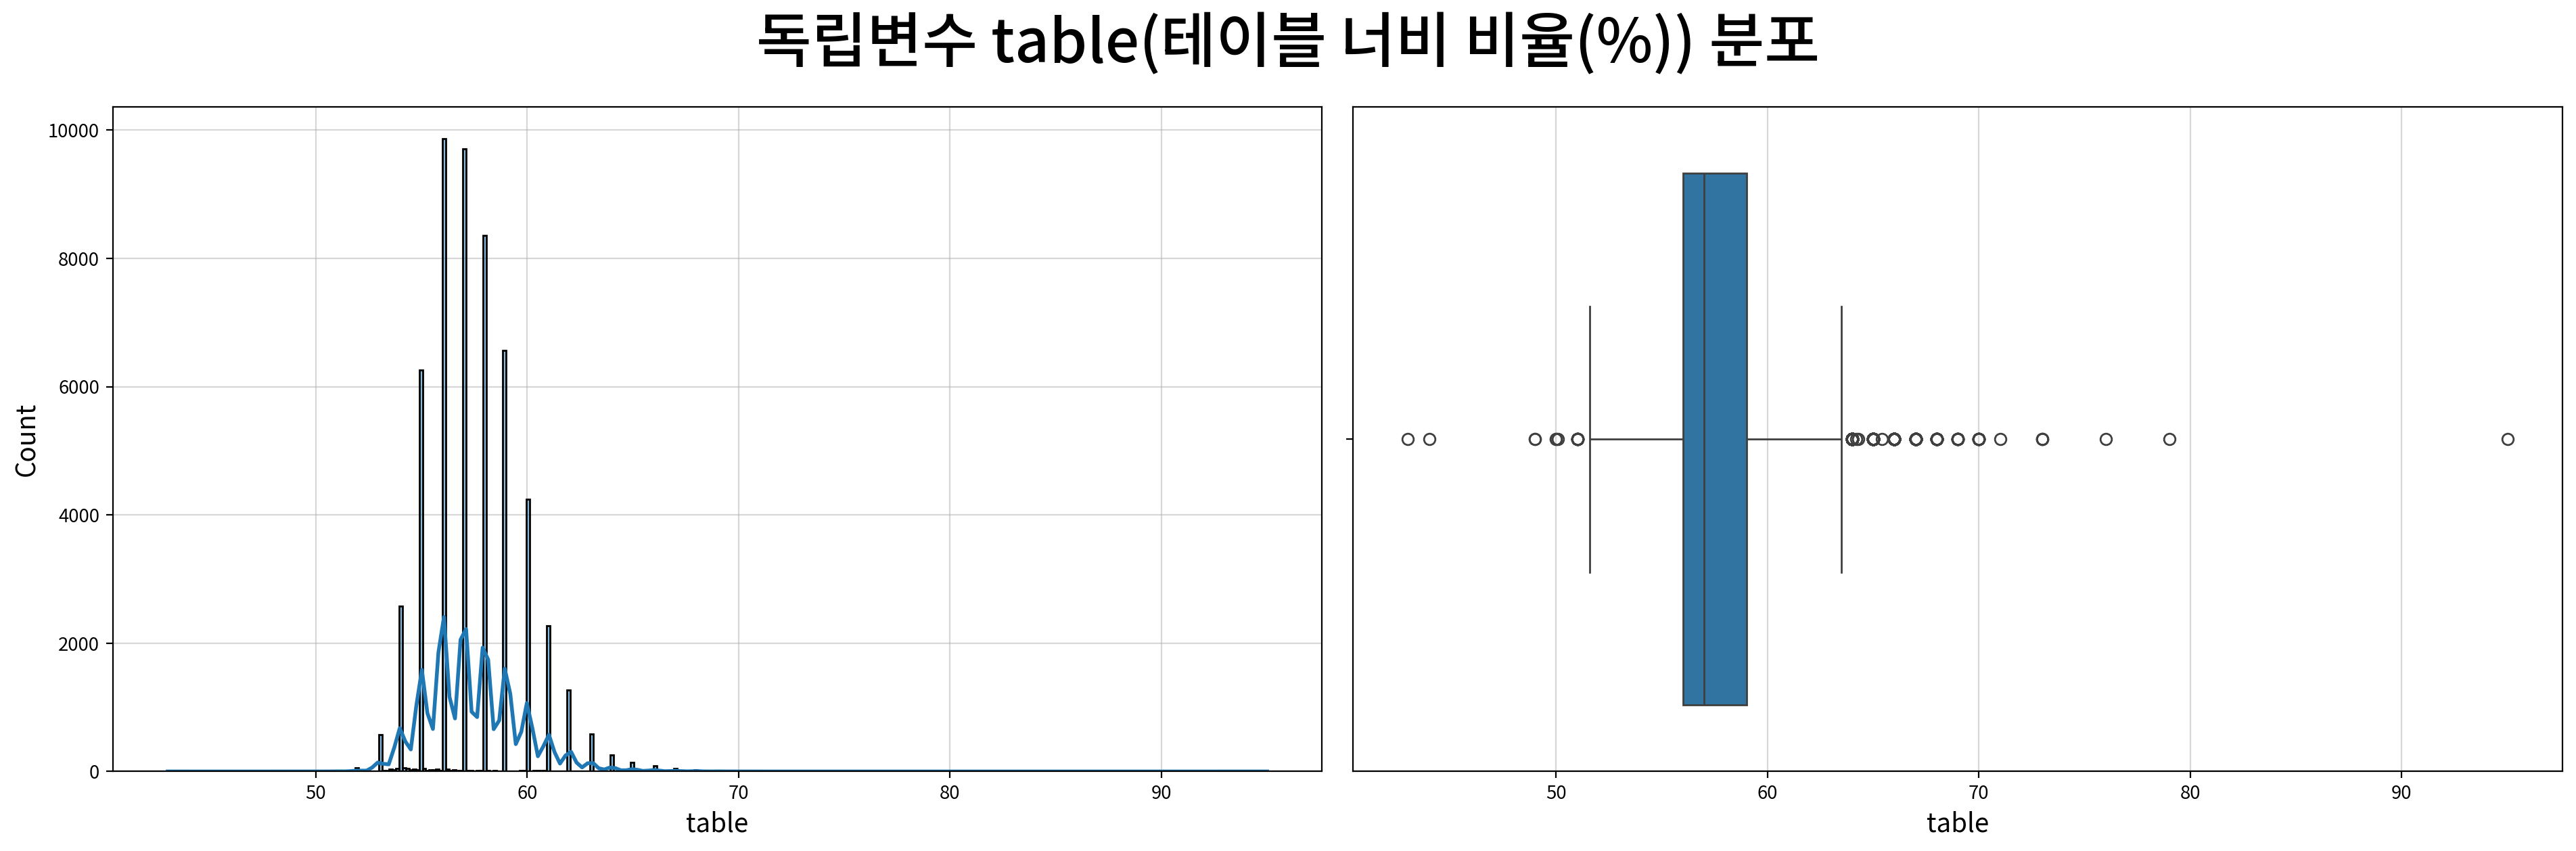

,table
count,53794.000
mean,57.458
std,2.234
min,43.000
25%,56.000
50%,57.000
75%,59.000
max,95.000
rel_diff,0.008
rdiff_flag,similar


In [19]:
for f in continuous_cols:
    fig, ax = my_plot.init(rows=1, cols=2, width=960, height=640,
                title=f"독립변수 {f}({column_means[f]}) 분포")
    my_plot.histplot(data=df, x=f, kde=True, ax=ax[0])
    my_plot.boxplot(data=df, x=f, ax=ax[1])
    my_plot.show()

    display(num_desc[num_desc.index == f].T)

##### 💡 결과 해석

| 변수 | 왜도 | 현재 기술통계의 로그 판정 | 관찰과 후속 판단 |
|---|---:|---|---|
| carat | 1.114 | log | 가격과 강한 단조 관계. 크기 축의 대표 후보 |
| x | 0.380 | none | 최솟값 0mm. 물리 치수의 품질 확인 필요 |
| y | 2.446 | log1p | 최솟값 0mm, 최댓값 58.9mm. 극단값 점검 필요 |
| z | 1.529 | log1p | 최솟값 0mm, 최댓값 31.8mm. 극단값 점검 필요 |
| depth | −0.114 | none | 가격과의 관계는 다음 상관분석에서 확인 |
| table | 0.792 | log | 상단 너비 비율(%). mm 단위의 물리 치수와 구분 |

- 로그 변환 종류는 저장된 기술통계와 실제 파이프라인의 자동 판정을 따른다.
- 0mm와 극단 치수는 검토 대상이다. 이 노트북에는 별도 오류값 정제 셀을 추가하지 않았으므로 정제 완료로 보고하지 않는다.
- 후속 IQR 대체는 연속형 독립변수의 경계값 대체이며, 개별 오류값을 원자료와 대조해 수정한 것과는 다르다.


#### 3. 명목형 독립변수에 대한 단변량 분석

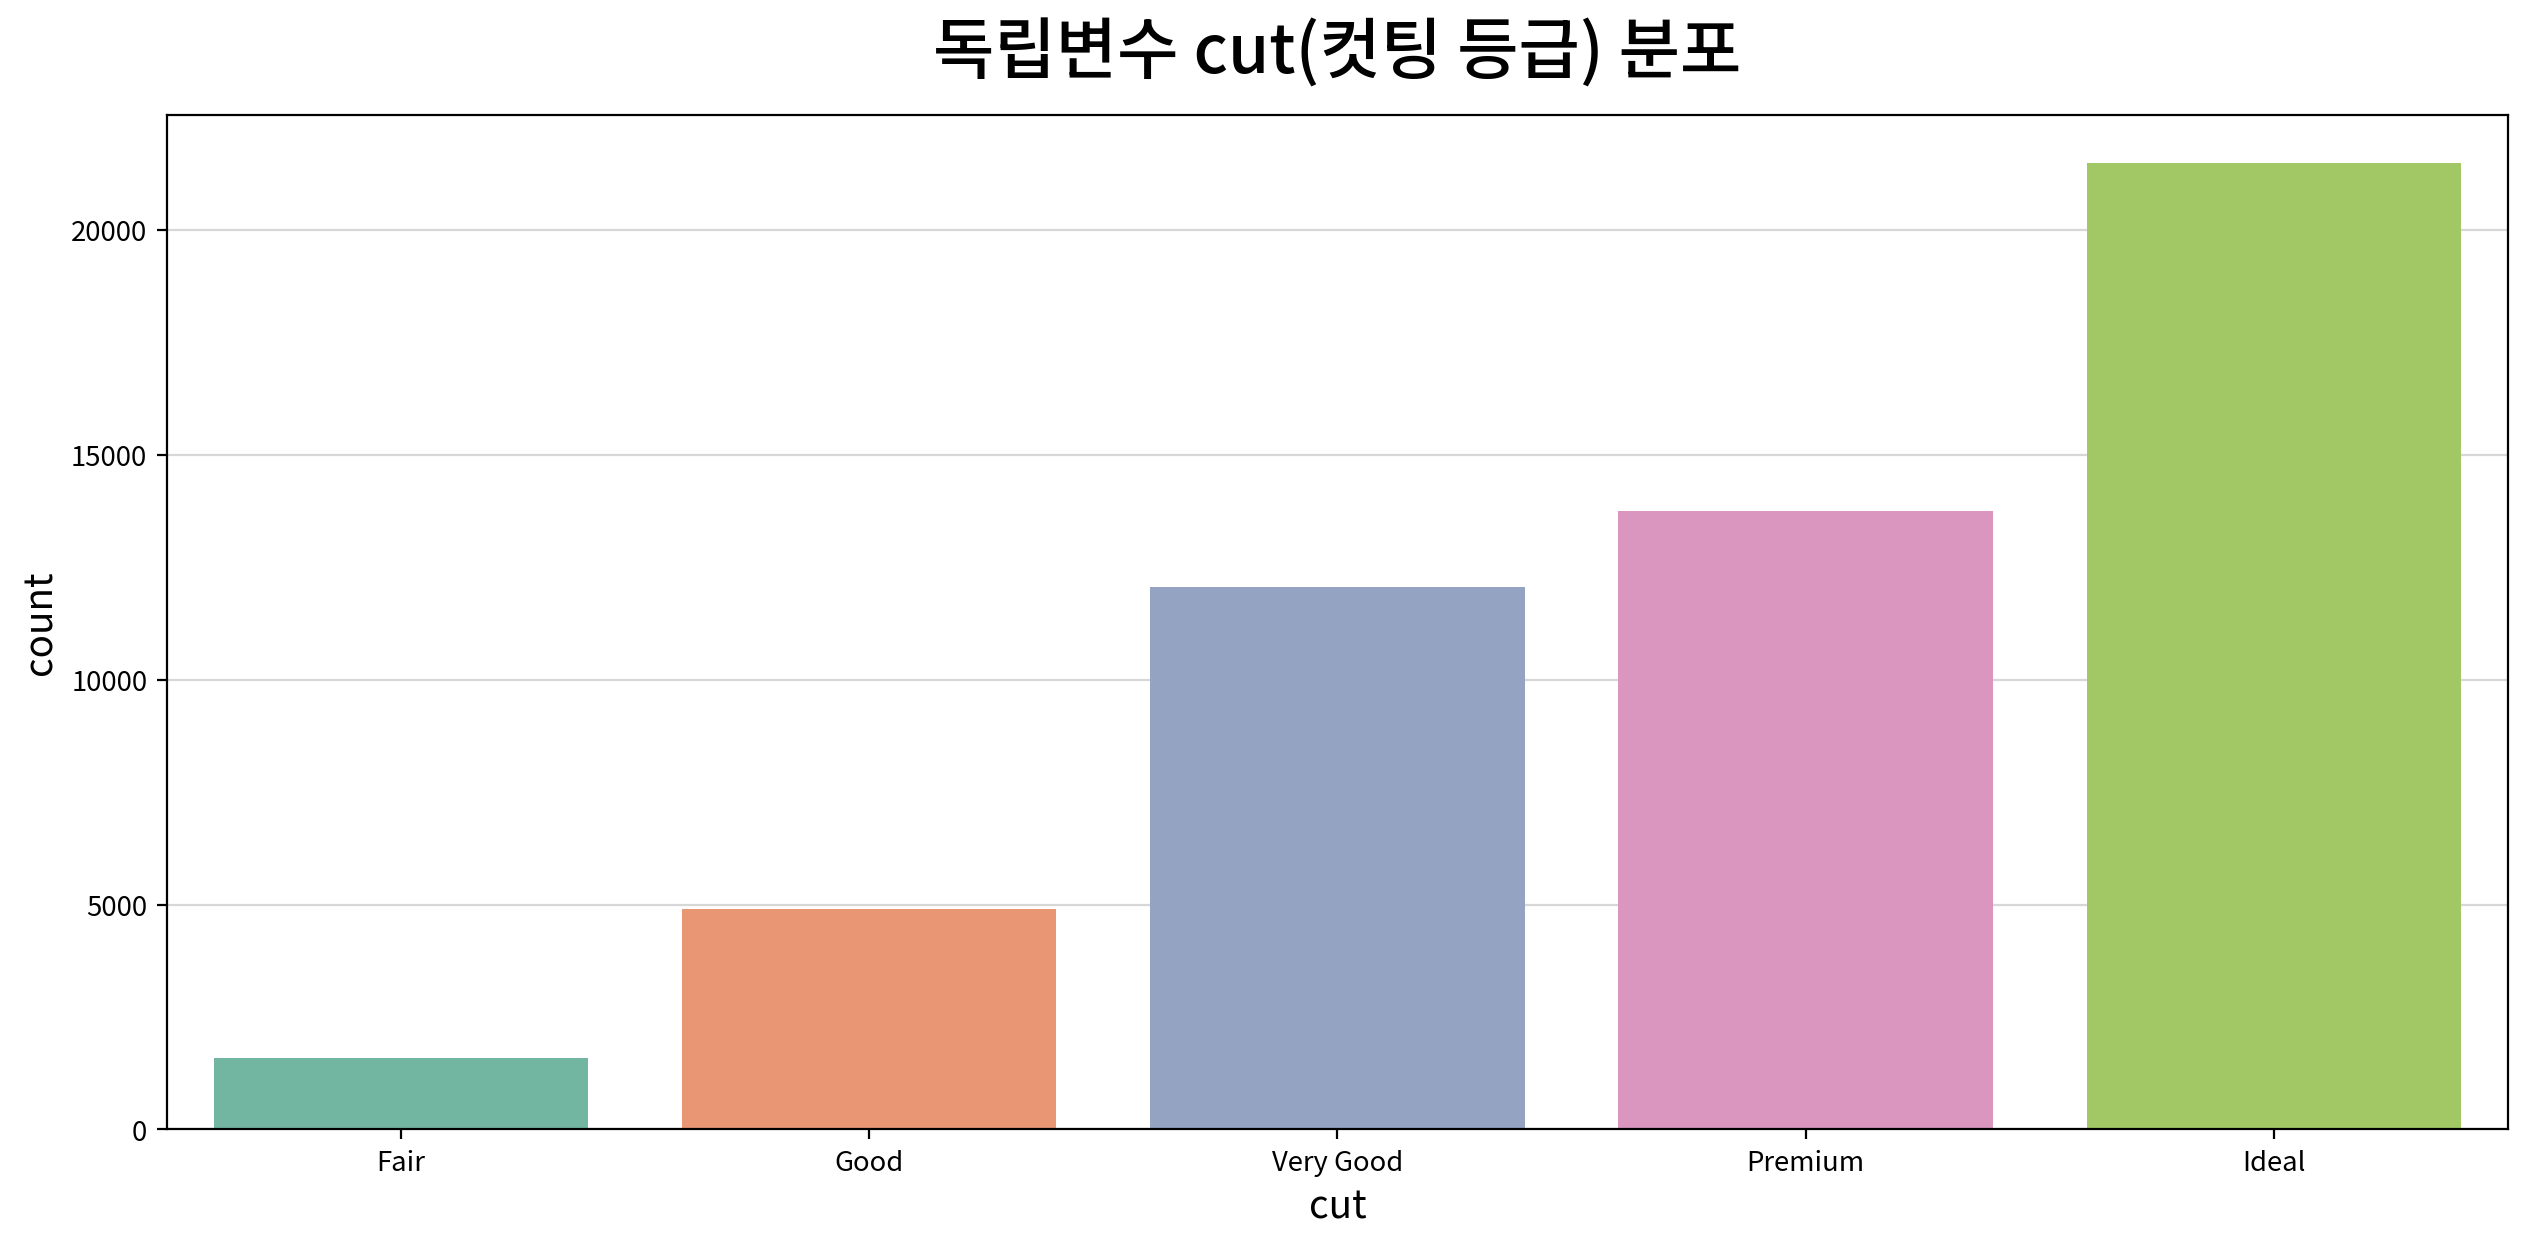

,count,unique,top,freq
cut,53794,5,Ideal,21488


,빈도,비율
cut,,
Ideal,21488,0.399
Premium,13748,0.256
Very Good,12069,0.224
Good,4891,0.091
Fair,1598,0.030


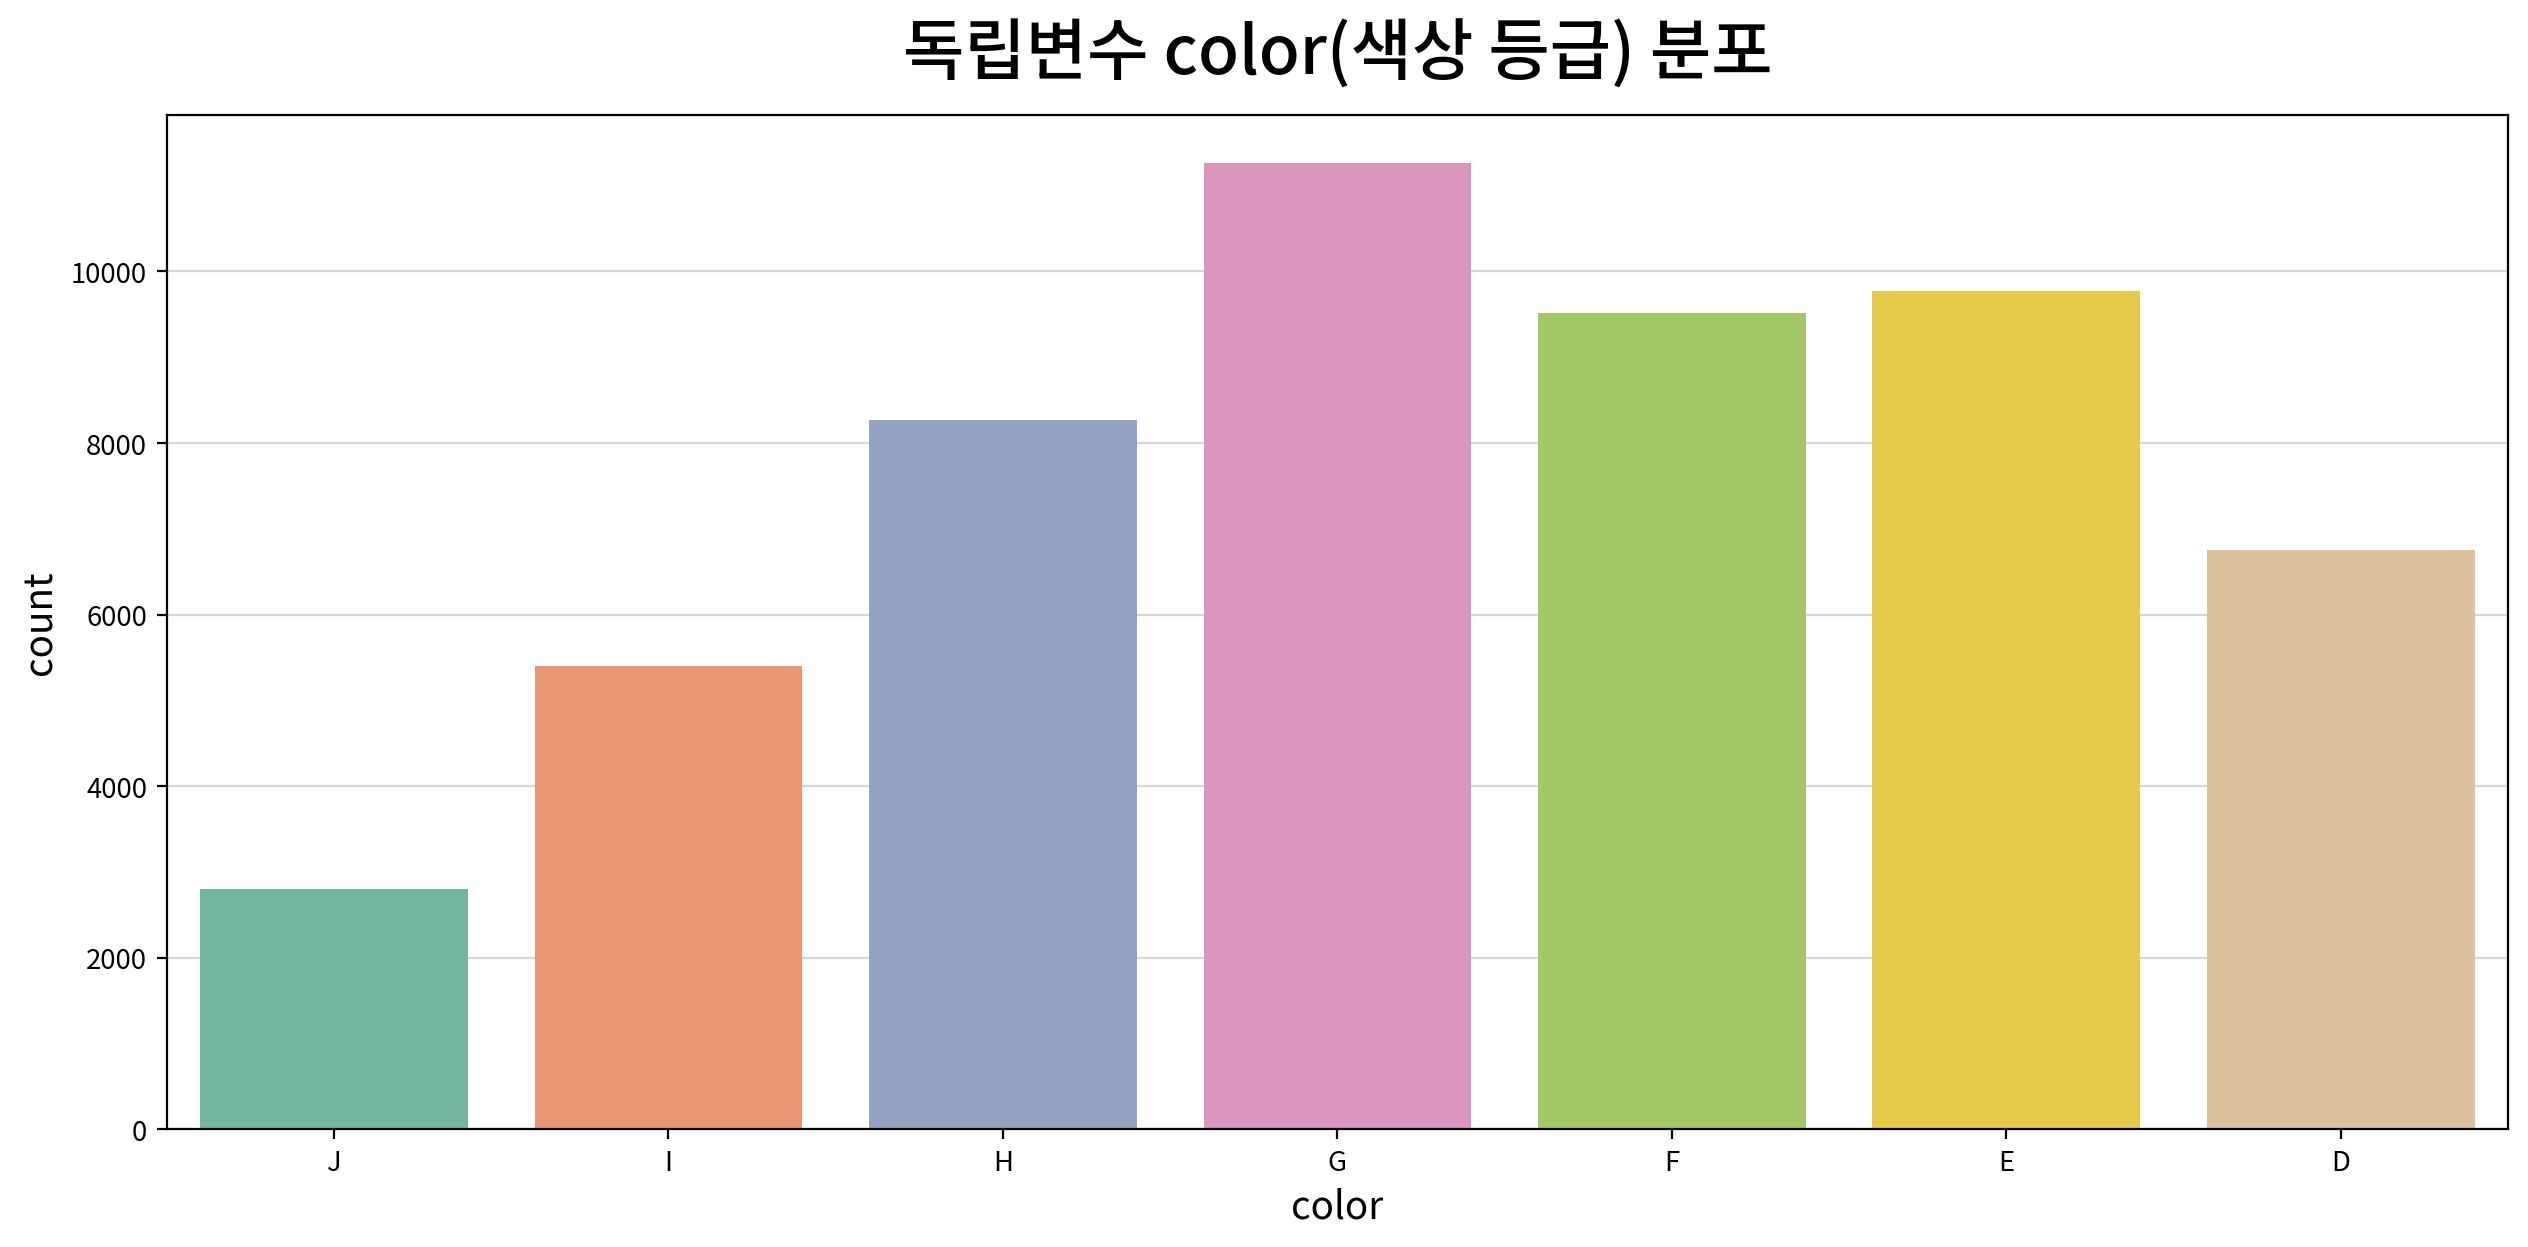

,count,unique,top,freq
color,53794,7,G,11262


,빈도,비율
color,,
G,11262,0.209
E,9776,0.182
F,9520,0.177
H,8272,0.154
D,6755,0.126
I,5407,0.101
J,2802,0.052


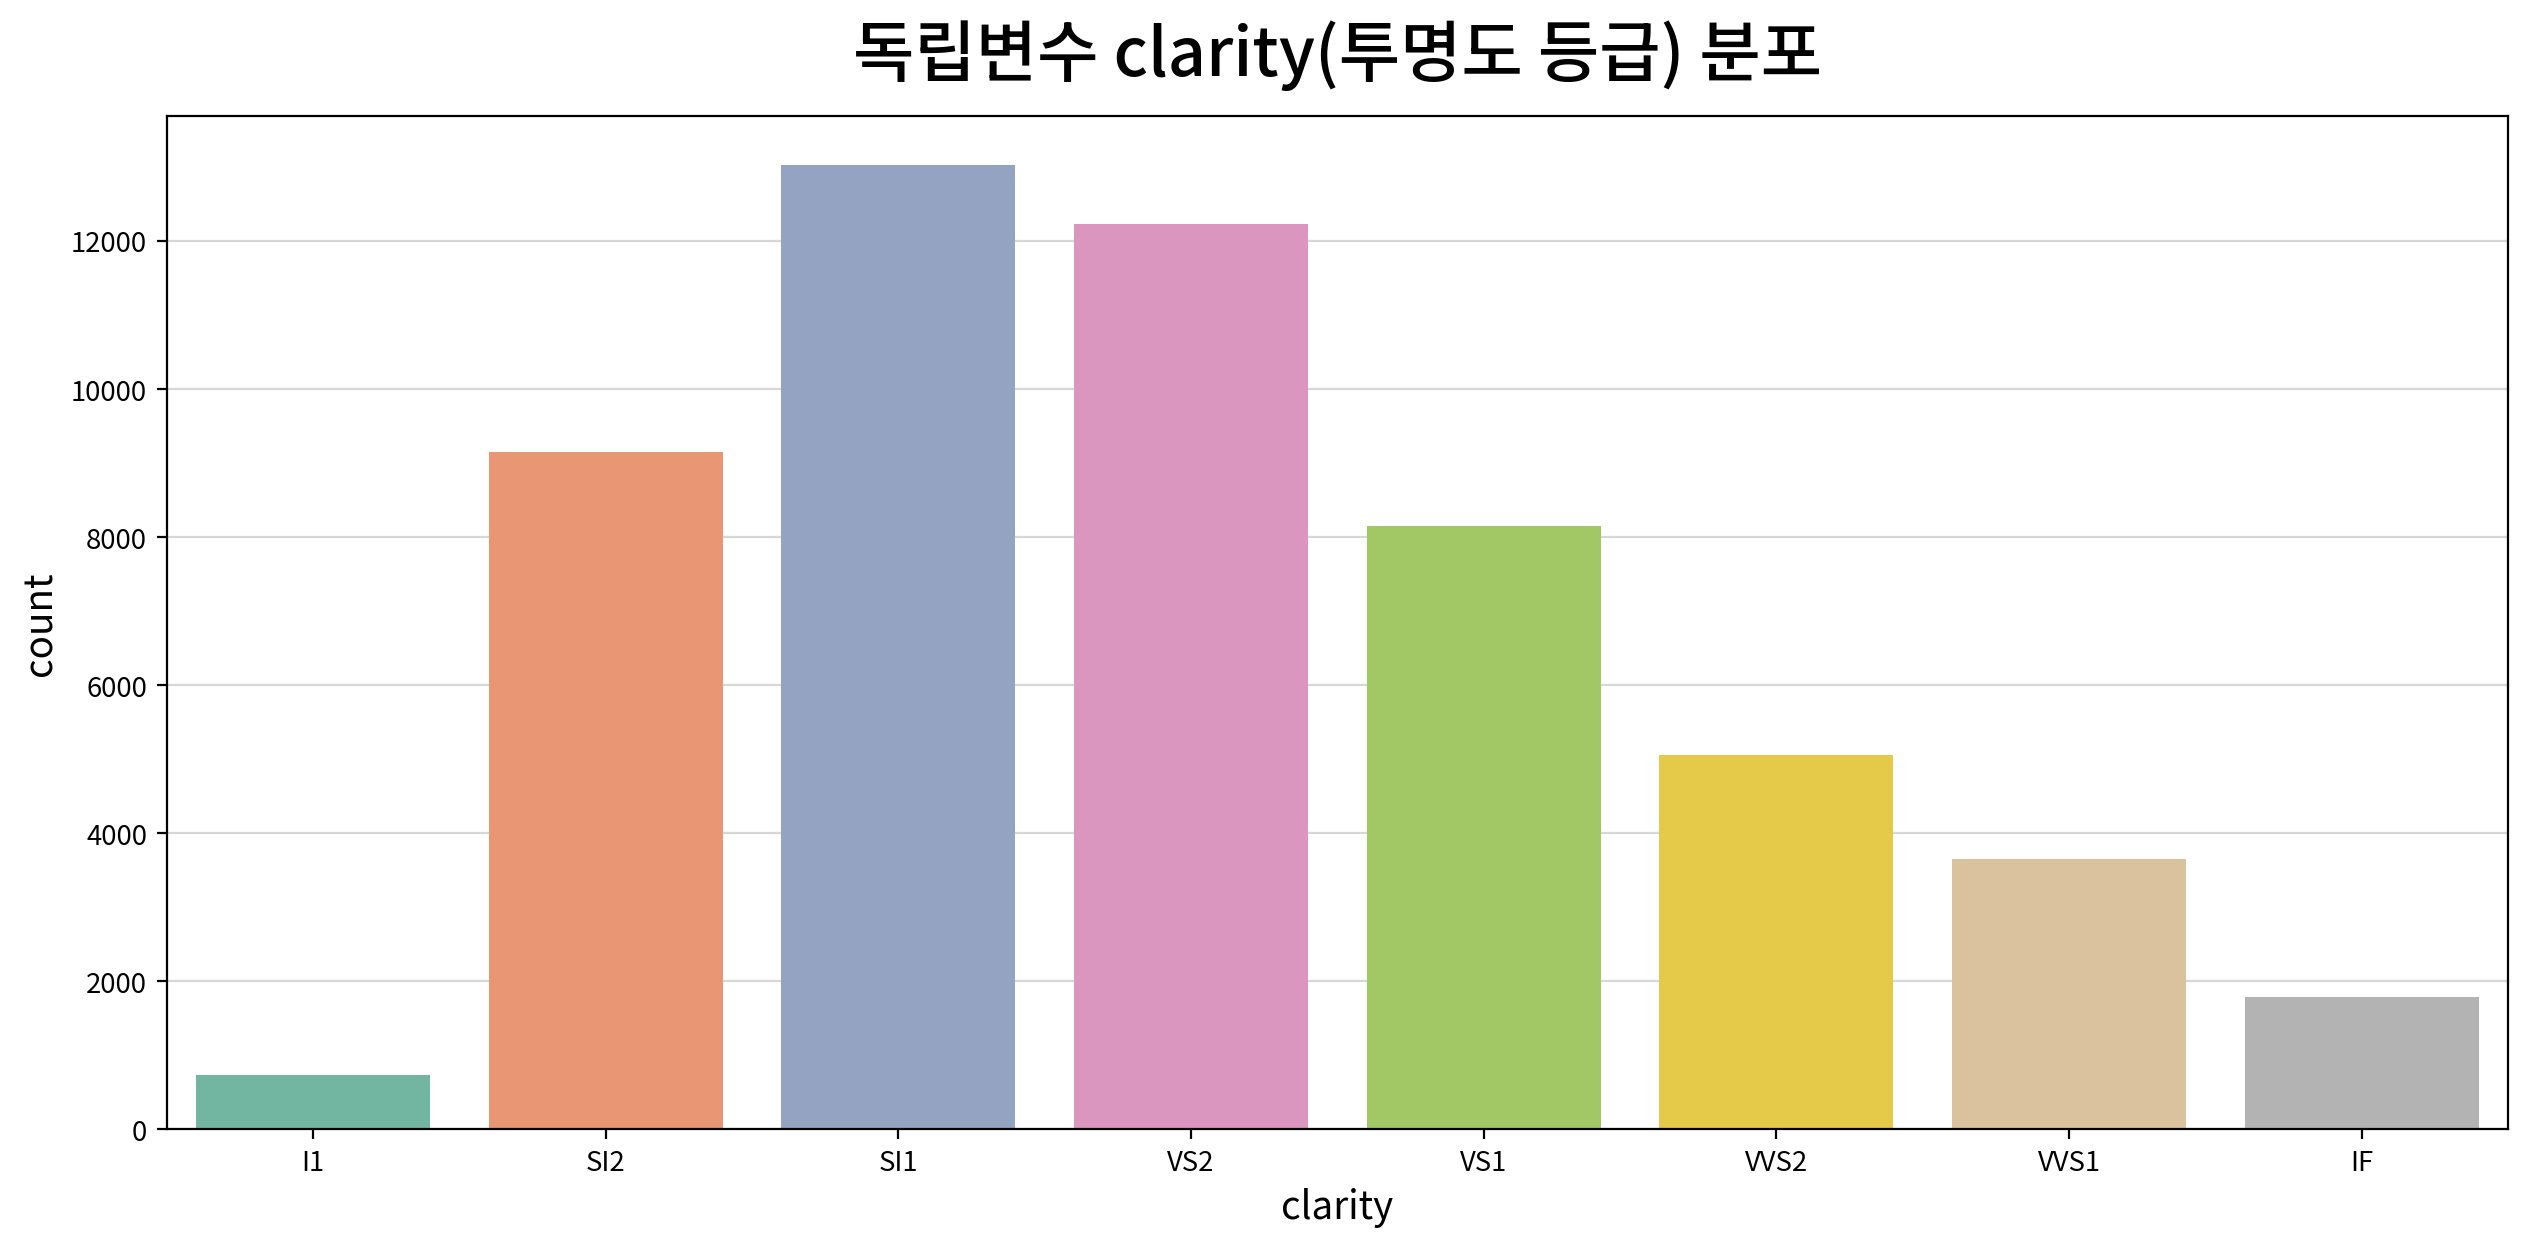

,count,unique,top,freq
clarity,53794,8,SI1,13032


,빈도,비율
clarity,,
SI1,13032,0.242
VS2,12229,0.227
SI2,9150,0.170
VS1,8156,0.152
VVS2,5056,0.094
VVS1,3647,0.068
IF,1784,0.033
I1,740,0.014


In [20]:
for n in nominal_cols:
    # 명목형 분포는 카운트 플롯으로 처리한다.
    my_plot.countplot(data=df, x=n, hue=n, palette="Set2", title=f"독립변수 {n}({column_means[n]}) 분포")

    # 명목형 기술통계량
    display(cat_desc[[n]].T)

    # 추가적으로 빈도표 생성
    freq = df[n].value_counts().rename("빈도").to_frame()
    # value_counts(normalize=True)
    # --> 전체 고유값의 개수(빈도수) 대신 전체 데이터의 비율을 계산
    freq["비율"] = df[n].value_counts(normalize=True)
    display(freq)

##### 💡 결과 해석


| 변수 | 범주 수 | 최빈 범주(비율) | 최소 범주(비율) | 균형 여부 | 판단·조치 |
|---|---|---|---|---|---|
| `cut` | 5 | Ideal 21,488 (39.9%) | Fair 1,598 (3.0%) | 다소 불균형 | 3집단 이상 → **ANOVA** 대상 |
| `color` | 7 | G 11,262 (20.9%) | J 2,802 (5.2%) | 비교적 균형 | 3집단 이상 → **ANOVA** 대상 |
| `clarity` | 8 | SI1 13,032 (24.2%) | I1 740 (1.4%) | 불균형(I1 소수) | 3집단 이상 → **ANOVA** 대상 |


### #03. 이변량 분석

#### 1. 상관분석 (x: 연속형 독립변수 → y: 연속형 종속변수)

#### ▶︎ carat(중량) → price

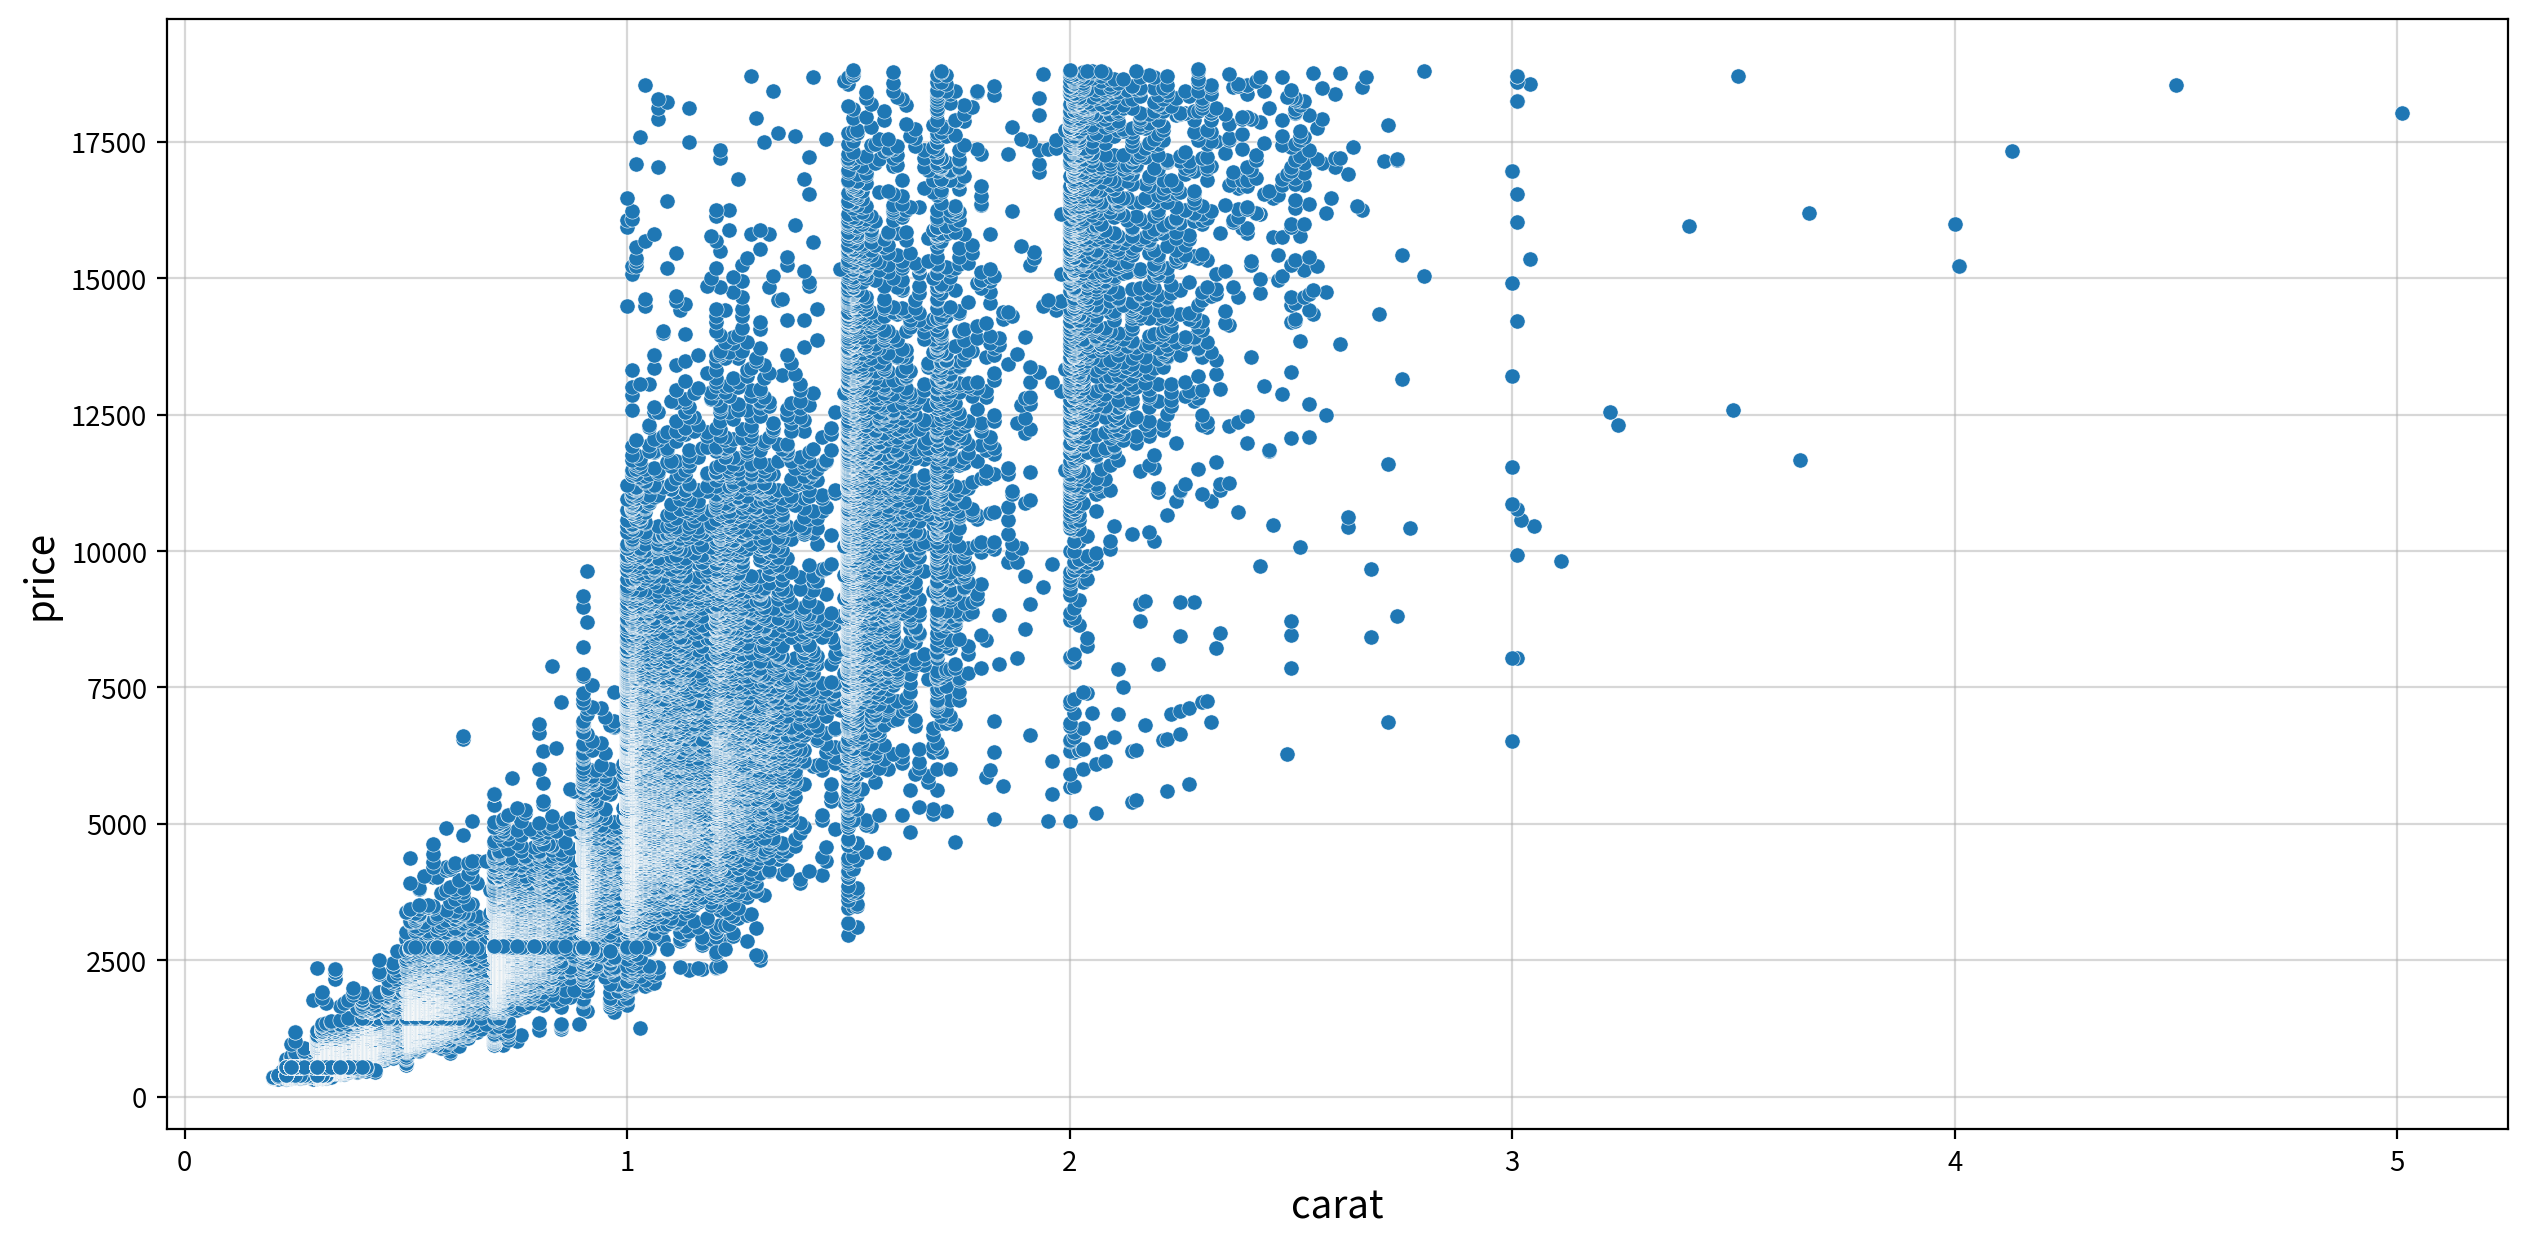

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
carat,price,Spearman,0.963,0.000,Strong,True,False,False,False,False,True


#### ▶︎ x(길이(mm)) → price

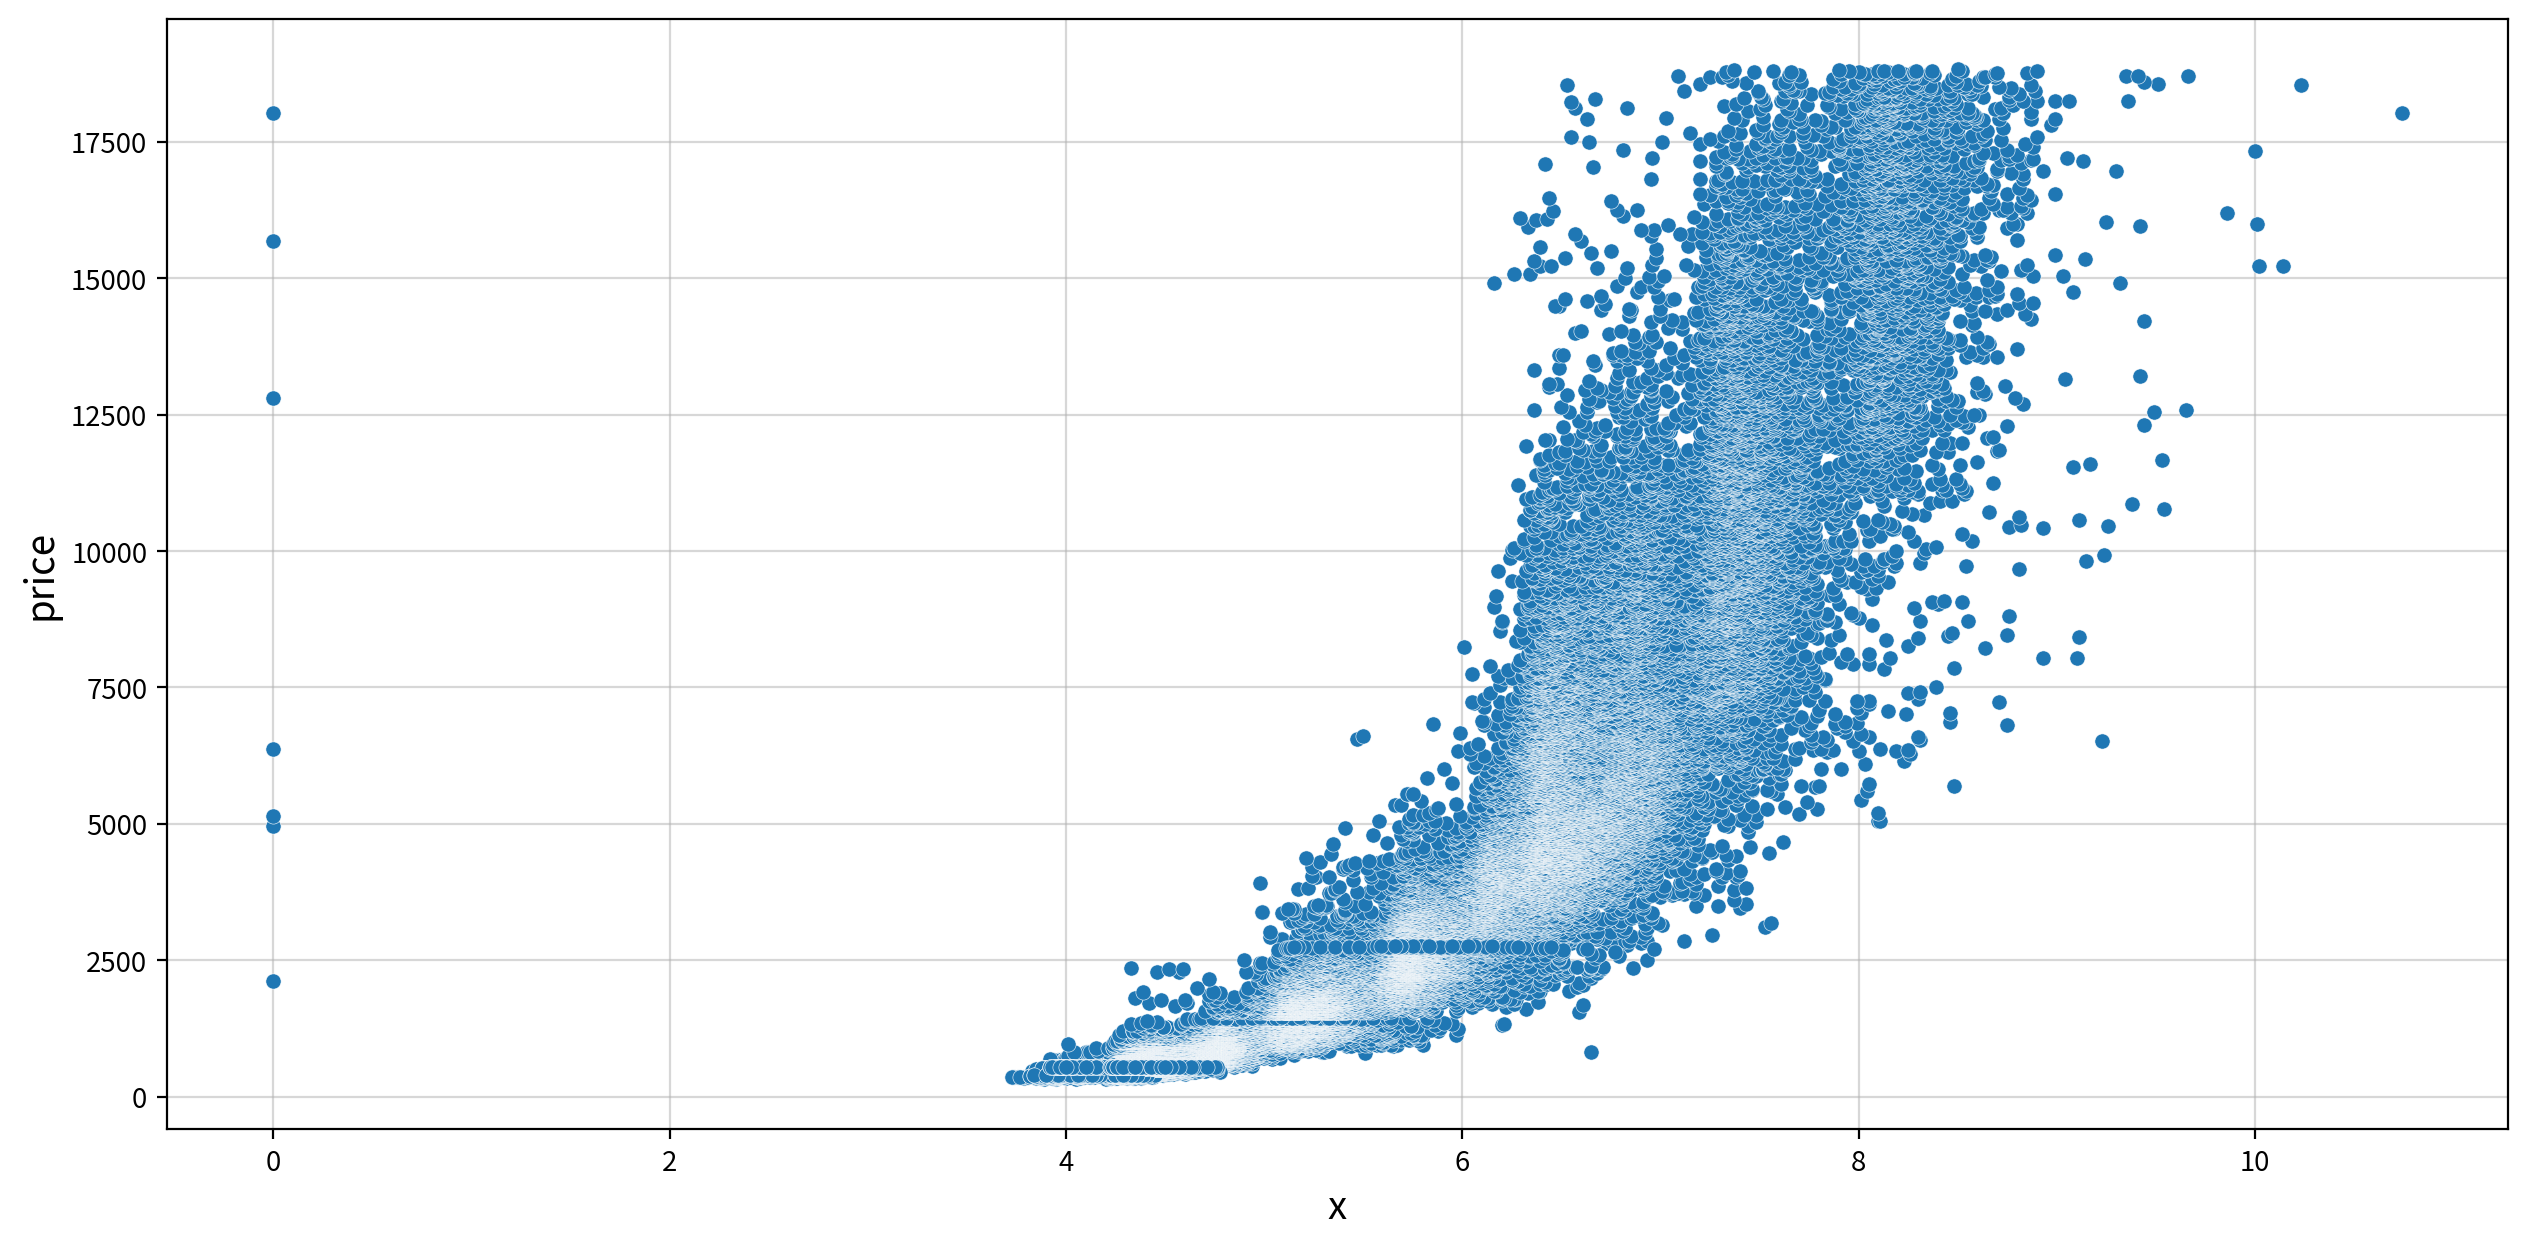

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
x,price,Spearman,0.963,0.000,Strong,True,False,False,False,False,True


#### ▶︎ y(너비(mm)) → price

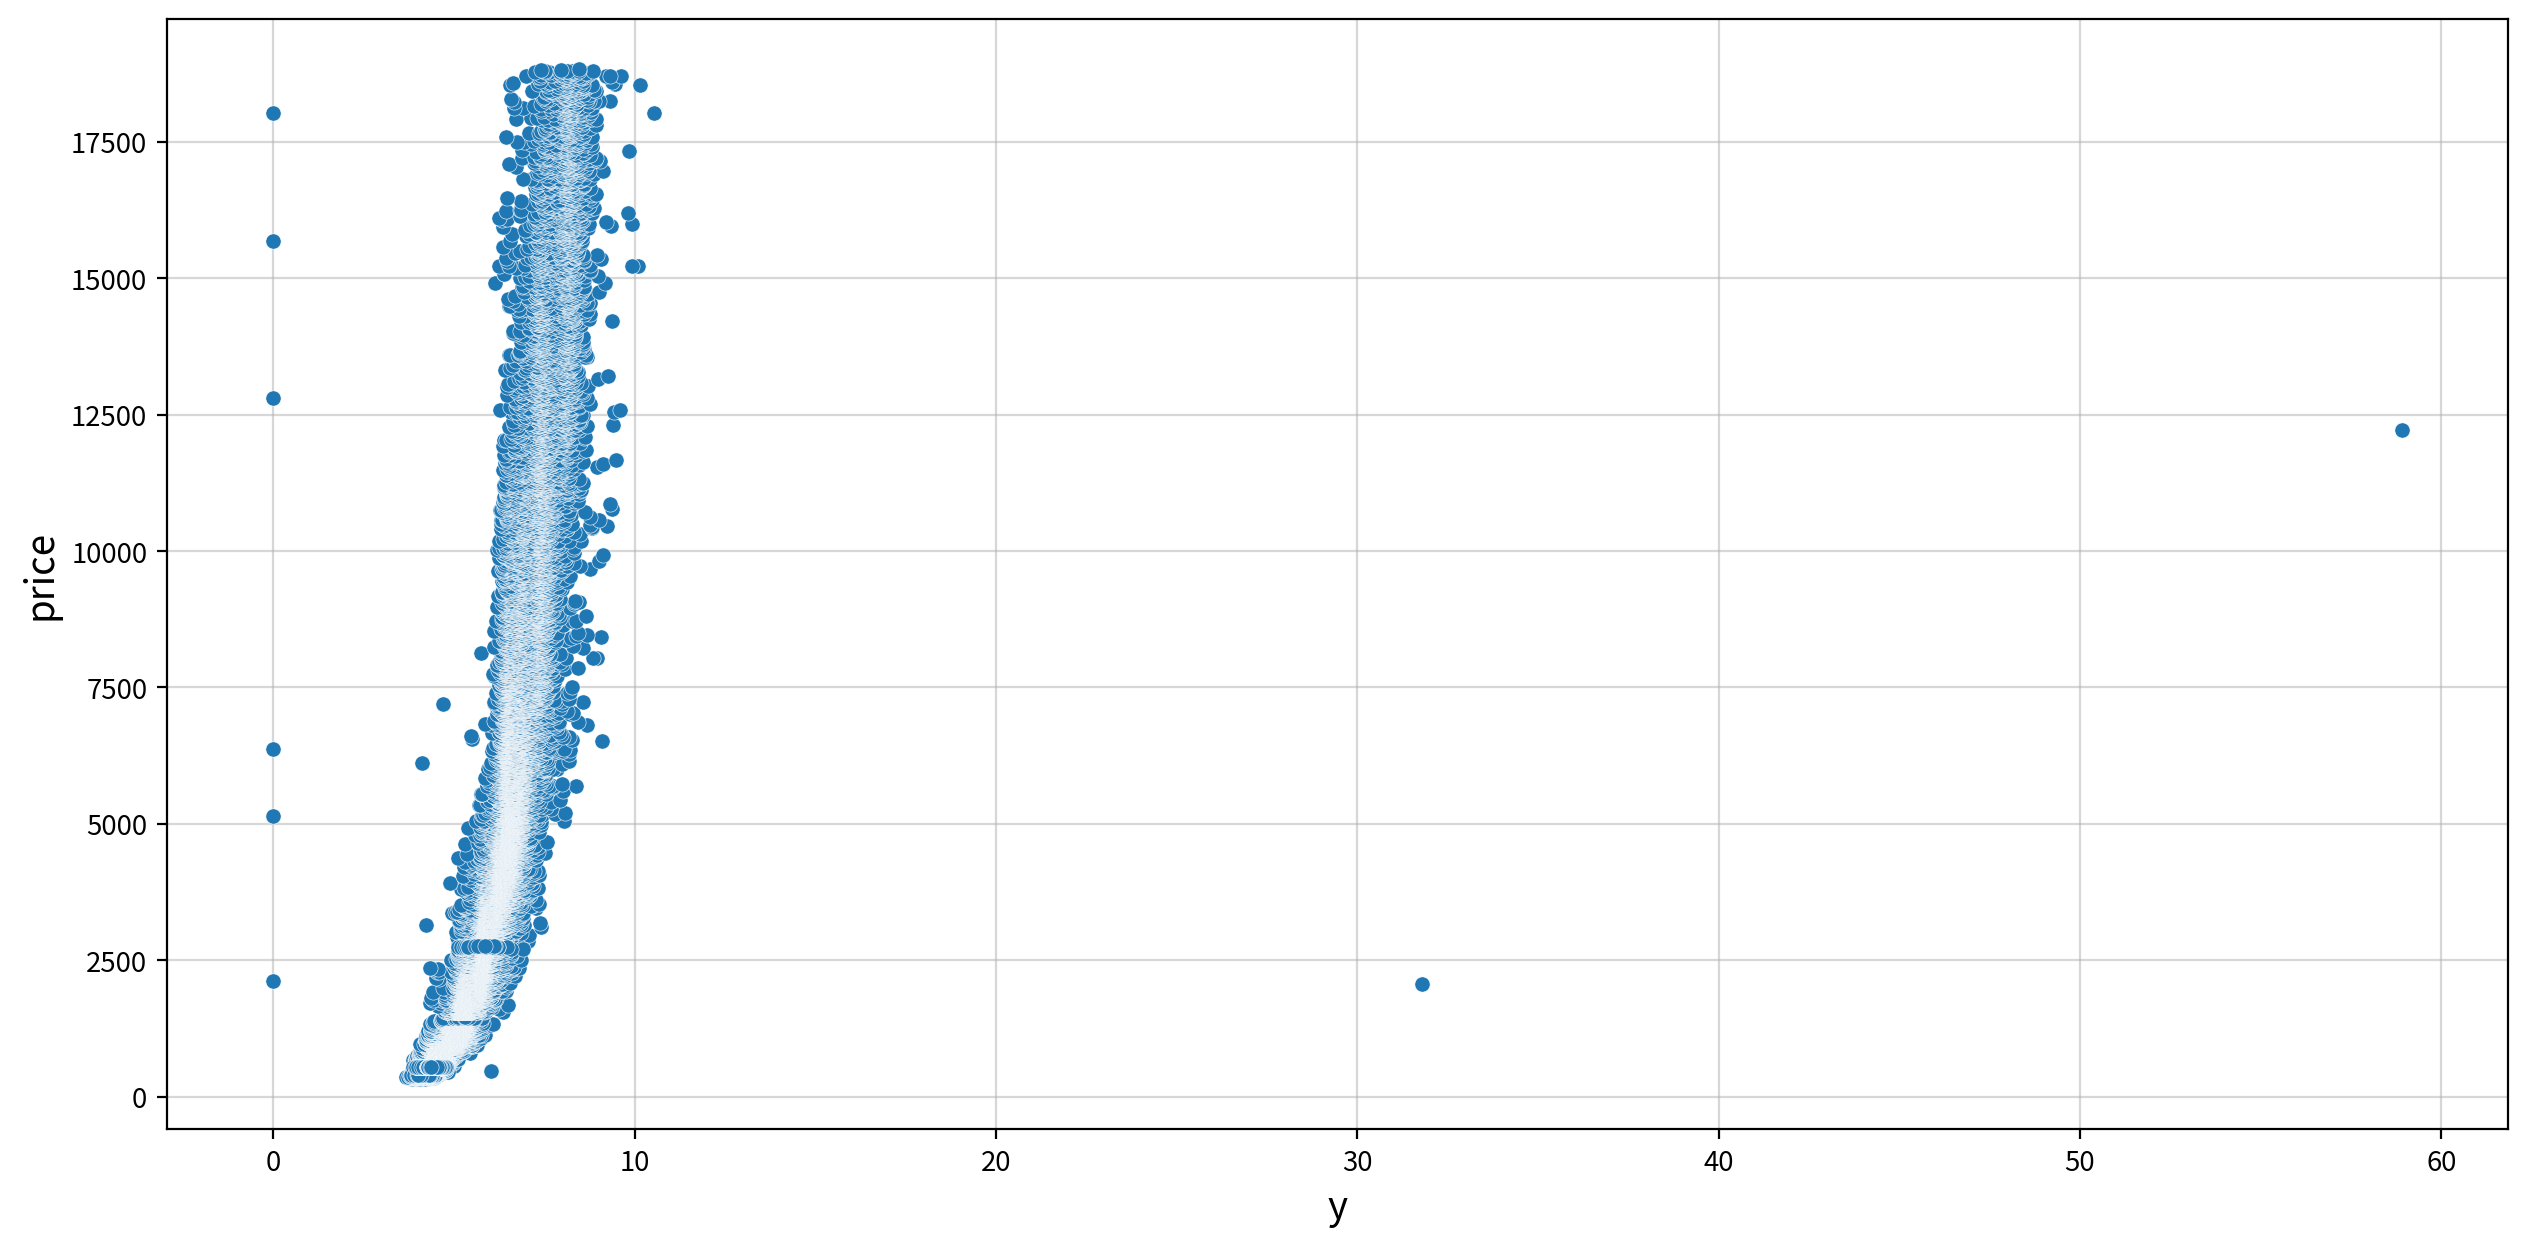

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
y,price,Spearman,0.963,0.000,Strong,True,False,False,False,False,True


#### ▶︎ z(두께(mm)) → price

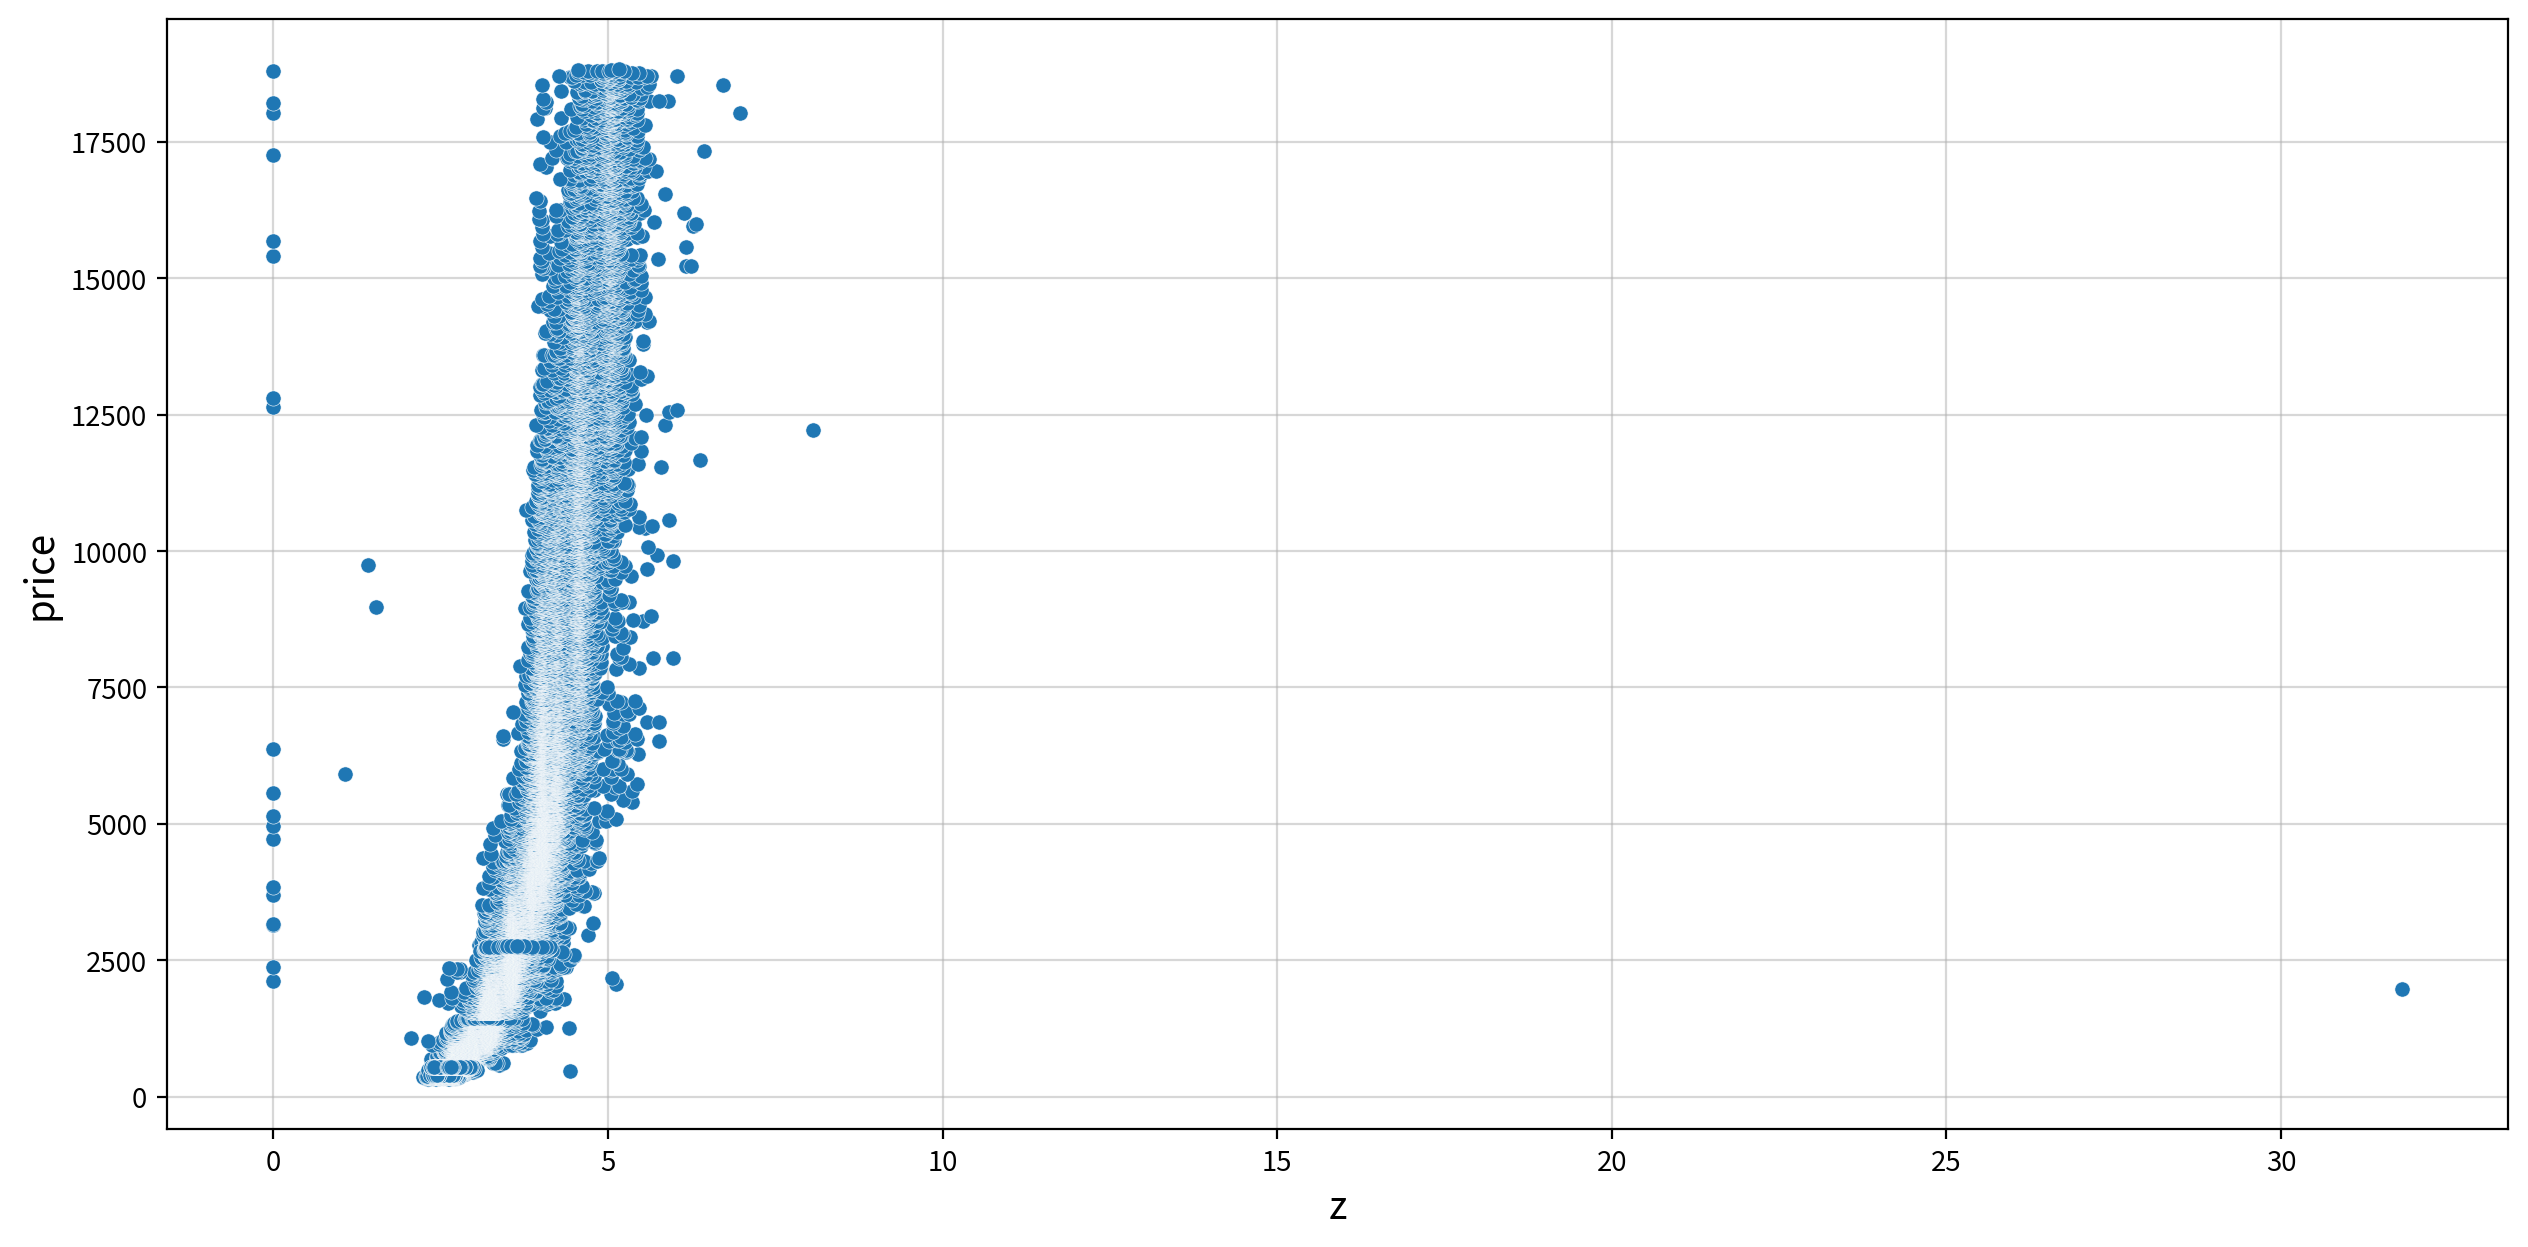

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
z,price,Spearman,0.957,0.000,Strong,True,False,False,False,False,True


#### ▶︎ depth(비율 정보) → price

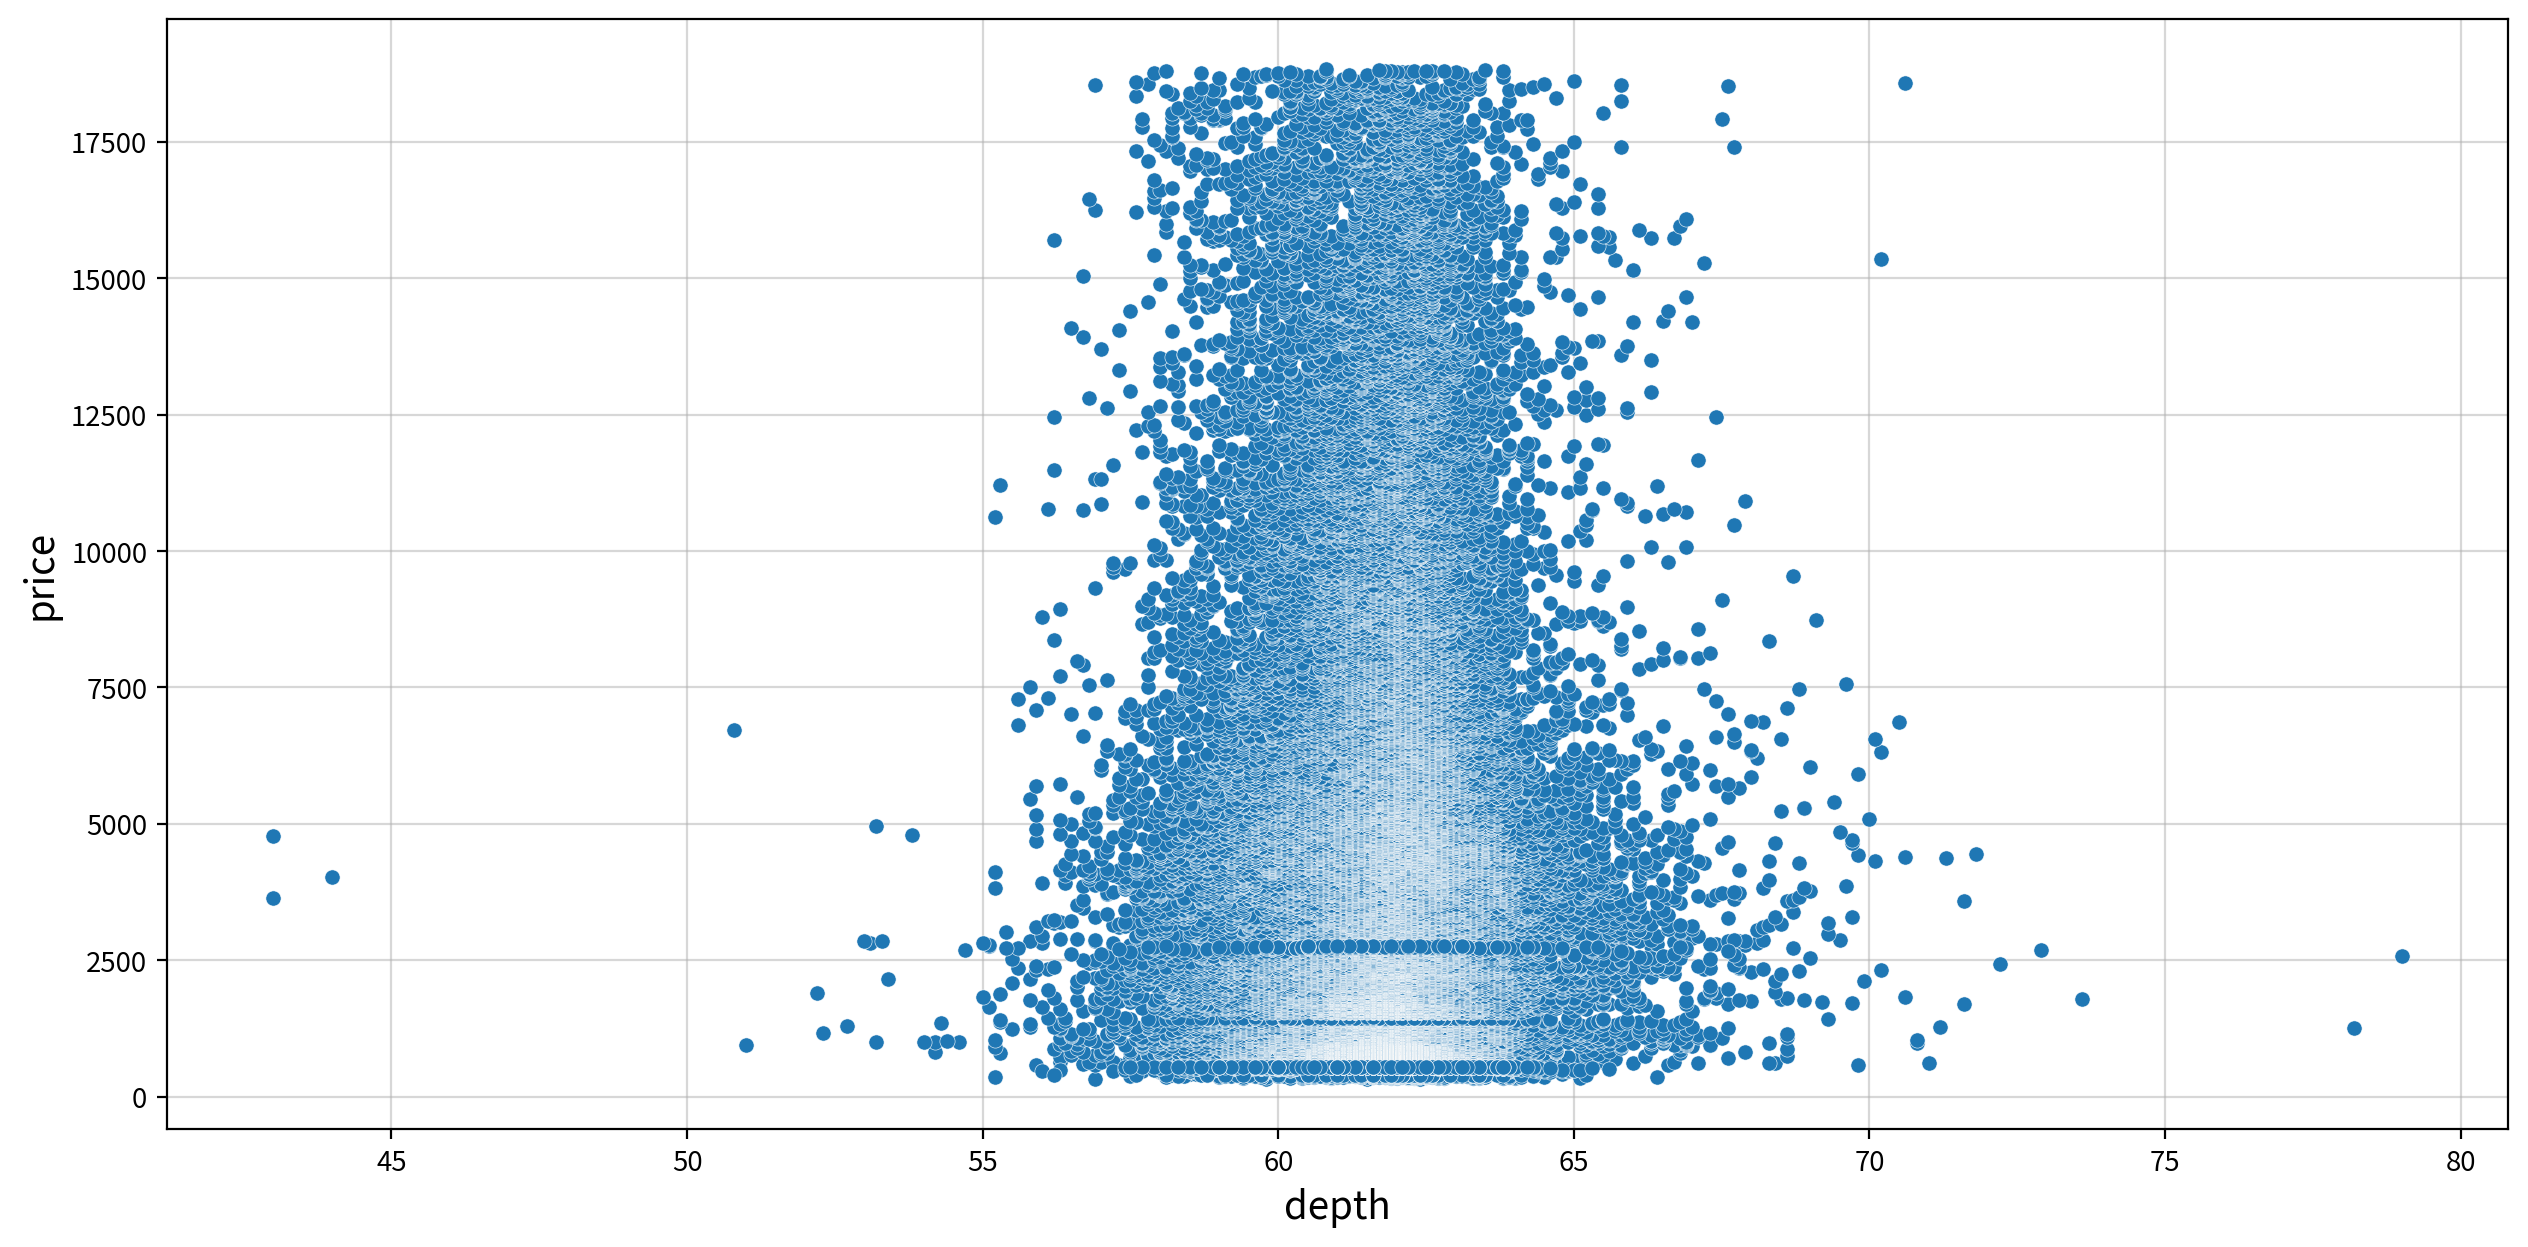

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
depth,price,Spearman,0.010,0.018,Weak,True,False,False,False,False,True


#### ▶︎ table(테이블 너비 비율(%)) → price

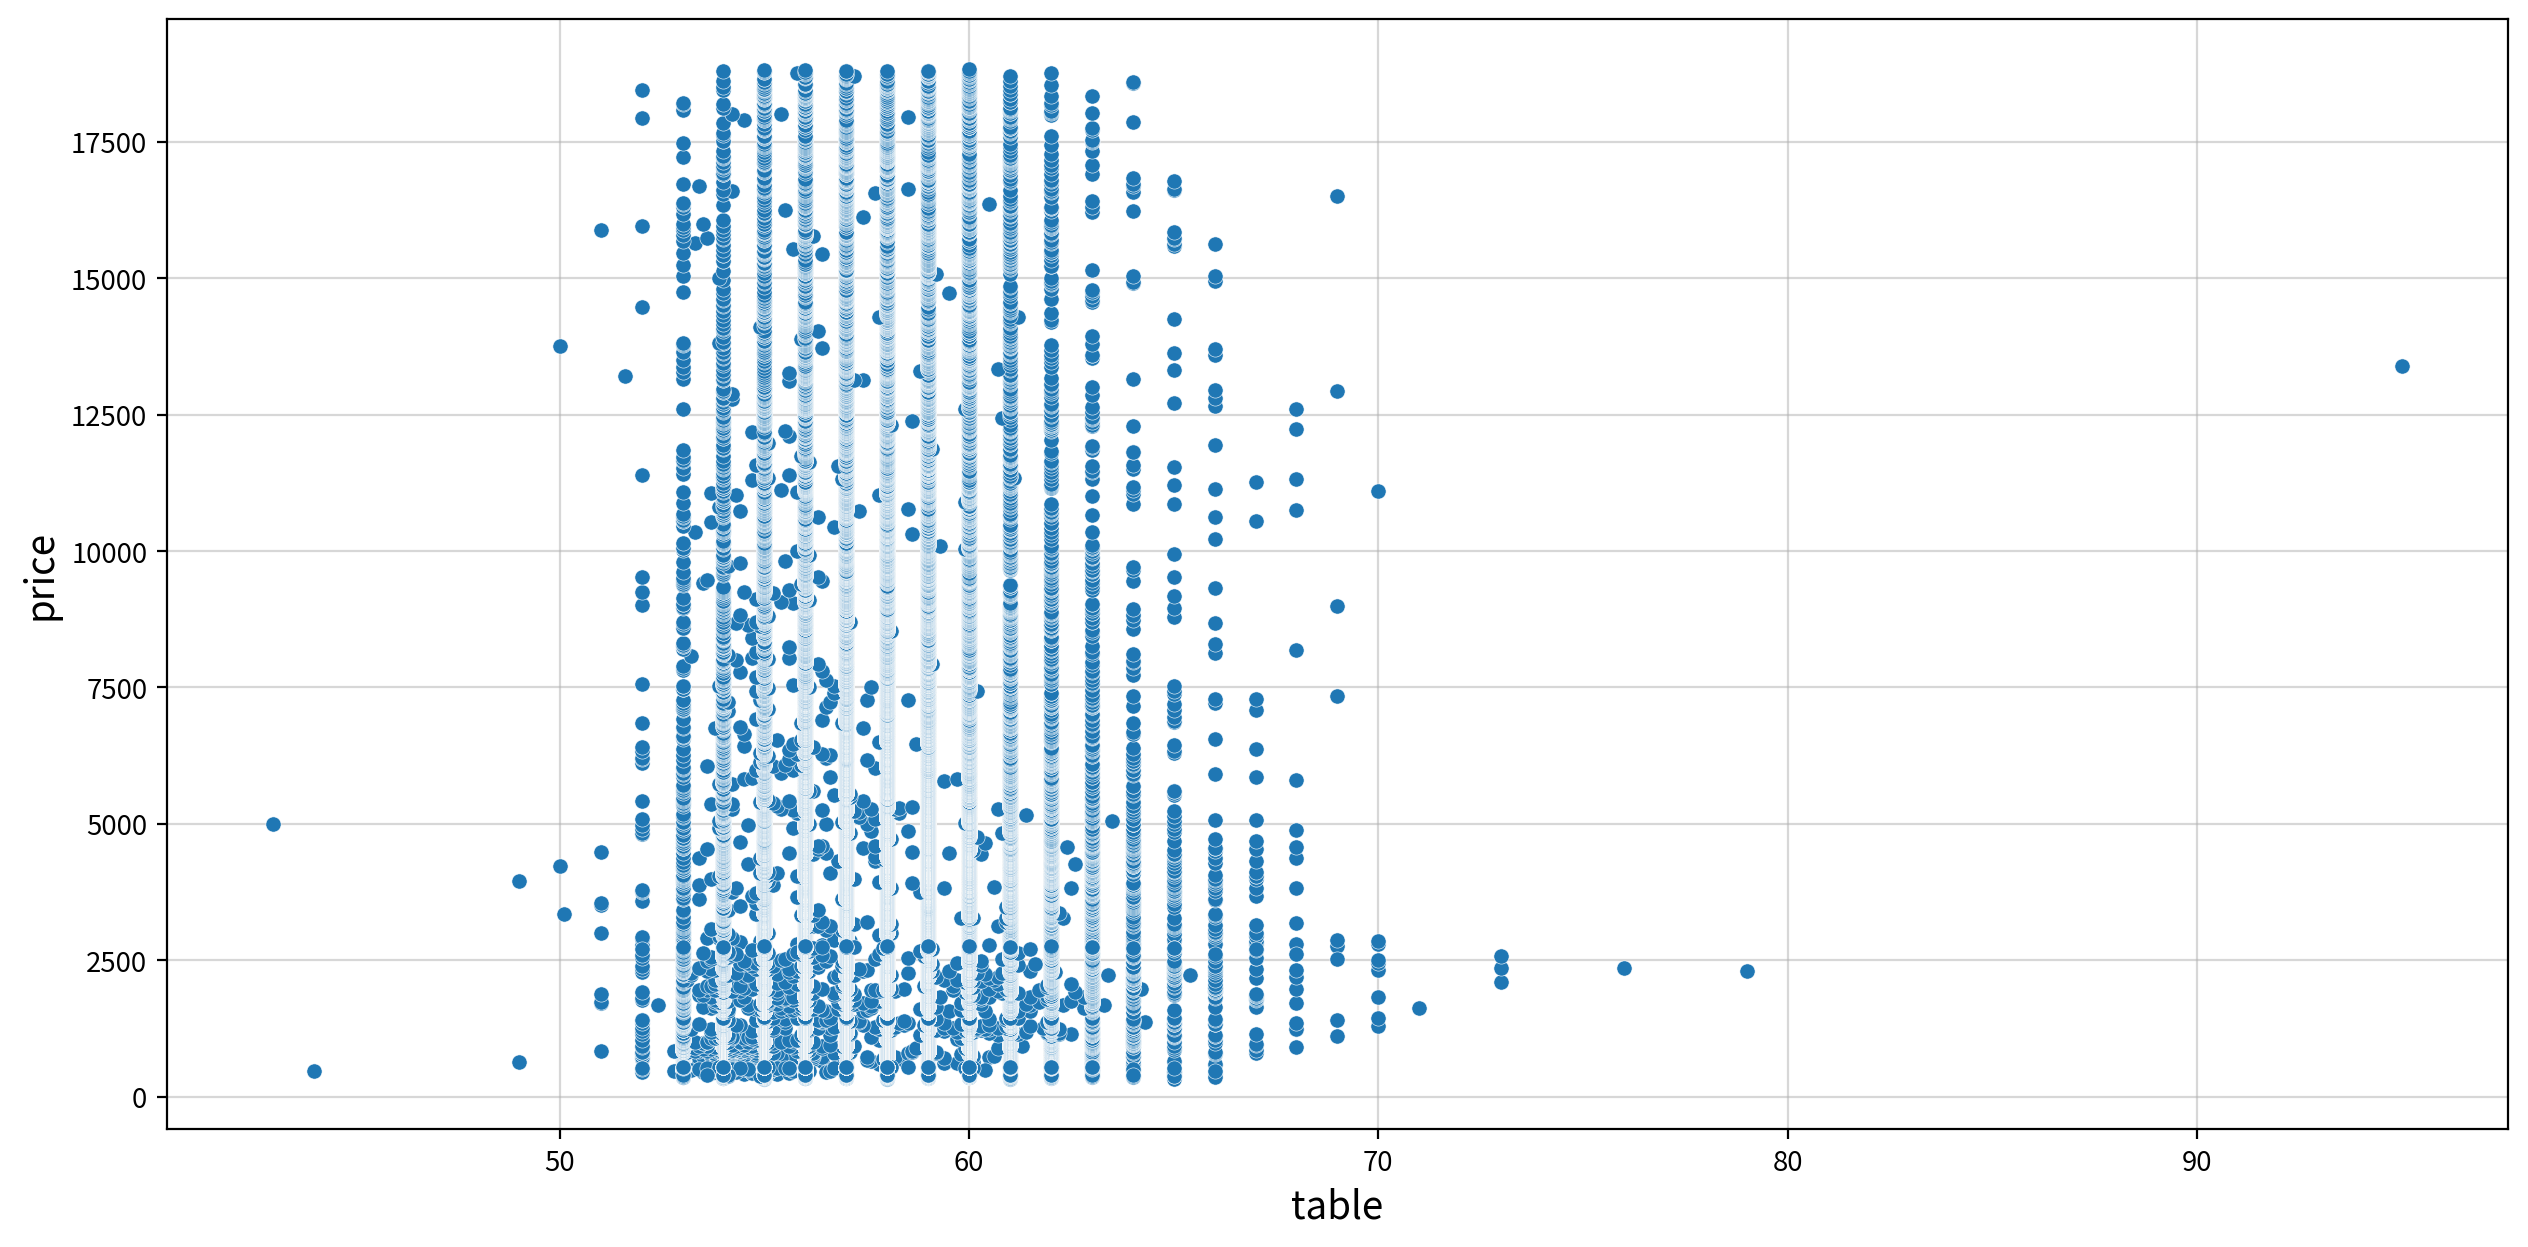

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
table,price,Spearman,0.171,0.000,Weak,True,False,False,False,False,True


In [21]:
# 연속형 독립변수 이름을 탐색하면서 반복
for f in continuous_cols:
    # 빈 줄 출력용
    print()

    # 분석 단위 제목 출력
    display(Markdown(f"#### ▶︎ {f}({column_means[f]}) → {target}"))

    # 시각화
    my_plot.scatterplot(data=df, x=f, y=target, outline=False,
                        # 데이터 밀도에 따라 외곽선 굵기와 점 크기 조절
                        linewidth=0.2, size=30)
    
    # my_stats는 시각화까지 일괄처리 한다.
    display(my_stats.correlation(df, x=f, y=target, plot=False))

##### 💡 결과 해석


| 변수 | 선형/비선형 | 단조성 | 산포 | 이상치 | 채택 여부 |
|---|---|---|---|---|---|
| `carat` | **비선형** (위로 볼록, r=0.92 < ρ=0.96) | **강한 양의 단조↑** (ρ=+0.963) | **강한 이분산** (부채꼴, 커질수록 분산↑) | 상단 고가 꼬리 | ✅ **채택 (최우선)** |
| `x` | 비선형 (곡선, r=0.89 < ρ=0.96) | 강한 양의 단조↑ (ρ=+0.963) | 강한 이분산 | 0mm 추세 이탈값 | ✅ 채택 |
| `y` | 비선형 (곡선, r=0.87 < ρ=0.96) | 강한 양의 단조↑ (ρ=+0.963) | 강한 이분산 | **58.9mm 극단 이탈** | ✅ 채택 |
| `z` | 비선형 (곡선, r=0.86 < ρ=0.96) | 강한 양의 단조↑ (ρ=+0.957) | 강한 이분산 | **31.8mm 극단 이탈** | ✅ 채택 |
| `table` | 사실상 무관 (r=0.13) | 약한 양의 단조 (ρ=+0.171) | 약한 이분산 | 소수 | 🟡 **보류** — 유의하나 설명력 미미 |
| `depth` | 무관 (r≈0) | 단조성 없음 (ρ=+0.010) | 등분산 (관계 자체가 없음) | 판단 무의미 | ❌ **제외** — n=53,794로 유의만 떴을 뿐 효과 없음 |

- **`carat`·`x`·`y`·`z`**: 강한 양의 단조 증가지만 **비선형(위로 휘는 곡선) + 이분산(부채꼴)** → `price`·`carat` **로그 변환** 시 선형화·등분산화 기대.
- 4종 모두 ρ≈0.96으로 **동률** → 서로 같은 정보일 가능성이 크다(다변량 단계에서 공선성 확인).


#### 2. T-Test (x: 2집단 명목형 독립변수 → y: 종속변수)

- 2개의 고유값만 존재하는 명목형 독립변수에 대해서만 검정을 수행한다.
  - 2개의 고유값만 존재하는 명목형이 없을 경우 출력 결과가 없을 수 있다.

In [22]:
for n in nominal_cols:
    # 2개의 고유값만 존재하는 명목형 독립변수에 대해서만 검정을 수행한다.
    if len(df[n].unique()) == 2:
        # 빈 줄 출력용
        print()

        # 분석 단위 제목 출력
        display(Markdown(f"#### ▶︎ {n}({column_means[n]}) → {target}"))

        # 수집된 데이터가 long 타입이므로 검정 대상만 wide 타입으로 변환해야 한다.
        wide_df = my_prep.long2wide(df, hue=n, values=target)
        display(my_stats.test_independent(wide_df, 
                    group1=wide_df.columns[0], group2=wide_df.columns[1]))

##### 💡 결과 해석


> 이 데이터셋에는 해당 없음

#### 3. ANOVA (x: 3집단 명목형 독립변수 → y: 종속변수)

- 3개 이상의 고유값이 존재하는 명목형 독립변수에 대해서만 검정을 수행한다.
  - 3개 이상의 고유값을 갖는 명목형이 없을 경우 출력 결과가 없을 수 있다.
- 시각화는 보고서 포함 여부에 따라 선택적으로 수행한다.
  - 여기서는 출력 결과 간소화를 위해 시각화는 생략함

In [23]:
for n in nominal_cols:
    # 3개 이상의 고유값이 존재하는 명목형 독립변수에 대해서만 검정을 수행한다.
    if len(df[n].unique()) >= 3:
        print() # 빈 줄 출력용

        # 분석 단위 제목 출력
        display(Markdown(f"#### ▶︎ {n}({column_means[n]}) → {target}"))

        # origin이 아닌 df를 사용해야 서열척도로 지정한 범주 순서가 반영된다.
        display(my_stats.anova_oneway(df, y=target, between=n))
        
        # 사후검정
        display(my_stats.posthoc_oneway(df, y=target, between=n, plot=False))

#### ▶︎ cut(컷팅 등급) → price

C:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Diamonds 가격 예측 및 결정요인 분석\helpers\my_prep.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  index=df.groupby(hue).cumcount(),
C:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Diamonds 가격 예측 및 결정요인 분석\helpers\my_prep.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = pivot_table(data=df,


,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,cut,4,9347.505,163.115,0.000,0.013,Small


C:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Diamonds 가격 예측 및 결정요인 분석\helpers\my_prep.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  index=df.groupby(hue).cumcount(),
C:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Diamonds 가격 예측 및 결정요인 분석\helpers\my_prep.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = pivot_table(data=df,


비교한 조합 쌍: 10개
유의한 쌍: 8개
평균 차이가 가장 큰 쌍: (Premium) vs (Ideal) -> 차이 1120.752, 효과크기 Small, p-value 0.000
평균 차이가 가장 작은 쌍: (Premium) vs (Ideal)-> 차이 1120.752, 효과크기 Small, p-value 0.000


...

C:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Diamonds 가격 예측 및 결정요인 분석\helpers\my_prep.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  index=df.groupby(hue).cumcount(),
C:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Diamonds 가격 예측 및 결정요인 분석\helpers\my_prep.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = pivot_table(data=df,


,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,clarity,7,8541.969,221.943,0.000,0.027,Small


C:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Diamonds 가격 예측 및 결정요인 분석\helpers\my_prep.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  index=df.groupby(hue).cumcount(),
C:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Diamonds 가격 예측 및 결정요인 분석\helpers\my_prep.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = pivot_table(data=df,


비교한 조합 쌍: 28개
유의한 쌍: 22개
평균 차이가 가장 큰 쌍: (SI2) vs (VVS1) -> 차이 2530.852, 효과크기 Medium, p-value 0.000
평균 차이가 가장 작은 쌍: (SI2) vs (VVS1)-> 차이 2530.852, 효과크기 Medium, p-value 0.000


,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,I1,SI2,3925.276,5057.455,-1132.180,112.419,-10.071,1035.965,0.000,-0.272,True,Small
1,Games-Howell,I1,SI1,3925.276,3996.165,-70.889,108.475,-0.654,900.022,0.998,-0.019,False,Negligible
2,Games-Howell,I1,VS2,3925.276,3927.742,-2.466,109.522,-0.023,934.950,1.000,-0.001,False,Negligible
3,Games-Howell,I1,VS1,3925.276,3841.611,83.664,112.392,0.744,1034.654,0.996,0.021,False,Negligible
4,Games-Howell,I1,VVS2,3925.276,3286.532,638.743,116.406,5.487,1181.572,0.000,0.172,True,Negligible
5,Games-Howell,I1,VVS1,3925.276,2526.603,1398.673,117.105,11.944,1203.205,0.000,0.430,True,Small
6,Games-Howell,I1,IF,3925.276,2870.570,1054.706,138.914,7.593,1903.846,0.000,0.290,True,Small
7,Games-Howell,SI2,SI1,5057.455,3996.165,1061.290,55.556,19.103,18244.784,0.000,0.266,True,Small
8,Games-Howell,SI2,VS2,5057.455,3927.742,1129.714,57.573,19.622,19143.587,0.000,0.273,True,Small
9,Games-Howell,SI2,VS1,5057.455,3841.611,1215.844,62.862,19.342,17249.862,0.000,0.294,True,Small


##### 💡 결과 해석


| 변수 | 집단 차이 | 효과크기 | 사후검정 구분력 | 채택 여부 |
|---|---|---|---|---|
| `color` | 유의 | Small | 높음 — 대부분의 등급쌍을 구분 | ✅ 채택 |
| `clarity` | 유의 | Small | 보통 — 중간 등급 구간 일부 미구분 | ✅ 채택 |
| `cut` | 유의 | Small | 보통 — 쌍별 격차가 3종 중 가장 작음 | ✅ 채택 |

- 3종 모두 집단 간 `price` 차이가 유의 → **독립변수로 채택**
- 단, 효과크기가 모두 작고 등급 순서와 집단 평균 순서가 일치하지 않음 → **단독 설명력에 의존하지 말고 다변량 단계에서 확인**

### #04. 다변량 분석

#### 1. 독립변수간 상관 분석

In [24]:
corr = my_stats.multi_correlation(df, columns=continuous_cols, plot=False)
my_stats.correlation_summary(corr)

,carat,x,y,z,depth,table
carat,1.000,0.996,0.996,0.993,0.030,0.194
x,0.996,1.000,0.998,0.987,-0.023,0.202
y,0.996,0.998,1.000,0.987,-0.025,0.195
z,0.993,0.987,0.987,1.000,0.104,0.159
depth,0.030,-0.023,-0.025,0.104,1.000,-0.245
table,0.194,0.202,0.195,0.159,-0.245,1.000


,max-y,max-coef,count,columns
x,,,,
x,y,0.998,3,"y, carat, z"
y,x,0.998,3,"x, carat, z"
carat,x,0.996,3,"x, y, z"
z,carat,0.993,3,"carat, x, y"
depth,table,-0.245,0,-
table,depth,-0.245,0,-


##### 💡 결과 해석


- 서로 상관인 변수: `carat`, `x`, `y`, `z`
- 판정: 중량이 부피의 함수라는 도메인 근거까지 겹침 → **대표변수로 carat을 채택, 나머지는 후보로 유지**

### #05. 최종 변수 선택

| 채택여부 | 변수 | 검정방법 | 유의수준 (p) | 효과크기 | 비대칭신호 | 공선성 신호 | 근거 |
|---|---|---|---|---|---|---|---|
| ✅ 채택 | `carat` | Spearman | $< 0.05$ | ρ=+0.963 (강함) | 우편향 / log 필요 | **O** (x 0.996 / y 0.996 / z 0.993) | 단독 설명력 최상위(동률) + **크기 축 대표** → 1순위 |
| ✅ 채택 | `color` | Welch ANOVA | $< 0.05$ | np2=0.031 (Small) | 해당 없음 | **X** | 집단 차이 유의, `carat` 통제 시 순효과 기대 |
| ✅ 채택 | `clarity` | Welch ANOVA | $< 0.05$ | np2=0.027 (Small) | 해당 없음 | **X** | 집단 차이 유의. 중량 통제 후 조건부 관계 확인 |
| ✅ 채택 | `cut` | Welch ANOVA | $< 0.05$ | np2=0.013 (Small) | 해당 없음 | **X** | 집단 차이 유의 (효과크기 최소) |
| 🟡 후보 | `x` | Spearman | $< 0.05$ | ρ=+0.963 (강함) | 대칭 / 불필요 | **O** (y 0.998 / carat 0.996) | 설명력은 최상급이나 **크기 축 대표를 `carat`에 양보** → VIF 결과에 따라 대체 투입 |
| 🟡 후보 | `y` | Spearman | $< 0.05$ | ρ=+0.963 (강함) | 우편향 / log1p 필요 | **O** (x 0.998 / carat 0.996) | 설명력은 최상급이나 대표 양보. 단 **58.9mm 오류값 정제 선행 필요** |
| 🟡 후보 | `z` | Spearman | $< 0.05$ | ρ=+0.957 (강함) | 우편향 / log1p 필요 | **O** (carat 0.993 / x 0.987) | 설명력은 최상급이나 대표 양보. 단 **31.8mm 오류값 정제 선행 필요** |
| 🟡 후보 | `table` | Spearman | $< 0.05$ | ρ=+0.171 (약함) | 경미한 우편향 / 변환 선택적 | **X** (최대 -0.245) | 관계는 약하나(\|ρ\|<0.3) **중복이 없어** 정보 가치 존재 → 계수 유의성으로 최종 판정 |
| ❌ 제외 | `depth` | Spearman | 0.018 | ρ=+0.010 (약함) | 대칭 / 불필요 | **X** | **효과 사실상 0** — n=53,794 대표본 탓에 유의만 떴을 뿐, ρ≈0으로 단조 관계 자체가 없음 → **공선성과 무관하게 설명력 부재** |


<a id="regression"></a>

## 3. 선형회귀 비교와 최종 해석


### EDA 결과

| 채택여부 | 변수 | 검정방법 | 유의수준 (p) | 효과크기 | 비대칭신호 | 공선성 신호 | 근거 |
|---|---|---|---|---|---|---|---|
| ✅ 채택 | `carat` | Spearman | $< 0.05$ | ρ=+0.963 (강함) | 우편향 / log 필요 | **O** (x 0.996 / y 0.996 / z 0.993) | 단독 설명력 최상위(동률) + **크기 축 대표** → 1순위 |
| ✅ 채택 | `color` | Welch ANOVA | $< 0.05$ | np2=0.031 (Small) | 해당 없음 | **X** | 집단 차이 유의, `carat` 통제 시 순효과 기대 |
| ✅ 채택 | `clarity` | Welch ANOVA | $< 0.05$ | np2=0.027 (Small) | 해당 없음 | **X** | 집단 차이 유의. 중량 통제 후 조건부 관계 확인 |
| ✅ 채택 | `cut` | Welch ANOVA | $< 0.05$ | np2=0.013 (Small) | 해당 없음 | **X** | 집단 차이 유의 (효과크기 최소) |
| 🟡 후보 | `x` | Spearman | $< 0.05$ | ρ=+0.963 (강함) | 대칭 / 불필요 | **O** (y 0.998 / carat 0.996) | 설명력은 최상급이나 **크기 축 대표를 `carat`에 양보** → VIF 결과에 따라 대체 투입 |
| 🟡 후보 | `y` | Spearman | $< 0.05$ | ρ=+0.963 (강함) | 우편향 / log1p 필요 | **O** (x 0.998 / carat 0.996) | 설명력은 최상급이나 대표 양보. 단 **58.9mm 오류값 정제 선행 필요** |
| 🟡 후보 | `z` | Spearman | $< 0.05$ | ρ=+0.957 (강함) | 우편향 / log1p 필요 | **O** (carat 0.993 / x 0.987) | 설명력은 최상급이나 대표 양보. 단 **31.8mm 오류값 정제 선행 필요** |
| 🟡 후보 | `table` | Spearman | $< 0.05$ | ρ=+0.171 (약함) | 경미한 우편향 / 변환 선택적 | **X** (최대 -0.245) | 관계는 약하나(\|ρ\|<0.3) **중복이 없어** 정보 가치 존재 → 계수 유의성으로 최종 판정 |
| ❌ 제외 | `depth` | Spearman | 0.018 | ρ=+0.010 (약함) | 대칭 / 불필요 | **X** | **효과 사실상 0** — n=53,794 대표본 탓에 유의만 떴을 뿐, ρ≈0으로 단조 관계 자체가 없음 → **공선성과 무관하게 설명력 부재** |


### #01. 준비작업

#### 1. 라이브러리 참조

In [25]:
from jussam import load_data
from helpers import *
from IPython.display import display, Markdown

#### 2. 품질 점검 완료 데이터 셋 가져오기

- **LAB-05**에서 저장해 둔 데이터 셋과 기술통계량을 한번에 로드한다.

In [26]:
origin = load_data("diamonds_qtcheck")
num_desc = load_data("diamonds_numerical_summary")
cat_desc = load_data("diamonds_categorical_summary")

📚 다이아몬드 데이터셋의 품질 검사 완료 버전 (출처: 자체 정제)

    field    description
--  -------  -------------------------------------------------------------------
 0  price    다이아몬드 가격 (USD, $326 ~ $18,823)
 1  carat    중량 (0.2~5.01)
 2  cut      컷 품질 (Fair, Good, Very Good, Premium, Ideal)
 3  color    색상 등급 - J (worst) to D (best)
 4  clarity  투명도 등급 (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))
 5  x        길이 mm (0~10.74)
 6  y        너비 mm (0--58.9)
 7  z        두께 mm (0--31.8)
 8  depth    비율 정보 = z / mean(x, y) = 2 * z / (x + y) (43--79)
 9  table    다이아몬드의 가장 넓은 지점에 비해 상단(테이블)의 너비 (43--95)

📚 다이아몬드 데이터셋의 연속형 변수에 대한 기술 통계량 (출처: 자체 작업)
📚 다이아몬드 데이터셋의 범주형 변수에 대한 기술 통계량 (출처: 자체 작업)


#### 3. EDA 결과 반영

In [27]:
# 제외 대상 컬럼 제거
df_eda = origin.drop(columns=["depth"])

# 기술 통계량에서 제외 대상 컬럼 제거
num_desc_eda = num_desc.drop(index="depth")

# 범주형은 변경사항이 없으므로 그대로 복사
cat_desc_eda = cat_desc.copy()

#### 4. 타입 변환 (명목형 확정)

- 명목형 기술통계량 표의 컬럼명이 명목형 변수 목록이다.

In [28]:
df = my_qtcheck.set_type(df_eda, as_category=cat_desc_eda.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53794 entries, 0 to 53793
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   price    53794 non-null  int64   
 1   carat    53794 non-null  float64 
 2   cut      53794 non-null  category
 3   color    53794 non-null  category
 4   clarity  53794 non-null  category
 5   x        53794 non-null  float64 
 6   y        53794 non-null  float64 
 7   z        53794 non-null  float64 
 8   table    53794 non-null  float64 
dtypes: category(3), float64(5), int64(1)
memory usage: 2.6 MB


#### 5. 변수 유형 분류

In [29]:
# 종속변수
target = "price"
# 종속변수 연속형 여부
target_is_continuous = True

# 명목형 변수
nominal_cols = my_qtcheck.get_categorical_column_names(df)
# 연속형 변수
continuous_cols = my_qtcheck.get_number_column_names(df)

if target_is_continuous:
    # 연속형 변수 이름에서 종속변수 항목 제거
    continuous_cols.remove(target)
else:
    # 명목형 변수 이름에서 종속변수 항목 제거
    nominal_cols.remove(target)

print("종속변수 :", target)
print("종속변수 유형: " + ("연속형" if target_is_continuous else "명목형"))
print("명목형   :", nominal_cols)
print("연속형   :", continuous_cols)

종속변수 : price
종속변수 유형: 연속형
명목형   : ['cut', 'color', 'clarity']
연속형   : ['carat', 'x', 'y', 'z', 'table']


#### 6. 컬럼 의미를 정리한 딕셔너리

In [30]:
column_means = {
    "price":    "다이아몬드 가격 (USD)", 
    "carat":    "중량",
    "cut":      "컷팅 등급",    # Fair, Good, Very Good, Premium, Ideal
    "color":    "색상 등급",    # J (worst) to D (best)
    "clarity":  "투명도 등급",  # (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))
    "x":        "길이(mm)",
    "y":        "너비(mm)",
    "z":        "두께(mm)",
    "table":    "테이블 너비 비율(%)"
}

#### 7. 서열척도 적용 (필요에 따라 수행)

In [31]:
# 서열척도를 적용할 변수와 순서를 정의한다. (낮은 등급 → 높은 등급)
# -> 도메인 지식이 필요한 부분이므로 #01(준비작업)에서만 수정한다.
# -> 서열척도 대상이 없는 데이터셋이라면 제외하면 된다
ordinal_map = {
    "cut":     ["Fair", "Good", "Very Good", "Premium", "Ideal"],
    "color":   ["J", "I", "H", "G", "F", "E", "D"],
    "clarity": ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"],
}

# 정의된 내용에 따라 순서를 재지정한다.
# -> 데이터셋에 없는 컬럼은 건너뛰므로 다른 데이터셋에서도 오류가 나지 않는다.
for col, order in ordinal_map.items():
    if col in df.columns:
        df[col] = df[col].cat.reorder_categories(order, ordered=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53794 entries, 0 to 53793
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   price    53794 non-null  int64   
 1   carat    53794 non-null  float64 
 2   cut      53794 non-null  category
 3   color    53794 non-null  category
 4   clarity  53794 non-null  category
 5   x        53794 non-null  float64 
 6   y        53794 non-null  float64 
 7   z        53794 non-null  float64 
 8   table    53794 non-null  float64 
dtypes: category(3), float64(5), int64(1)
memory usage: 2.6 MB


### #02. 선형회귀 파이프라인

#### 1. 전처리 체크포인트 정의

- 전처리 단계를 하나씩 누적한 체크포인트 (아래로 갈수록 전처리가 하나 더 붙는다)
- labeling, encode 는 기본값이 True 이므로 따로 적지 않는다

In [32]:
checkpoints = {
    "0_기준선":    dict(),
    "1_로그변환":   dict(log=True),
    "2_이상치대체": dict(log=True, outlier=True),
    "3_공선성제거": dict(log=True, outlier=True, vif=True),
    "4_스케일링":   dict(log=True, outlier=True, vif=True, scale=True),
}

#### 2. 더미변수의 기준 확인

- `labeling` 은 명목형의 값을 **알파벳 순서**로 0부터 매긴다.
- 이어지는 `encode`(더미 인코딩)가 이 정수를 컬럼명에 사용하므로, 회귀계수를 해석하려면 매핑을 알아야 한다.
  - 예) `cut_2` 는 `cut = Ideal` 을 의미한다.
- `drop_first=True` 로 **0번 범주가 기준** 이 되어 빠진다. 더미 계수는 모두 이 기준 범주 대비 차이다.

In [33]:
# 라벨 매핑만 확인하는 용도 (반환값은 사용하지 않는다)
_ = my_prep.labeling(df, columns=nominal_cols)

cut (5종): Fair=0,Good=1,Ideal=2,Premium=3,Very Good=4
color (7종): D=0,E=1,F=2,G=3,H=4,I=5,J=6
clarity (8종): I1=0,IF=1,SI1=2,SI2=3,VS1=4,VS2=5,VVS1=6,VVS2=7


#### 3. 체크포인트별 모델 적합

- `fit_pipeline` 은 전처리부터 모델 적합까지 한 번에 수행하고, 계수 해석에 필요한 변환 정보를 결과 객체에 붙여 돌려준다.
- `backward=True`(기본값)이므로 유의하지 않은 독립변수는 후진소거법으로 하나씩 제거된다.

In [34]:
fits = {}

for name in checkpoints:
    print(f"\n▶︎ --- {name} ---")

    # 전처리 + 모델 적합을 한 번에 수행한다.
    # -> name 을 지정해 두면 compare_models 의 결과표에 그대로 사용된다.
    fits[name] = my_ols.fit_pipeline(df, target, nominal_cols=nominal_cols, name=name, verbose=False, **checkpoints[name])


▶︎ --- 0_기준선 ---

유의하지 않은 독립변수 제거 → y (p = 0.7865)
유의하지 않은 독립변수 제거 → z (p = 0.4474)

▶︎ --- 1_로그변환 ---

유의하지 않은 독립변수 제거 → table (p = 0.7514)

▶︎ --- 2_이상치대체 ---

유의하지 않은 독립변수 제거 → table (p = 0.5136)

▶︎ --- 3_공선성제거 ---

완료! 남은 변수: ['table', 'z']
최대 VIF = 1.03


▶︎ --- 4_스케일링 ---

완료! 남은 변수: ['table', 'z']
최대 VIF = 1.03



#### 4. 성능 비교와 최종 모델 선택

- 종속변수에 로그가 적용된 모델은 예측값을 **원본 척도(달러)로 되돌려** RMSE·MAE·R²(원본척도)를 계산한다.
  - 척도가 다른 지표(`R2(모델척도)`·`AIC`·`BIC`)는 체크포인트 간 비교에 쓸 수 없다.
- 1위와의 격차가 5% 이내면 **근소 격차 그룹**으로 묶어 변수가 더 적은(간명한) 모델을 우선한다.

> 이 비교표의 RMSE·MAE·R²는 동일 표본의 적합값으로 계산한다. 별도 테스트셋 성능이 아니다.


In [35]:
# 성능표를 출력하고 가장 좋은 모델을 반환받는다
final_fit = my_ols.compare_models(fits)

print("최종 모델 :", final_fit.name_)
print("독립변수  :", int(final_fit.df_model), "개")

,변수수,R2(모델척도),Adj.R2,AIC,BIC,R2(원본척도),RMSE,MAE,Gap(%)
모델,,,,,,,,,
2_이상치대체,21,0.983,0.983,-64286.219,-64090.575,0.957,831.952,406.251,0.000
1_로그변환,21,0.983,0.983,-64194.658,-63999.014,0.957,832.090,405.550,0.020
3_공선성제거,19,0.968,0.968,-30419.977,-30242.119,0.924,1096.543,475.759,31.800
4_스케일링,19,0.968,0.968,-30419.977,-30242.119,0.924,1096.543,475.759,31.800
0_기준선,20,0.919,0.919,909186.897,909373.649,0.919,1131.507,743.546,36.010


최종 모델 : 2_이상치대체
독립변수  : 21 개


##### 💡 결과 해석 — 기계적 전처리 5개 모형 비교

- 기준선 RMSE는 1,131.507달러이며, 로그 변환·이상치 대체 모형은 831.952달러다. 기준선 대비 약 26.47% 감소했다.
- 선택 모형은 `2_이상치대체`, 독립변수는 21개다. 로그 변환만 수행한 모형(832.090달러)과의 차이는 작다.
- VIF 제거 모형은 `table`·`z`를 연속형 변수로 남겼고 RMSE가 1,096.543달러로 높아졌다. 공선성 제거가 이 비교에서 예측 오차 개선으로 이어지지는 않았다.
- 스케일링 전후 모형의 적합도는 동일했다. 다음 단계에서는 크기를 대표할 변수를 도메인 관점에서 선택한다.

> 표의 Gap(%)는 가장 낮은 RMSE를 분모로 한 격차다. 기준선 대비 오차 감소율과 분모가 다르므로 동일한 값으로 읽지 않는다.


### #03. 도메인 지식 반영 모델 전처리

#### 1. 데이터 전처리

- 기계적으로 채택된 x를 사용하지 않고 일반적으로 다이아몬드의 가격 결정에 많은 영향을 준다고 알려져 있는 carat을 투입한다.
- carat과 상관관계가 높은 x, y, z는 제거한다.

In [36]:
df2 = df.drop(columns=["x", "y", "z"])
df2.head()

,price,carat,cut,color,clarity,table
0,326,0.230,Ideal,E,SI2,55.000
1,326,0.210,Premium,E,SI1,61.000
2,327,0.230,Good,E,VS1,65.000
3,334,0.290,Premium,I,VS2,58.000
4,335,0.310,Good,J,SI2,58.000


#### 2. 도메인 지식 전처리 버전에 대한 체크포인트 정의

- `df2` 는 크기 축 대표로 `carat` 만 남기고 `x`·`y`·`z` 를 **도메인 지식으로 직접 제거**한 버전
  - `4_스케일링` 에서 정규화가 예측 성능을 바꾸지 않는 것을 이미 확인했으므로 도메인 쪽에서는 생략한다.

In [37]:
# 도메인 지식을 반영한 데이터(df2)에 적용할 체크포인트
# -> 앞의 checkpoints 와 전처리 조합을 동일하게 맞춘다
domain_checkpoints = {
    "5_도메인_기준선":    dict(),
    "6_도메인_로그변환":   dict(log=True),
    "7_도메인_이상치대체": dict(log=True, outlier=True),
    "8_도메인_공선성제거": dict(log=True, outlier=True, vif=True),
}

#### 3. 모델 적합 (`fits` 에 누적)

- 앞에서 만든 `fits` 딕셔너리에 **이어서 담아야** 두 방식을 한 표에서 비교할 수 있다.

In [38]:
for name in domain_checkpoints:
    print(f"\n▶︎ --- {name} ---")

    # 데이터만 df2 로 바꾸고 나머지는 동일하게 적합한다.
    # -> fits 에 누적하므로 앞의 5개 모델과 함께 비교된다.
    fits[name] = my_ols.fit_pipeline(df2, target, nominal_cols=nominal_cols, name=name, verbose=False, **domain_checkpoints[name])

print("\n누적된 모델 :", len(fits), "개")


▶︎ --- 5_도메인_기준선 ---


▶︎ --- 6_도메인_로그변환 ---

유의하지 않은 독립변수 제거 → table (p = 0.9194)

▶︎ --- 7_도메인_이상치대체 ---

유의하지 않은 독립변수 제거 → table (p = 0.9575)

▶︎ --- 8_도메인_공선성제거 ---

완료! 남은 변수: ['carat', 'table']
최대 VIF = 1.04

유의하지 않은 독립변수 제거 → table (p = 0.9575)

누적된 모델 : 9 개


#### 4. 전체 모델 성능 비교

In [39]:
# 9개 모델을 한 번에 비교한다
final_fit = my_ols.compare_models(fits)

print("최종 모델 :", final_fit.name_)
print("독립변수  :", int(final_fit.df_model), "개")

,변수수,R2(모델척도),Adj.R2,AIC,BIC,R2(원본척도),RMSE,MAE,Gap(%)
모델,,,,,,,,,
7_도메인_이상치대체,18,0.983,0.983,-63903.108,-63734.143,0.960,796.879,402.916,0.000
8_도메인_공선성제거,18,0.983,0.983,-63903.108,-63734.143,0.960,796.879,402.916,0.000
6_도메인_로그변환,18,0.983,0.983,-63887.676,-63718.710,0.960,798.871,403.074,0.250
2_이상치대체,21,0.983,0.983,-64286.219,-64090.575,0.957,831.952,406.251,4.400
1_로그변환,21,0.983,0.983,-64194.658,-63999.014,0.957,832.090,405.550,4.420
3_공선성제거,19,0.968,0.968,-30419.977,-30242.119,0.924,1096.543,475.759,37.600
4_스케일링,19,0.968,0.968,-30419.977,-30242.119,0.924,1096.543,475.759,37.600
0_기준선,20,0.919,0.919,909186.897,909373.649,0.919,1131.507,743.546,41.990
5_도메인_기준선,19,0.916,0.916,911471.617,911649.475,0.916,1155.814,803.132,45.040


최종 모델 : 7_도메인_이상치대체
독립변수  : 18 개


##### 💡 결과 해석 — 도메인 모형을 포함한 9개 모형 비교

**최종 모델은 `7_도메인_이상치대체`**다. 독립변수 18개, 원본 척도 RMSE 796.879달러, MAE 402.916달러, R² 약 0.960이다.

- 기계적 전처리의 최저 RMSE 831.952달러보다 약 **4.22% 낮고**, 독립변수는 21개에서 18개로 줄었다.
- 전체 기준선 1,131.507달러 대비 RMSE는 약 **29.57% 감소**했다. 모두 표본 내 적합값으로 계산한 수치다.
- `5_도메인_기준선`의 RMSE는 1,155.814달러다. `x`·`y`·`z`를 제외하는 것만으로 개선되지는 않았으며, 로그 변환을 더한 `6_도메인_로그변환`에서 798.871달러로 낮아졌다.
- 도메인 로그 모형에서 IQR 대체를 더한 개선은 약 0.25%로 작았다. 도메인 VIF 단계의 최대 VIF는 1.04였으며, 7·8번 모형의 성능과 변수 수는 같다. 출력에서 선택된 7번을 최종 모델로 보고한다.
- `table`은 최종 모형 적합 과정의 후진소거에서 제외되었다. 남은 항은 `log(carat)` 1개와 `cut`·`color`·`clarity`의 더미 17개다.
- 실제 변환은 **log(price)와 log(carat)**다. 중량 계수 B ≈ 1.884는 다른 조건을 통제했을 때 중량 1% 증가와 약 1.88%의 예측 가격 차이가 관련됨을 뜻한다. 인과효과로 해석하지 않는다.


### #04. 최종 채택 모델에 대한 결과 보고

#### 1. 결과 보고・가정 확인 일괄 처리

## 최종 모델: 7_도메인_이상치대체

### ▶ 성능 보고

### 1) 모형 적합도

**Note. n = 53794. F(18, 53775) = 169374.3, p < 0.001, R² = 0.983, Adj.R² = 0.983, Durbin-Watson = 1.253**

log(price)를 종속변수로, log(carat), cut_1, cut_2, cut_3, cut_4, color_1, color_2, color_3, color_4, color_5, color_6, clarity_1, clarity_2, clarity_3, clarity_4, clarity_5, clarity_6, clarity_7(을)를 독립변수로한 다중선형회귀분석 결과, 모형은 통계적으로 유의하였다.

> F(18, 53775) = 169374.3, p < 0.001, R² = 0.983.

즉, log(carat), cut_1, cut_2, cut_3, cut_4, color_1, color_2, color_3, color_4, color_5, color_6, clarity_1, clarity_2, clarity_3, clarity_4, clarity_5, clarity_6, clarity_7는 log(price)의 약 98.27%를 설명하는 것으로 나타났다.

### 2) 회귀계수 보고표

,종속변수,독립변수,B,표준오차,표준오차(HC3),β,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,price,carat,1.884,0.001,0.001,1.086,1669.480,1452.680,0.000,0.000,0.762,1.312
1,price,clarity_5,0.741,0.005,0.009,0.306,143.216,86.484,0.000,0.000,0.071,14.172
2,price,clarity_4,0.811,0.005,0.009,0.287,154.440,94.256,0.000,0.000,0.093,10.697
3,price,clarity_7,0.946,0.005,0.009,0.272,174.772,107.779,0.000,0.000,0.133,7.524
4,price,clarity_6,1.018,0.006,0.009,0.252,182.710,114.560,0.000,0.000,0.169,5.912
5,price,clarity_2,0.592,0.005,0.009,0.250,115.063,69.201,0.000,0.000,0.068,14.647
6,price,clarity_1,1.113,0.006,0.009,0.196,184.636,119.041,0.000,0.000,0.285,3.510
7,price,clarity_3,0.427,0.005,0.009,0.158,82.580,49.577,0.000,0.000,0.088,11.394
8,price,color_6,-0.511,0.003,0.003,-0.112,-166.369,-154.951,0.000,0.000,0.712,1.405
9,price,color_5,-0.373,0.002,0.003,-0.110,-149.555,-142.317,0.000,0.000,0.591,1.691


### 3) 영향력 순위 시각화 (표준화계수 β)

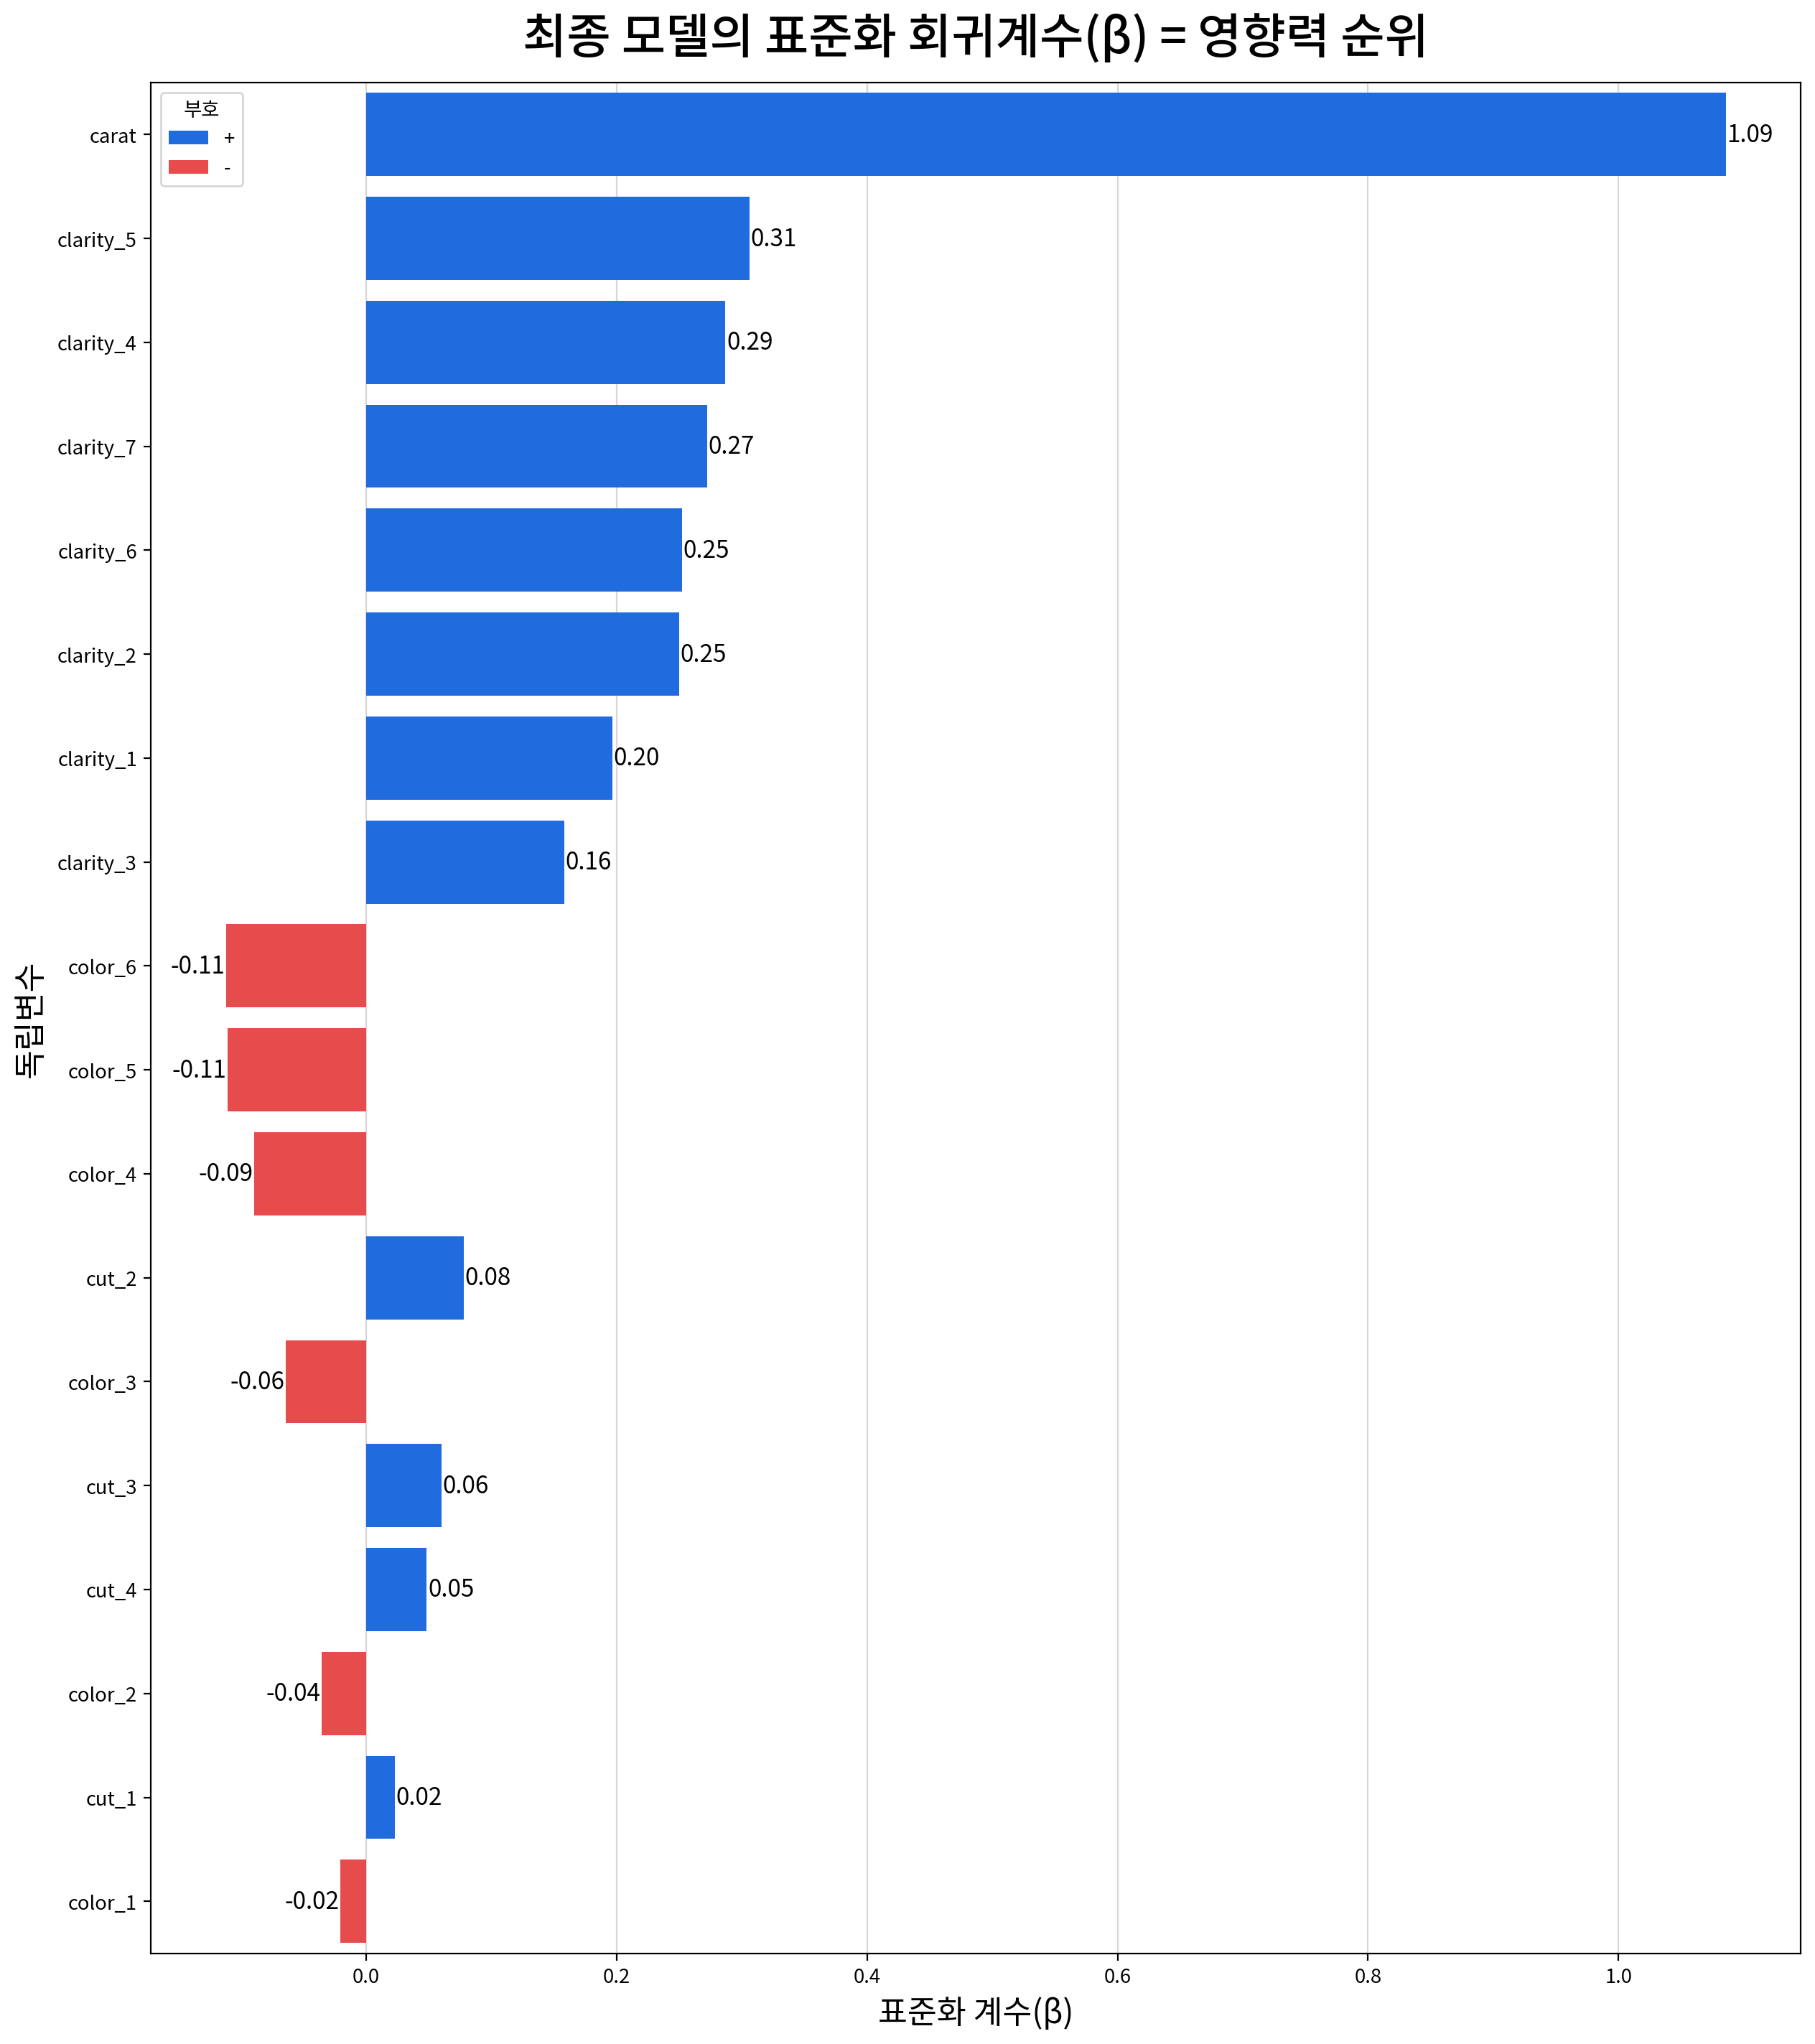

### 4) 회귀계수 해석 문장

- **carat**의 회귀계수는 **B = 1.88**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 1452.68**, **p < .001**)      
즉, carat가 **1% 증가**할 때 price는 평균적으로 약 **1.88% 증가**하는 것으로 해석된다.
- **cut_1**의 회귀계수는 **B = 0.08**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 17.15**, **p < .001**)      
즉, cut_1가 **1 증가**할 때 price는 평균적으로 약 **8.42% 증가**하는 것으로 해석된다.
- **cut_2**의 회귀계수는 **B = 0.16**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 36.2**, **p < .001**)      
즉, cut_2가 **1 증가**할 때 price는 평균적으로 약 **17.54% 증가**하는 것으로 해석된다.
- **cut_3**의 회귀계수는 **B = 0.14**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 31.09**, **p < .001**)      
즉, cut_3가 **1 증가**할 때 price는 평균적으로 약 **15.00% 증가**하는 것으로 해석된다.
- **cut_4**의 회귀계수는 **B = 0.12**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 26.18**, **p < .001**)      
즉, cut_4가 **1 증가**할 때 price는 평균적으로 약 **12.48% 증가**하는 것으로 해석된다.
- **color_1**의 회귀계수는 **B = -0.05**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = -24.01**, **p < .001**)      
즉, color_1가 **1 증가**할 때 price는 평균적으로 약 **5.26% 감소**하는 것으로 해석된다.
- **color_2**의 회귀계수는 **B = -0.09**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = -41.22**, **p < .001**)      
즉, color_2가 **1 증가**할 때 price는 평균적으로 약 **9.02% 감소**하는 것으로 해석된다.
- **color_3**의 회귀계수는 **B = -0.16**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = -71.62**, **p < .001**)      
즉, color_3가 **1 증가**할 때 price는 평균적으로 약 **14.81% 감소**하는 것으로 해석된다.
- **color_4**의 회귀계수는 **B = -0.25**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = -107.31**, **p < .001**)      
즉, color_4가 **1 증가**할 때 price는 평균적으로 약 **22.19% 감소**하는 것으로 해석된다.
- **color_5**의 회귀계수는 **B = -0.37**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = -142.32**, **p < .001**)      
즉, color_5가 **1 증가**할 때 price는 평균적으로 약 **31.10% 감소**하는 것으로 해석된다.
- **color_6**의 회귀계수는 **B = -0.51**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = -154.95**, **p < .001**)      
즉, color_6가 **1 증가**할 때 price는 평균적으로 약 **40.02% 감소**하는 것으로 해석된다.
- **clarity_1**의 회귀계수는 **B = 1.11**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 119.04**, **p < .001**)      
즉, clarity_1가 **1 증가**할 때 price는 평균적으로 약 **204.24% 증가**하는 것으로 해석된다.
- **clarity_2**의 회귀계수는 **B = 0.59**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 69.2**, **p < .001**)      
즉, clarity_2가 **1 증가**할 때 price는 평균적으로 약 **80.75% 증가**하는 것으로 해석된다.
- **clarity_3**의 회귀계수는 **B = 0.43**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 49.58**, **p < .001**)      
즉, clarity_3가 **1 증가**할 때 price는 평균적으로 약 **53.31% 증가**하는 것으로 해석된다.
- **clarity_4**의 회귀계수는 **B = 0.81**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 94.26**, **p < .001**)      
즉, clarity_4가 **1 증가**할 때 price는 평균적으로 약 **125.04% 증가**하는 것으로 해석된다.
- **clarity_5**의 회귀계수는 **B = 0.74**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 86.48**, **p < .001**)      
즉, clarity_5가 **1 증가**할 때 price는 평균적으로 약 **109.78% 증가**하는 것으로 해석된다.
- **clarity_6**의 회귀계수는 **B = 1.02**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 114.56**, **p < .001**)      
즉, clarity_6가 **1 증가**할 때 price는 평균적으로 약 **176.70% 증가**하는 것으로 해석된다.
- **clarity_7**의 회귀계수는 **B = 0.95**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 107.78**, **p < .001**)      
즉, clarity_7가 **1 증가**할 때 price는 평균적으로 약 **157.58% 증가**하는 것으로 해석된다.

> ※ 위 **t**와 **유의확률**은 등분산 가정이 충족되지 않은 경우를 대비해 **HC3 로버스트 표준오차**로 계산한 값이다.     
회귀계수(B)와 효과 크기 해석은 일반 OLS와 동일하며,     
표준오차만 이분산에 강건하게 보정되어 유의성 판정이 달라질 수 있다.

---

### ▶ 회귀모형 가정 검정

### 1) 선형성 검정

,statistic,p-value,linearity,result
Ramsey RESET,923.615,0.000,False,대립가설 채택 → 선형성 위배(곡선 관계 존재)


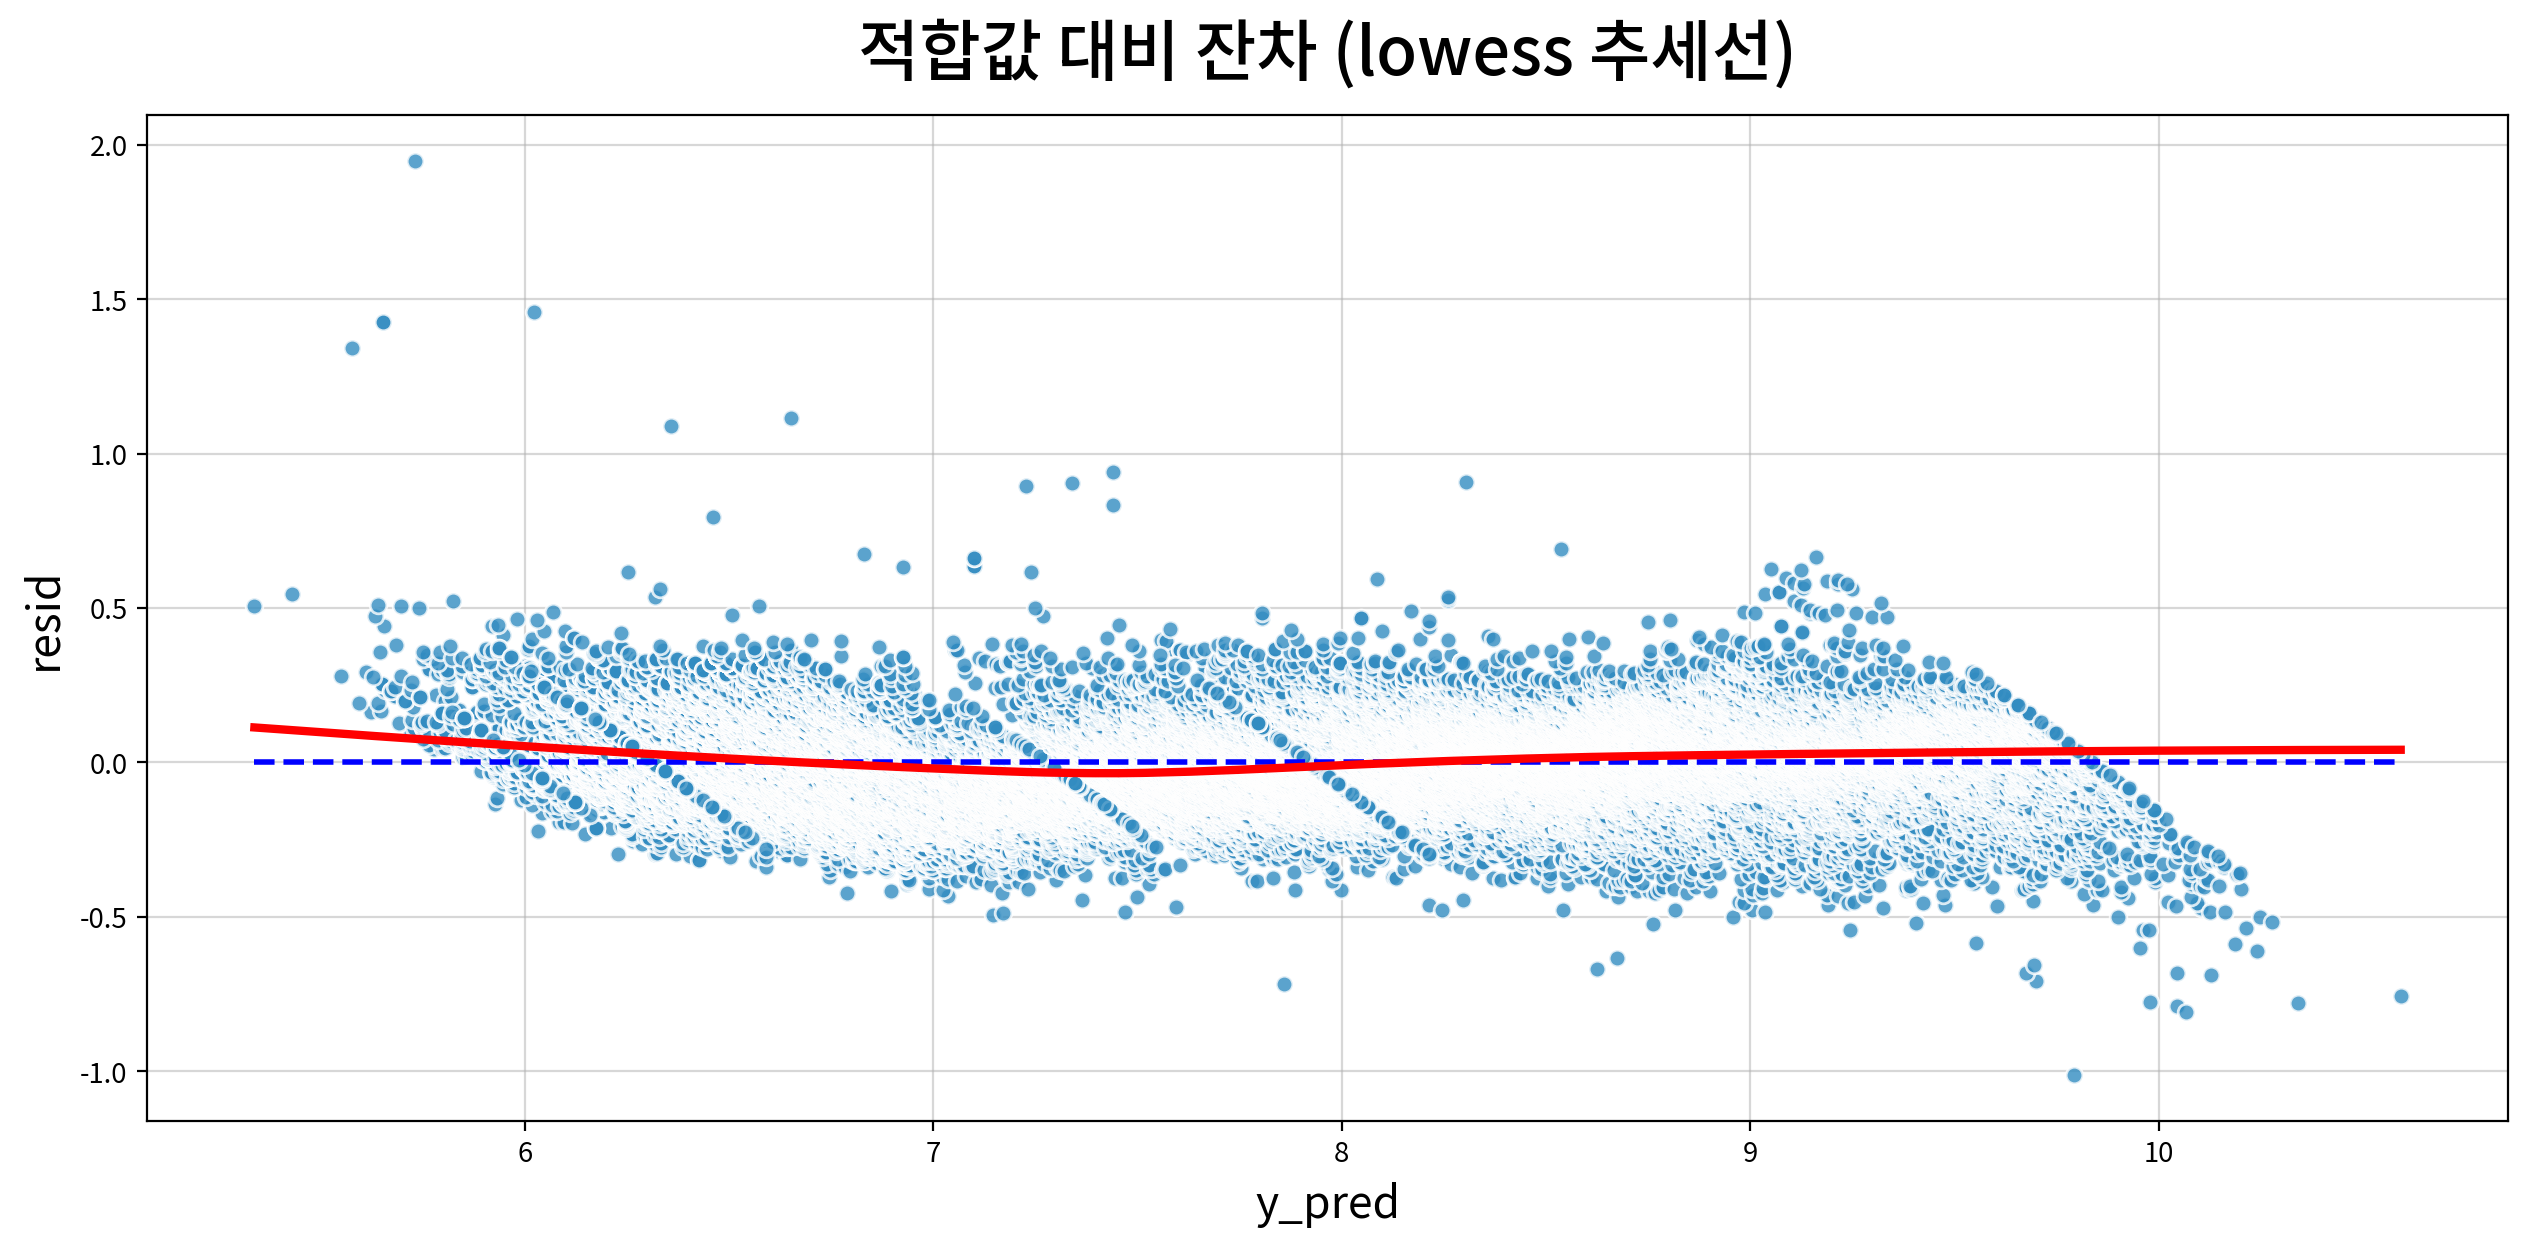

### 2) 정규성 검정

,statistic,p-value,normality,result
Kolmogorov-Smirnov,0.018,0.000,False,대립가설 채택 → 정규성 위배


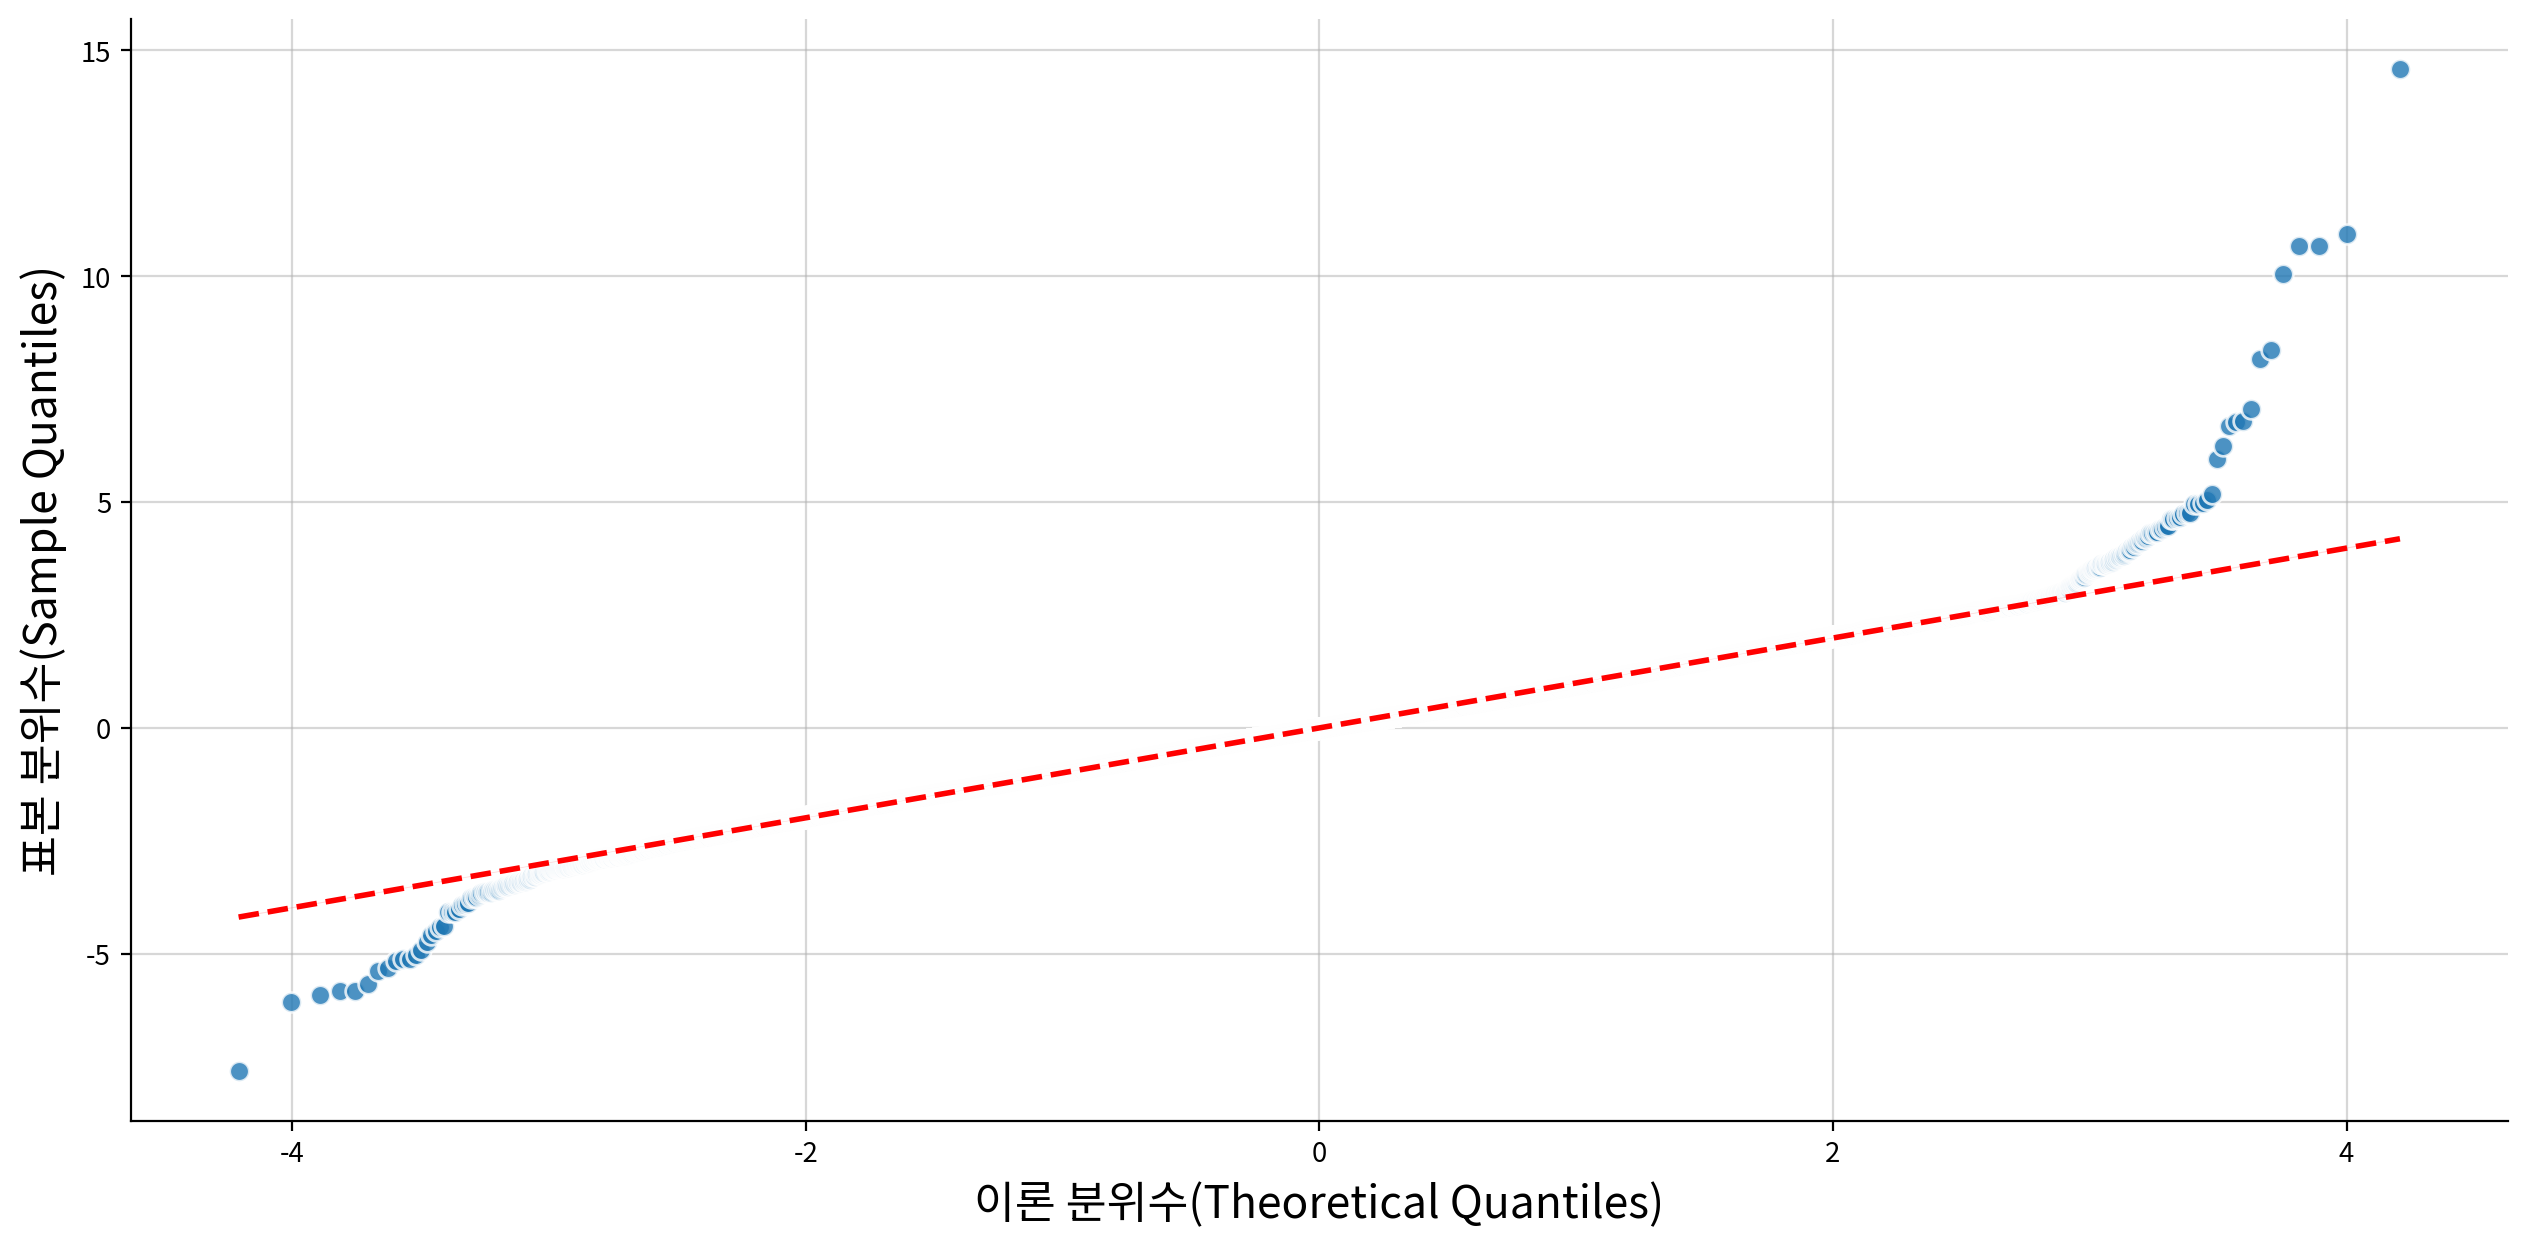

,기대(%),허용범위(%),실제(%),판정
구간,,,,
±1√MSE,68.000,68~68,69.740,위배
±2√MSE,95.000,95~95,95.420,위배
±3√MSE,99.700,100~100,99.600,위배


√MSE = 0.13 · 구간 규칙 판정: 정규성 위배


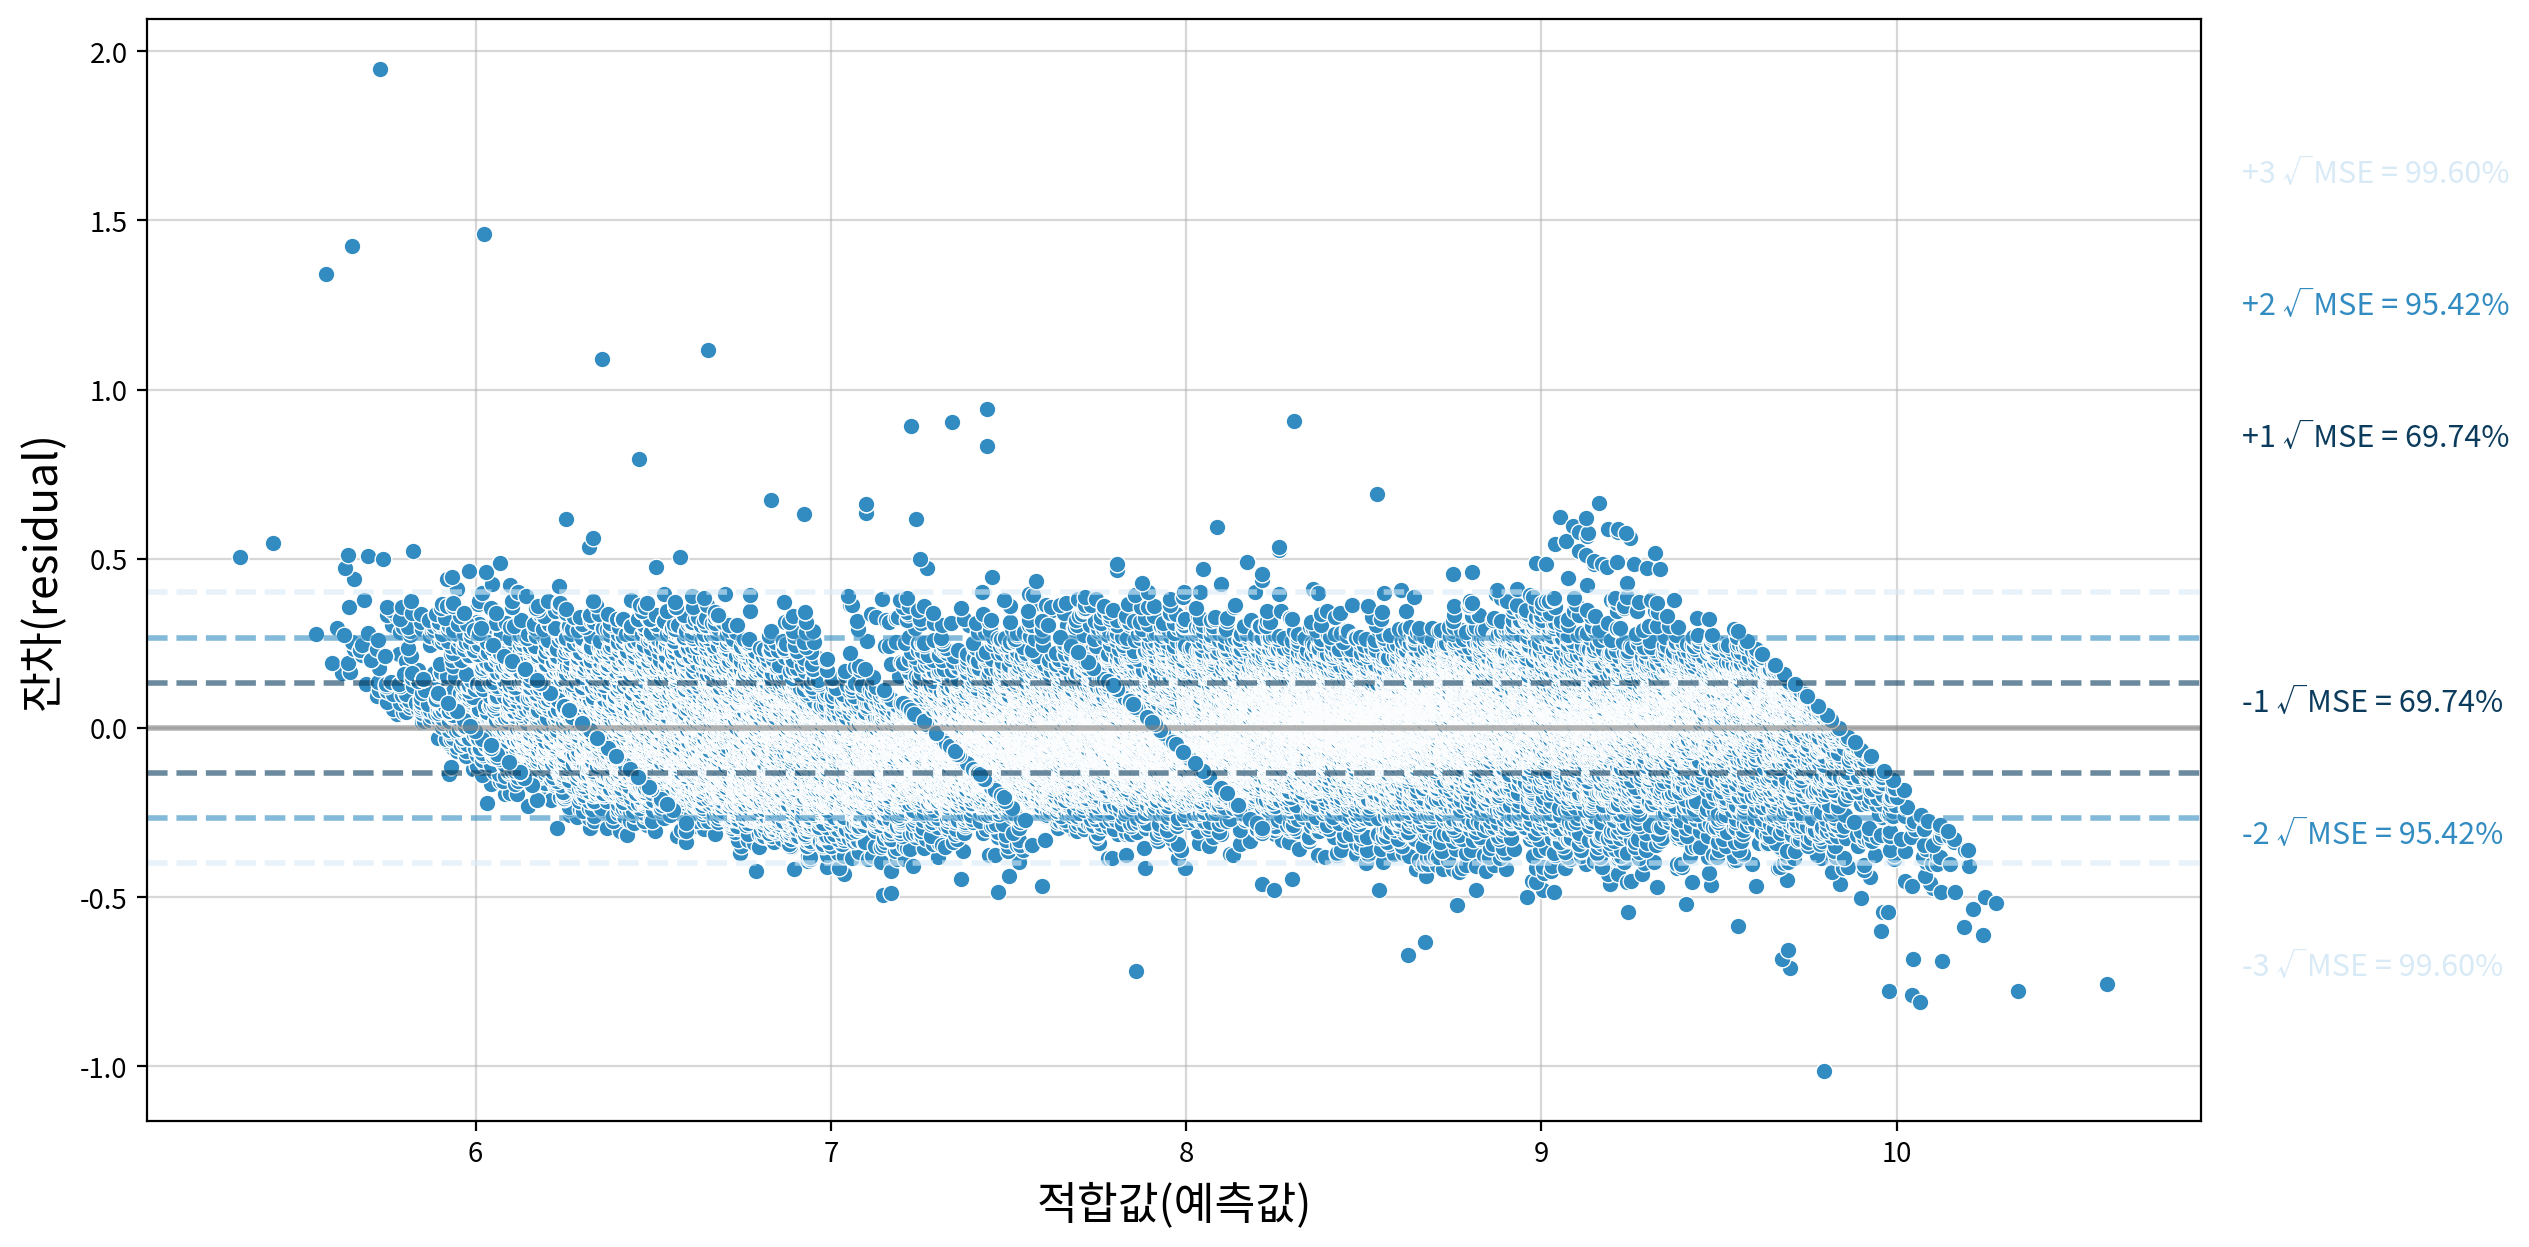

### 3) 등분산성 검정

,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,1336.676,0.000,76.125,0.000,False,대립가설 채택 → 등분산 아님


### 4) 독립성 검정

,statistic,independence,result
Durbin-Watson,1.253,False,독립성 위반 (양(+)의 자기상관)


In [40]:
my_ols.report_model(final_fit)

##### 💡 결과 해석 — 최종 모형 보고

**모형:** `log(price) ~ log(carat) + cut·color·clarity 더미`

- n = 53,794, F(18, 53,775) = 169,374.3, p < .001. 모델 척도 R² ≈ 0.983이며 원본 가격 척도 R² ≈ 0.960과 구분한다.
- 18개 회귀항은 모두 HC3 기준 p < .001이다. 표에 표시된 0.000은 반올림이며 p가 정확히 0이라는 의미가 아니다.
- `carat`의 B ≈ 1.884, 표준화 β ≈ 1.086이다. 더미 계수의 합과 비교하거나 계수 크기를 가격 결정 비율로 해석하지 않는다.
- 더미의 기준 범주는 **cut=Fair, color=D, clarity=I1**이다. 각 더미는 이 기준 대비 차이이며 코드 번호의 연속적인 증가를 뜻하지 않는다.

| 변수 | 다른 조건을 통제한 기준 범주 대비 예측 가격 차이 |
|---|---|
| cut | Ideal +17.54%, Premium +15.00%, Very Good +12.48%, Good +8.42% |
| color | E −5.26%부터 J −40.02%까지, D보다 낮음 |
| clarity | IF +204.24%, VVS1 +176.70%, VVS2 +157.58%, VS1 +125.04%, VS2 +109.78%, SI1 +80.75%, SI2 +53.31% |

위 비율은 로그 선형모형의 지수화된 조건부 예측 비교이며, 개별 상품의 가격 인상 효과나 원본 가격의 조건부 산술평균 효과를 보장하지 않는다.

**가정 검정과 해석 범위**

| 가정 | 저장된 결과 | 해석 |
|---|---|---|
| 선형성 | RESET F = 923.615, p < .001 | 잔존 비선형 관계가 검출됨 |
| 정규성 | K–S = 0.018, p < .001 | 정규성 기각. 큰 표본의 민감도와 잔차 그래프를 함께 고려 |
| 등분산성 | BP F = 76.125, p < .001 | 이분산 검출. HC3는 표준오차를 보정하며 이분산 자체를 제거하지 않음 |
| 독립성 | DW = 1.253 | 행 순서에 의존하므로 횡단면 자료의 독립성 위반을 이 값만으로 확정하지 않음 |

- 독립적인 평가셋이나 교차검증 없이 적합값으로 비교했다. 높은 R²를 일반화 성능으로 보고하지 않는다.
- 0mm·극단 치수는 확인 필요 사항으로 남는다. IQR 대체와 별도 오류값 정제를 구분한다. 최종 도메인 모형에서는 `x`·`y`·`z`가 제외되었다.
- 비선형성·이분산을 완전히 해소하지 않았다. 후속 과제로 중량 구간별 잔차 및 상호작용, 데이터 수집 구조와 독립성을 검토할 수 있으나 이번 분석에서 수행한 것으로 보고하지 않는다.


## 분석 질문에 대한 답변과 한계

중량과 품질 등급을 함께 사용한 최종 로그 선형모형은 이 표본의 가격 구조를 설명했다. 도메인 관점에서 크기 축을 `carat`으로 정리한 모형은 기계적 전처리 최고 모형보다 변수 수가 적고 표본 내 RMSE도 낮았다.

다만 표본 밖 성능을 검증하지 않았고 선형성·정규성·등분산성의 기각 결과가 남아 있다. 분석 결과는 관측 자료의 조건부 관계이며 현재 시장 전체의 시세나 개입에 따른 가격 변화로 일반화하지 않는다.

[요약과 회고로 돌아가기](README.md)
